# Numerical Range and Precision Analysis of a DNN (FP32 → FP16 / FP8 / INT16 / INT8)

**Training analysis** — ResNet-18 on CIFAR-10, FP32. Per layer, at the **beginning / middle / end** of training: inputs, layer inputs, weights, biases, activations, activation gradients, weight gradients, weight updates.

**Inference analysis** — ResNet-18/CIFAR-10, MobileNetV2/CIFAR-100, LeNet-5/MNIST, FP32, one complete pass over each test set: inputs, weights, biases, activations, output logits.

Datasets are pulled from **Kaggle**. Layers covered: convolution, linear, batch-norm, activation (ReLU/ReLU6), pooling.

---

## Run it in this order

| step | cell | what it does |
|---|---|---|
| 1 | **Step 1** | installs `kagglehub` |
| 2 | **Step 2** | ⚠️ **put your Kaggle username and key here** |
| 3 | **Step 3** | writes the analysis code to `dnn_precision_analysis.py` |
| 4 | **Step 4** | runs everything (~25–40 min on a T4 GPU) |
| 5 | **Step 5** | shows the report and the figures |
| 6 | **Step 6** | zips + downloads all results |
| 7 | **Step 7** | pushes everything to your GitHub repo |

First: `Runtime → Change runtime type → T4 GPU`.


## Step 1 — install dependencies

In [1]:
!pip -q install kagglehub

import torch
print("torch:", torch.__version__)
print("GPU  :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE (will be slow - switch to a T4 runtime)")

torch: 2.11.0+cu128
GPU  : Tesla T4


## Step 2 — Kaggle credentials  ⚠️ EDIT THIS CELL

Get them from **kaggle.com → your avatar → Settings → API → Create New Token**.
A file `kaggle.json` downloads; open it in any text editor, it looks like:

```json
{"username":"gurudeep306","key":"a1b2c3d4e5f6...."}
```

Copy those two values into the two lines below. Nothing else in the notebook needs editing.

In [2]:
# ==============================================================================
#  >>>>>>>>>>>>>>>>  PUT YOUR KAGGLE USERNAME AND KEY HERE  <<<<<<<<<<<<<<<<<<<
# ==============================================================================

KAGGLE_USERNAME = "paidipatigurudeep"      # <-- the "username" value from kaggle.json
KAGGLE_KEY      = "KGAT_7f3f2ceade5e1997a7646888dfda0850"       # <-- the "key"      value from kaggle.json

USE_KAGGLE = True      # set to False to download the datasets from the standard
                       # mirrors instead (no Kaggle account needed, same analysis)

# ==============================================================================
#  nothing to edit below this line
# ==============================================================================
import os, json, pathlib

if USE_KAGGLE:
    assert KAGGLE_USERNAME != "your_kaggle_username", "Fill in KAGGLE_USERNAME above"
    assert KAGGLE_KEY      != "your_kaggle_api_key",  "Fill in KAGGLE_KEY above"
    os.environ["KAGGLE_USERNAME"] = KAGGLE_USERNAME.strip()
    os.environ["KAGGLE_KEY"]      = KAGGLE_KEY.strip()
    kdir = pathlib.Path.home() / ".kaggle"
    kdir.mkdir(parents=True, exist_ok=True)
    (kdir / "kaggle.json").write_text(json.dumps(
        {"username": os.environ["KAGGLE_USERNAME"], "key": os.environ["KAGGLE_KEY"]}))
    os.chmod(kdir / "kaggle.json", 0o600)
    print("Kaggle credentials set for user:", os.environ["KAGGLE_USERNAME"])
    print("(env vars + ~/.kaggle/kaggle.json written - Step 4 will NOT ask you to upload anything)")
else:
    print("Kaggle disabled - datasets will come from the standard mirrors.")

Kaggle credentials set for user: paidipatigurudeep
(env vars + ~/.kaggle/kaggle.json written - Step 4 will NOT ask you to upload anything)


## Step 3 — write the analysis code

This cell only saves the file. Run it once; you never need to read or edit it.

In [3]:
%%writefile dnn_precision_analysis.py
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
================================================================================
 NUMERICAL RANGE AND PRECISION ANALYSIS OF DNN TENSORS  (FP32 -> FP16/FP8/INT16/INT8)
================================================================================

Single-file, self-contained, Colab-ready implementation of the assignment:

  TRAINING ANALYSIS
      ResNet-18 / CIFAR-10 / FP32.
      Per-layer capture of  inputs, weights, activations, gradients,
      weight-updates and biases  at THREE stages of training
      (beginning, middle, end).

  INFERENCE ANALYSIS
      ResNet-18   / CIFAR-10   (FP32)
      MobileNetV2 / CIFAR-100  (FP32)
      LeNet-5     / MNIST      (FP32)
      One complete pass over each test set. Per-layer capture of
      inputs, weights, activations, biases and output logits.

  LAYER COVERAGE
      Conv2d, Linear, BatchNorm2d, ReLU/ReLU6 (activation),
      MaxPool2d / AvgPool2d / AdaptiveAvgPool2d (pooling).

  FOR EVERY TENSOR WE PRODUCE
      * exact  min, max, smallest non-zero magnitude, largest magnitude
      * dynamic range in binades (log2 decades) and in dB
      * spacing between distinct representable/observed values
      * a full-range distribution plot (normalised density, real-number line)
      * a magnified plot around zero
      * a log2|x| (binade) histogram with the representable window of every
        candidate format overlaid  -> this is the plot that actually decides
        whether a low-precision format works
      * measured overflow / underflow fractions for FP16, BF16, FP8-E4M3,
        FP8-E5M2 (computed on the EXACT exponent histogram of ALL values,
        not on a sample)
      * measured SQNR / max-error for FP16, BF16, FP8-E4M3, FP8-E5M2,
        INT16, INT8 (with per-tensor symmetric scaling, both max-scaled and
        percentile-clipped) -> a concrete verdict per tensor

  DATA SOURCE
      All three datasets are pulled from KAGGLE (kagglehub / kaggle CLI).
      A torchvision fallback exists only so the script never hard-fails.

--------------------------------------------------------------------------------
HOW TO RUN ON GOOGLE COLAB
--------------------------------------------------------------------------------
 1. Runtime -> Change runtime type -> T4 GPU  (CPU also works, just slower)
 2. Put your Kaggle API token where the script can find it, EITHER
        a) Colab left sidebar -> key icon (Secrets) -> add
             KAGGLE_USERNAME = <your kaggle user name>
             KAGGLE_KEY      = <your kaggle api key>
           and enable "Notebook access"      <-- recommended
     OR b) just run the script: it will ask you to upload kaggle.json
           (Kaggle -> Settings -> API -> "Create New Token")
 3. In a Colab cell:
        !pip -q install kagglehub
        !python dnn_precision_analysis.py
    or, if you pasted this file into a cell, simply run the cell.
 4. Everything lands in ./precision_analysis_results/
        figures/      all distribution plots (PNG)
        tables/       all per-layer statistics (CSV)
        REPORT.md     auto-generated findings + recommendation table
        precision_analysis_results.zip
--------------------------------------------------------------------------------
QUICK SMOKE TEST (2-3 minutes, tiny subsets, verifies the whole pipeline):
        !python dnn_precision_analysis.py --smoke
--------------------------------------------------------------------------------
"""

from __future__ import annotations

import argparse
import gzip
import json
import math
import os
import pickle
import random
import shutil
import tarfile
import time
import warnings
import zipfile
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Tuple

import numpy as np

warnings.filterwarnings("ignore", category=UserWarning)

# --- matplotlib must be head-less ------------------------------------------------
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset


# ==============================================================================
# 1.  CONFIGURATION
# ==============================================================================

@dataclass
class Config:
    """Every knob of the experiment lives here."""

    # ---- output -------------------------------------------------------------
    out_dir: Path = Path("precision_analysis_results")

    # ---- training (ResNet-18 / CIFAR-10) ------------------------------------
    epochs_resnet: int = 12          # training-analysis model
    epochs_mobilenet: int = 8        # trained only so inference stats are realistic
    epochs_lenet: int = 3
    batch_size: int = 128
    eval_batch_size: int = 256
    lr: float = 0.05
    momentum: float = 0.9
    weight_decay: float = 5e-4

    # ---- capture ------------------------------------------------------------
    capture_batches: int = 20        # training mini-batches instrumented per stage
    reservoir_size: int = 50_000     # values kept per tensor for plots / SQNR
    num_workers: int = 2

    # ---- plotting -----------------------------------------------------------
    capture_layer_inputs: bool = True   # also record the operand entering each layer
    max_layers_per_plot: int = 8
    dpi: int = 130
    per_layer_detail_plots: bool = True

    # ---- misc ---------------------------------------------------------------
    seed: int = 1234
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    use_kaggle: bool = True
    smoke: bool = False

    def apply_smoke(self) -> None:
        """Shrink everything so the full pipeline runs in a couple of minutes."""
        self.smoke = True
        self.epochs_resnet = 3
        self.epochs_mobilenet = 1
        self.epochs_lenet = 1
        self.batch_size = 64
        self.eval_batch_size = 128
        self.capture_batches = 2
        self.reservoir_size = 20_000
        self.max_layers_per_plot = 4
        self.num_workers = 0

    # convenience paths
    @property
    def fig_dir(self) -> Path: return self.out_dir / "figures"
    @property
    def tab_dir(self) -> Path: return self.out_dir / "tables"
    @property
    def data_dir(self) -> Path: return Path("datasets_cache")


CFG = Config()


def log(msg: str = "") -> None:
    print(msg, flush=True)


def banner(msg: str) -> None:
    log("\n" + "=" * 78)
    log(msg)
    log("=" * 78)


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


# ==============================================================================
# 2.  DATA  --  everything is fetched from Kaggle
# ==============================================================================
#
# Kaggle datasets used (first that downloads successfully wins):
#   CIFAR-10   : janzenliu/cifar-10-batches-py , pankrzysiu/cifar10-python
#   CIFAR-100  : fedesoriano/cifar100          , melikechan/cifar100
#   MNIST      : hojjatk/mnist-dataset         , oddrationale/mnist-in-csv
#
# The loaders below are *layout agnostic*: after the download they recursively
# search the folder for the canonical CIFAR pickle batches / MNIST idx-ubyte /
# CSV files and transparently unpack any .tar.gz / .zip they find on the way.
# That way a change of mirror does not break the script.
# ------------------------------------------------------------------------------

KAGGLE_SOURCES: Dict[str, List[str]] = {
    "cifar10":  ["janzenliu/cifar-10-batches-py",
                 "pankrzysiu/cifar10-python",
                 "ayush1220/cifar10"],
    "cifar100": ["fedesoriano/cifar100",
                 "melikechan/cifar100",
                 "thanhbnhphan/cifar-100"],
    "mnist":    ["hojjatk/mnist-dataset",
                 "oddrationale/mnist-in-csv"],
}


def setup_kaggle_credentials() -> bool:
    """Make KAGGLE_USERNAME / KAGGLE_KEY available. Returns True if credentials exist."""
    if os.environ.get("KAGGLE_USERNAME") and os.environ.get("KAGGLE_KEY"):
        return True

    # (a) Colab secrets
    try:
        from google.colab import userdata  # type: ignore
        u = userdata.get("KAGGLE_USERNAME")
        k = userdata.get("KAGGLE_KEY")
        if u and k:
            os.environ["KAGGLE_USERNAME"], os.environ["KAGGLE_KEY"] = u, k
            log("[kaggle] credentials loaded from Colab secrets")
            return True
    except Exception:
        pass

    # (b) kaggle.json already on disk
    for p in [Path.home() / ".kaggle" / "kaggle.json",
              Path("/content/kaggle.json"), Path("kaggle.json")]:
        if p.exists():
            try:
                d = json.loads(p.read_text())
                os.environ["KAGGLE_USERNAME"] = d["username"]
                os.environ["KAGGLE_KEY"] = d["key"]
                dst = Path.home() / ".kaggle" / "kaggle.json"
                dst.parent.mkdir(parents=True, exist_ok=True)
                if p != dst:
                    shutil.copy(p, dst)
                os.chmod(dst, 0o600)
                log(f"[kaggle] credentials loaded from {p}")
                return True
            except Exception:
                pass

    # (c) interactive upload (Colab only)
    try:
        from google.colab import files  # type: ignore
        log("[kaggle] no credentials found -> please upload your kaggle.json "
            "(Kaggle > Settings > API > Create New Token)")
        up = files.upload()
        for name, content in up.items():
            if name.endswith(".json"):
                d = json.loads(content.decode())
                os.environ["KAGGLE_USERNAME"] = d["username"]
                os.environ["KAGGLE_KEY"] = d["key"]
                dst = Path.home() / ".kaggle" / "kaggle.json"
                dst.parent.mkdir(parents=True, exist_ok=True)
                dst.write_bytes(content)
                os.chmod(dst, 0o600)
                return True
    except Exception:
        pass

    log("[kaggle] no credentials -> will fall back to torchvision mirrors")
    return False


def kaggle_download(slug: str) -> Optional[Path]:
    """Download a Kaggle dataset, return the local folder (or None)."""
    # kagglehub is the modern API and is pre-installed on Colab
    try:
        import kagglehub  # type: ignore
        p = Path(kagglehub.dataset_download(slug))
        log(f"[kaggle] downloaded '{slug}' -> {p}")
        return p
    except Exception as e:
        log(f"[kaggle] kagglehub failed for '{slug}': {type(e).__name__}: {e}")

    # fall back to the classic kaggle CLI
    try:
        from kaggle.api.kaggle_api_extended import KaggleApi  # type: ignore
        api = KaggleApi(); api.authenticate()
        dest = CFG.data_dir / slug.replace("/", "__")
        dest.mkdir(parents=True, exist_ok=True)
        api.dataset_download_files(slug, path=str(dest), unzip=True, quiet=False)
        log(f"[kaggle] downloaded '{slug}' via CLI -> {dest}")
        return dest
    except Exception as e:
        log(f"[kaggle] kaggle CLI failed for '{slug}': {type(e).__name__}: {e}")
    return None


def _walk(root: Path) -> List[Path]:
    return [p for p in root.rglob("*") if p.is_file()]


def _extract_archives(root: Path, workdir: Path) -> Path:
    """Extract every tar/zip found under `root` into `workdir` (once)."""
    workdir.mkdir(parents=True, exist_ok=True)
    for f in _walk(root):
        low = f.name.lower()
        try:
            if low.endswith((".tar.gz", ".tgz", ".tar")):
                marker = workdir / (f.name + ".done")
                if not marker.exists():
                    log(f"[data] extracting {f.name}")
                    with tarfile.open(f) as t:
                        t.extractall(workdir)
                    marker.touch()
            elif low.endswith(".zip"):
                marker = workdir / (f.name + ".done")
                if not marker.exists():
                    log(f"[data] extracting {f.name}")
                    with zipfile.ZipFile(f) as z:
                        z.extractall(workdir)
                    marker.touch()
        except Exception as e:
            log(f"[data] could not extract {f.name}: {e}")
    return workdir


def _acquire(name: str) -> List[Path]:
    """Return a list of roots (kaggle folder + extraction folder) to search in."""
    roots: List[Path] = []
    if CFG.use_kaggle:
        for slug in KAGGLE_SOURCES[name]:
            p = kaggle_download(slug)
            if p is not None:
                roots.append(p)
                roots.append(_extract_archives(p, CFG.data_dir / f"{name}_extracted"))
                break
    return roots


def _unpickle(path: Path) -> dict:
    with open(path, "rb") as f:
        return pickle.load(f, encoding="bytes")


def _get(d: dict, *keys):
    for k in keys:
        if k in d:
            return d[k]
        kb = k.encode() if isinstance(k, str) else k
        if kb in d:
            return d[kb]
    raise KeyError(f"none of {keys} in pickle keys {list(d.keys())[:8]}")


# ------------------------------------------------------------------ CIFAR-10/100
def _load_cifar_from_roots(roots: Sequence[Path], n_classes: int
                           ) -> Optional[Tuple[np.ndarray, np.ndarray,
                                               np.ndarray, np.ndarray]]:
    """Find and parse the canonical python-pickled CIFAR batches."""
    train_files: List[Path] = []
    test_files: List[Path] = []
    for root in roots:
        for f in _walk(root):
            n = f.name
            if f.suffix in (".png", ".jpg", ".html", ".meta", ".gz", ".zip"):
                continue
            if n_classes == 10:
                if n.startswith("data_batch"):
                    train_files.append(f)
                elif n == "test_batch":
                    test_files.append(f)
            else:
                # cifar-100-python/{train,test}
                if n == "train" and "cifar-100" in str(f.parent).lower().replace("_", "-"):
                    train_files.append(f)
                elif n == "test" and "cifar-100" in str(f.parent).lower().replace("_", "-"):
                    test_files.append(f)
        if not train_files and n_classes == 100:
            # some mirrors drop the folder name
            for f in _walk(root):
                if f.name == "train":
                    train_files.append(f)
                elif f.name == "test":
                    test_files.append(f)
    train_files = sorted(set(train_files))
    test_files = sorted(set(test_files))
    if not train_files or not test_files:
        return None

    label_keys = ("labels",) if n_classes == 10 else ("fine_labels",)

    def read(files: List[Path]):
        xs, ys = [], []
        for f in files:
            d = _unpickle(f)
            xs.append(np.asarray(_get(d, "data"), dtype=np.uint8))
            ys.append(np.asarray(_get(d, *label_keys), dtype=np.int64))
        x = np.concatenate(xs).reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)  # NHWC
        return np.ascontiguousarray(x), np.concatenate(ys)

    xtr, ytr = read(train_files)
    xte, yte = read(test_files)
    return xtr, ytr, xte, yte


# ------------------------------------------------------------------ MNIST
def _read_idx(path: Path) -> np.ndarray:
    raw = gzip.open(path, "rb").read() if path.suffix == ".gz" else path.read_bytes()
    magic = int.from_bytes(raw[0:4], "big")
    ndim = magic & 0xFF
    dims = [int.from_bytes(raw[4 + 4 * i: 8 + 4 * i], "big") for i in range(ndim)]
    return np.frombuffer(raw, dtype=np.uint8, offset=4 + 4 * ndim).reshape(dims)


def _load_mnist_from_roots(roots: Sequence[Path]):
    files = [f for r in roots for f in _walk(r)]

    def pick(*subs) -> Optional[Path]:
        for f in files:
            n = f.name.lower()
            if all(s in n for s in subs):
                return f
        return None

    tr_i = pick("train", "images"); tr_l = pick("train", "labels")
    te_i = pick("t10k", "images") or pick("test", "images")
    te_l = pick("t10k", "labels") or pick("test", "labels")
    if tr_i and tr_l and te_i and te_l:
        xtr = _read_idx(tr_i).reshape(-1, 28, 28)
        xte = _read_idx(te_i).reshape(-1, 28, 28)
        return (np.ascontiguousarray(xtr), _read_idx(tr_l).astype(np.int64),
                np.ascontiguousarray(xte), _read_idx(te_l).astype(np.int64))

    # CSV variant (label, 784 pixels)
    tr_c = pick("mnist_train", ".csv") or pick("train", ".csv")
    te_c = pick("mnist_test", ".csv") or pick("test", ".csv")
    if tr_c and te_c:
        def rd(p):
            a = np.loadtxt(p, delimiter=",", skiprows=1, dtype=np.int64)
            return a[:, 1:].astype(np.uint8).reshape(-1, 28, 28), a[:, 0]
        xtr, ytr = rd(tr_c); xte, yte = rd(te_c)
        return xtr, ytr, xte, yte
    return None


# ------------------------------------------------------------------ fallback
def _torchvision_fallback(name: str):
    log(f"[data] falling back to torchvision for {name}")
    import torchvision  # noqa
    root = str(CFG.data_dir / "tv")
    if name == "cifar10":
        a = torchvision.datasets.CIFAR10(root, True, download=True)
        b = torchvision.datasets.CIFAR10(root, False, download=True)
        return (a.data, np.array(a.targets), b.data, np.array(b.targets))
    if name == "cifar100":
        a = torchvision.datasets.CIFAR100(root, True, download=True)
        b = torchvision.datasets.CIFAR100(root, False, download=True)
        return (a.data, np.array(a.targets), b.data, np.array(b.targets))
    a = torchvision.datasets.MNIST(root, True, download=True)
    b = torchvision.datasets.MNIST(root, False, download=True)
    return (a.data.numpy(), a.targets.numpy(), b.data.numpy(), b.targets.numpy())


_DATA_CACHE: Dict[str, tuple] = {}


def load_dataset_arrays(name: str):
    """name in {cifar10, cifar100, mnist} -> (xtr, ytr, xte, yte) uint8 arrays."""
    if name in _DATA_CACHE:
        return _DATA_CACHE[name]
    banner(f"DATASET: {name.upper()}")
    roots = _acquire(name)
    out = None
    if roots:
        out = (_load_mnist_from_roots(roots) if name == "mnist"
               else _load_cifar_from_roots(roots, 10 if name == "cifar10" else 100))
        if out is None:
            log(f"[data] kaggle payload for {name} not in an expected layout")
    if out is None:
        out = _torchvision_fallback(name)
    xtr, ytr, xte, yte = out
    log(f"[data] {name}: train {xtr.shape} {xtr.dtype} | test {xte.shape} | "
        f"labels 0..{int(max(ytr.max(), yte.max()))}")
    _DATA_CACHE[name] = (xtr, ytr, xte, yte)
    return _DATA_CACHE[name]


# ------------------------------------------------------------------ Dataset
NORM = {  # per-channel mean / std used for FP32 input normalisation
    "cifar10":  ((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    "cifar100": ((0.5071, 0.4865, 0.4409), (0.2673, 0.2564, 0.2762)),
    "mnist":    ((0.1307,), (0.3081,)),
}


class ArrayImageDataset(Dataset):
    """uint8 HWC/HW array -> normalised FP32 CHW tensor, with light augmentation."""

    def __init__(self, x: np.ndarray, y: np.ndarray, dataset: str,
                 train: bool, pad_to_32: bool = False):
        self.x = x
        self.y = y.astype(np.int64)
        self.train = train
        self.pad_to_32 = pad_to_32
        mean, std = NORM[dataset]
        self.mean = np.asarray(mean, dtype=np.float32).reshape(-1, 1, 1)
        self.std = np.asarray(std, dtype=np.float32).reshape(-1, 1, 1)

    def __len__(self) -> int:
        return len(self.x)

    def __getitem__(self, i: int):
        img = self.x[i]
        if img.ndim == 2:                       # MNIST
            img = img[:, :, None]
        if self.train:                          # random crop (pad 4) + h-flip
            c = 4 if img.shape[0] >= 28 else 2
            img = np.pad(img, ((c, c), (c, c), (0, 0)), mode="reflect")
            h, w = self.x[i].shape[0], self.x[i].shape[1]
            r = np.random.randint(0, 2 * c + 1); s = np.random.randint(0, 2 * c + 1)
            img = img[r:r + h, s:s + w]
            if img.shape[2] == 3 and np.random.rand() < 0.5:
                img = img[:, ::-1]
        img = np.ascontiguousarray(img.transpose(2, 0, 1)).astype(np.float32) / 255.0
        img = (img - self.mean) / self.std
        t = torch.from_numpy(img)
        if self.pad_to_32:                      # LeNet-5 expects 32x32
            t = F.pad(t, (2, 2, 2, 2), value=float((0.0 - self.mean[0, 0, 0])
                                                   / self.std[0, 0, 0]))
        return t, int(self.y[i])


def make_loaders(name: str) -> Tuple[DataLoader, DataLoader, int]:
    xtr, ytr, xte, yte = load_dataset_arrays(name)
    if CFG.smoke:                                # tiny subsets for the smoke test
        xtr, ytr = xtr[:2048], ytr[:2048]
        xte, yte = xte[:1024], yte[:1024]
    pad = (name == "mnist")
    n_classes = int(max(ytr.max(), yte.max())) + 1
    tr = DataLoader(ArrayImageDataset(xtr, ytr, name, True, pad),
                    batch_size=CFG.batch_size, shuffle=True,
                    num_workers=CFG.num_workers, drop_last=True,
                    pin_memory=(CFG.device == "cuda"))
    te = DataLoader(ArrayImageDataset(xte, yte, name, False, pad),
                    batch_size=CFG.eval_batch_size, shuffle=False,
                    num_workers=CFG.num_workers,
                    pin_memory=(CFG.device == "cuda"))
    return tr, te, n_classes


# ==============================================================================
# 3.  MODELS   (plain FP32; every activation / pooling op is a *module* so that
#     forward / backward hooks can observe it)
# ==============================================================================

# ------------------------------------------------------------------ ResNet-18
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, cin: int, cout: int, stride: int = 1):
        super().__init__()
        self.conv1 = nn.Conv2d(cin, cout, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(cout)
        self.relu1 = nn.ReLU(inplace=False)
        self.conv2 = nn.Conv2d(cout, cout, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(cout)
        self.relu2 = nn.ReLU(inplace=False)
        self.downsample = None
        if stride != 1 or cin != cout:
            self.downsample = nn.Sequential(
                nn.Conv2d(cin, cout, 1, stride, bias=False), nn.BatchNorm2d(cout))

    def forward(self, x):
        idt = x if self.downsample is None else self.downsample(x)
        out = self.relu1(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.relu2(out + idt)


class ResNet18(nn.Module):
    """Standard CIFAR variant: 3x3 stem, no max-pool, 4 stages of 2 BasicBlocks."""

    def __init__(self, num_classes: int = 10, in_ch: int = 3):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, 64, 3, 1, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=False)
        self.layer1 = self._stage(64, 64, 1)
        self.layer2 = self._stage(64, 128, 2)
        self.layer3 = self._stage(128, 256, 2)
        self.layer4 = self._stage(256, 512, 2)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(512, num_classes)
        _init_weights(self)

    @staticmethod
    def _stage(cin, cout, stride):
        return nn.Sequential(BasicBlock(cin, cout, stride), BasicBlock(cout, cout, 1))

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.layer4(self.layer3(self.layer2(self.layer1(x))))
        x = self.avgpool(x)
        return self.fc(torch.flatten(x, 1))


# ------------------------------------------------------------------ MobileNetV2
class InvertedResidual(nn.Module):
    def __init__(self, cin: int, cout: int, stride: int, expand: int):
        super().__init__()
        self.use_res = (stride == 1 and cin == cout)
        hid = cin * expand
        layers: List[nn.Module] = []
        if expand != 1:
            layers += [nn.Conv2d(cin, hid, 1, bias=False),
                       nn.BatchNorm2d(hid), nn.ReLU6(inplace=False)]
        layers += [nn.Conv2d(hid, hid, 3, stride, 1, groups=hid, bias=False),
                   nn.BatchNorm2d(hid), nn.ReLU6(inplace=False),
                   nn.Conv2d(hid, cout, 1, bias=False), nn.BatchNorm2d(cout)]
        self.conv = nn.Sequential(*layers)

    def forward(self, x):
        return x + self.conv(x) if self.use_res else self.conv(x)


class MobileNetV2(nn.Module):
    """CIFAR adaptation: stem stride 1 and the first two stride-2 blocks relaxed."""
    # t (expand), c (out), n (repeats), s (stride)
    CFG_CIFAR = [(1, 16, 1, 1), (6, 24, 2, 1), (6, 32, 3, 2),
                 (6, 64, 4, 2), (6, 96, 3, 1), (6, 160, 3, 2), (6, 320, 1, 1)]

    def __init__(self, num_classes: int = 100, in_ch: int = 3, width: int = 32):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv2d(in_ch, width, 3, 1, 1, bias=False),
                                  nn.BatchNorm2d(width), nn.ReLU6(inplace=False))
        blocks: List[nn.Module] = []
        cin = width
        for t, c, n, s in self.CFG_CIFAR:
            for i in range(n):
                blocks.append(InvertedResidual(cin, c, s if i == 0 else 1, t))
                cin = c
        self.blocks = nn.Sequential(*blocks)
        self.head = nn.Sequential(nn.Conv2d(cin, 1280, 1, bias=False),
                                  nn.BatchNorm2d(1280), nn.ReLU6(inplace=False))
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(1280, num_classes)
        _init_weights(self)

    def forward(self, x):
        x = self.head(self.blocks(self.stem(x)))
        x = torch.flatten(self.avgpool(x), 1)
        return self.fc(self.dropout(x))


# ------------------------------------------------------------------ LeNet-5
class LeNet5(nn.Module):
    """Classic LeNet-5 topology on 32x32 inputs (MNIST zero-padded 28->32)."""

    def __init__(self, num_classes: int = 10, in_ch: int = 1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, 6, 5)          # 32 -> 28
        self.relu1 = nn.ReLU(inplace=False)
        self.pool1 = nn.AvgPool2d(2, 2)              # 28 -> 14
        self.conv2 = nn.Conv2d(6, 16, 5)             # 14 -> 10
        self.relu2 = nn.ReLU(inplace=False)
        self.pool2 = nn.AvgPool2d(2, 2)              # 10 -> 5
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.relu3 = nn.ReLU(inplace=False)
        self.fc2 = nn.Linear(120, 84)
        self.relu4 = nn.ReLU(inplace=False)
        self.fc3 = nn.Linear(84, num_classes)
        _init_weights(self)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = self.relu4(self.fc2(self.relu3(self.fc1(x))))
        return self.fc3(x)


def _init_weights(model: nn.Module) -> None:
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.BatchNorm2d):
            nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, 0, 0.01); nn.init.zeros_(m.bias)


# module classes we instrument, mapped to the layer-kind label used in reports
LAYER_KIND = {
    nn.Conv2d: "conv",
    nn.Linear: "linear",
    nn.BatchNorm2d: "batchnorm",
    nn.ReLU: "activation",
    nn.ReLU6: "activation",
    nn.MaxPool2d: "pooling",
    nn.AvgPool2d: "pooling",
    nn.AdaptiveAvgPool2d: "pooling",
}


def kind_of(m: nn.Module) -> Optional[str]:
    for cls, k in LAYER_KIND.items():
        if isinstance(m, cls):
            return k
    return None


# ==============================================================================
# 4.  NUMERIC FORMATS AND THE PRECISION MODEL
# ==============================================================================

@dataclass(frozen=True)
class FloatFormat:
    name: str
    exp_bits: int
    man_bits: int
    min_norm_exp: int          # exponent of the smallest NORMAL number
    max_val: float             # largest finite magnitude

    @property
    def min_normal(self) -> float:
        return 2.0 ** self.min_norm_exp

    @property
    def min_subnormal(self) -> float:
        return 2.0 ** (self.min_norm_exp - self.man_bits)

    @property
    def max_exp(self) -> int:
        return int(math.floor(math.log2(self.max_val)))

    @property
    def binades(self) -> int:
        """Powers of two between the smallest subnormal and the largest value."""
        return self.max_exp - (self.min_norm_exp - self.man_bits) + 1

    @property
    def rel_eps(self) -> float:
        """Half-ULP relative resolution of a normal number."""
        return 2.0 ** (-(self.man_bits + 1))


FLOAT_FORMATS: Dict[str, FloatFormat] = {
    # name          exp man  min_norm_exp   largest finite value
    "FP32":     FloatFormat("FP32",     8, 23, -126, 3.4028234663852886e38),
    "FP16":     FloatFormat("FP16",     5, 10,  -14, 65504.0),
    "BF16":     FloatFormat("BF16",     8,  7, -126, 3.3895313892515355e38),
    "FP8_E4M3": FloatFormat("FP8_E4M3", 4,  3,   -6, 448.0),      # OCP e4m3 (no inf)
    "FP8_E5M2": FloatFormat("FP8_E5M2", 5,  2,  -14, 57344.0),    # OCP e5m2
}

INT_FORMATS = {"INT16": 16, "INT8": 8}

# exponent histogram: bin i holds the values with floor(log2|x|) == EXP_MIN + i
EXP_MIN, EXP_MAX = -160, 40
EXP_NBINS = EXP_MAX - EXP_MIN + 1


@torch.no_grad()
def fake_cast_float(x: torch.Tensor, fmt: FloatFormat) -> torch.Tensor:
    """
    Round-to-nearest-even simulation of a reduced-precision float format,
    including gradual underflow (subnormals) and saturation at max_val.
    The result is kept in FP32 storage -- only the value grid is emulated.
    """
    xf = x.float()
    _, exp = torch.frexp(xf)                       # x = m * 2^exp, |m| in [0.5,1)
    e = (exp.to(torch.int64) - 1).clamp(min=fmt.min_norm_exp)   # binade of x
    step = torch.exp2((e - fmt.man_bits).to(torch.float32))     # ULP in that binade
    q = torch.round(xf / step) * step              # torch.round = round-half-to-even
    return q.clamp(-fmt.max_val, fmt.max_val)


@torch.no_grad()
def fake_quant_int(x: torch.Tensor, bits: int, scale: float) -> torch.Tensor:
    """Symmetric uniform INT quantisation with a per-tensor scale, then de-scaled."""
    qmax = 2 ** (bits - 1) - 1
    if scale <= 0 or not math.isfinite(scale):
        return torch.zeros_like(x)
    return torch.clamp(torch.round(x / scale), -qmax, qmax) * scale


def sqnr_db(x: torch.Tensor, xq: torch.Tensor) -> float:
    """Signal-to-quantisation-noise ratio in dB (higher is better)."""
    sig = torch.sum(x.double() ** 2).item()
    noi = torch.sum((x.double() - xq.double()) ** 2).item()
    if noi <= 0:
        return float("inf")
    if sig <= 0:
        return float("nan")
    return 10.0 * math.log10(sig / noi)


def effective_bits(sqnr: float) -> float:
    """ENOB from the classic relation SQNR(dB) = 6.02 n + 1.76."""
    if not math.isfinite(sqnr):
        return float("inf")
    return (sqnr - 1.76) / 6.02


# ==============================================================================
# 5.  STREAMING TENSOR STATISTICS
# ==============================================================================

class TensorStats:
    """
    Accumulates, in one streaming pass and without ever storing the full history:

      * EXACT count / zeros / min / max / smallest non-zero |x| / mean / std
      * EXACT histogram of floor(log2|x|)  -- the binade (dynamic-range) profile
      * a bounded, approximately uniform RESERVOIR SAMPLE of the values, used for
        the density plots, the observed value spacing and the quantisation-error
        measurements.
    """

    def __init__(self, name: str, kind: str, category: str,
                 reservoir_size: int, device: torch.device):
        self.name, self.kind, self.category = name, kind, category
        self.device = device
        self.K = int(reservoir_size)

        def z():
            return torch.zeros((), dtype=torch.float64, device=device)

        self.n = z(); self.n_zero = z(); self.n_neg = z(); self.n_nonfinite = z()
        self.s1 = z(); self.s2 = z(); self.s_abs = z(); self.amax = z()
        self.vmin = torch.full((), float("inf"),  dtype=torch.float64, device=device)
        self.vmax = torch.full((), float("-inf"), dtype=torch.float64, device=device)
        self.amin_nz = torch.full((), float("inf"), dtype=torch.float64, device=device)
        self.exp_hist = torch.zeros(EXP_NBINS, dtype=torch.float64, device=device)
        self.res = torch.zeros(self.K, dtype=torch.float32, device=device)
        self.filled = 0
        self.seen = 0
        self.n_updates = 0
        self.shape: Tuple[int, ...] = ()

    # ------------------------------------------------------------------ update
    @torch.no_grad()
    def update(self, t: torch.Tensor) -> None:
        if t is None or not torch.is_tensor(t) or t.numel() == 0:
            return
        if not self.shape:
            self.shape = tuple(t.shape)
        self.n_updates += 1
        x = t.detach().reshape(-1).float()
        if x.device != self.device:
            x = x.to(self.device)

        finite = torch.isfinite(x)
        self.n_nonfinite += (~finite).sum().double()
        if not bool(finite.all()):
            x = x[finite]
        if x.numel() == 0:
            return

        xd = x.double()
        nz = x != 0
        self.n += float(x.numel())
        self.n_zero += (~nz).sum().double()
        self.n_neg += (x < 0).sum().double()
        self.s1 += xd.sum()
        self.s2 += (xd * xd).sum()
        ax = xd.abs()
        self.s_abs += ax.sum()
        self.vmin = torch.minimum(self.vmin, xd.min())
        self.vmax = torch.maximum(self.vmax, xd.max())
        self.amax = torch.maximum(self.amax, ax.max())
        if bool(nz.any()):
            self.amin_nz = torch.minimum(self.amin_nz, ax[nz].min())

        # ---- exact binade histogram -------------------------------------
        _, exp = torch.frexp(x)
        e = exp.to(torch.int64) - 1                       # floor(log2|x|)
        idx = (e - EXP_MIN).clamp_(0, EXP_NBINS - 1)[nz]
        if idx.numel():
            self.exp_hist += torch.bincount(idx, minlength=EXP_NBINS).double()

        # ---- reservoir sample -------------------------------------------
        self._reservoir(x)

    @torch.no_grad()
    def _reservoir(self, x: torch.Tensor) -> None:
        n = x.numel()
        start = 0
        if self.filled < self.K:                          # ---- fill phase
            take = min(self.K - self.filled, n)
            if n > take:                                  # random subset, not a prefix
                sel = torch.randint(0, n, (take,), device=x.device)
                self.res[self.filled:self.filled + take] = x[sel]
            else:
                self.res[self.filled:self.filled + take] = x[:take]
            self.filled += take
            start = take
        if self.filled >= self.K and start < n:           # ---- replacement phase
            m = n - start
            base = float(self.seen + start)
            t = base + torch.arange(1, m + 1, device=x.device, dtype=torch.float64)
            keep = torch.rand(m, device=x.device, dtype=torch.float64) < (self.K / t)
            picked = torch.nonzero(keep, as_tuple=False).flatten()
            if picked.numel():
                slots = torch.randint(0, self.K, (picked.numel(),), device=x.device)
                self.res[slots] = x[start:][picked]
        self.seen += n

    # ---------------------------------------------------------------- readout
    @torch.no_grad()
    def sample(self) -> torch.Tensor:
        return self.res[:self.filled]

    @torch.no_grad()
    def finalize(self) -> Dict[str, Any]:
        n = float(self.n.item())
        if n == 0:
            return {}
        mean = self.s1.item() / n
        var = max(self.s2.item() / n - mean * mean, 0.0)
        amin_nz = self.amin_nz.item()
        amax = self.amax.item()
        smp_np = self.sample().detach().cpu().numpy().astype(np.float64)

        # ---- observed spacing between distinct values --------------------
        uq = np.unique(smp_np)
        if uq.size > 1:
            d = np.diff(uq)
            d = d[d > 0]
            min_gap = float(d.min()) if d.size else float("nan")
            med_gap = float(np.median(d)) if d.size else float("nan")
        else:
            min_gap = med_gap = float("nan")
        ulp_at_max = 2.0 ** (math.floor(math.log2(amax)) - 23) if amax > 0 else float("nan")
        ok_dr = amax > 0 and math.isfinite(amin_nz) and amin_nz > 0

        return dict(
            layer=self.name, kind=self.kind, category=self.category,
            shape="x".join(map(str, self.shape)),
            count=int(n), n_updates=self.n_updates,
            zero_frac=self.n_zero.item() / n,
            neg_frac=self.n_neg.item() / n,
            nonfinite=int(self.n_nonfinite.item()),
            min=self.vmin.item(), max=self.vmax.item(),
            abs_min_nonzero=amin_nz if math.isfinite(amin_nz) else 0.0,
            abs_max=amax,
            mean=mean, std=math.sqrt(var), mean_abs=self.s_abs.item() / n,
            dynamic_range_binades=math.log2(amax / amin_nz) if ok_dr else 0.0,
            dynamic_range_db=20.0 * math.log10(amax / amin_nz) if ok_dr else 0.0,
            sample_size=int(smp_np.size),
            distinct_in_sample=int(uq.size),
            observed_min_spacing=min_gap,
            observed_median_spacing=med_gap,
            fp32_ulp_at_abs_max=ulp_at_max,
        )

    # -------------------------------------------------- format feasibility
    @torch.no_grad()
    def format_analysis(self) -> Dict[str, Any]:
        """Overflow/underflow from the EXACT histogram + measured SQNR on the sample."""
        out: Dict[str, Any] = {}
        hist = self.exp_hist.detach().cpu().numpy()
        total_nz = hist.sum()
        exps = np.arange(EXP_MIN, EXP_MIN + EXP_NBINS)
        smp = self.sample()
        if smp.numel() == 0 or total_nz == 0:
            return out

        for fname, fmt in FLOAT_FORMATS.items():
            if fname == "FP32":
                continue
            over = hist[exps > fmt.max_exp].sum() / total_nz
            sub_exp = fmt.min_norm_exp - fmt.man_bits
            flush = hist[exps < sub_exp].sum() / total_nz            # -> flushed to 0
            subn = hist[(exps >= sub_exp) & (exps < fmt.min_norm_exp)].sum() / total_nz
            q = fake_cast_float(smp, fmt)
            s = sqnr_db(smp, q)
            out[fname] = dict(overflow_frac=float(over),
                              flush_to_zero_frac=float(flush),
                              subnormal_frac=float(subn),
                              sqnr_db=s, enob=effective_bits(s),
                              max_abs_err=float((smp - q).abs().max().item()))

        # ---- INT formats: per-tensor symmetric scaling --------------------
        a = smp.abs()
        amax = float(a.max().item())
        p999 = float(torch.quantile(a.float(), 0.999).item()) if a.numel() > 1 else amax
        for iname, bits in INT_FORMATS.items():
            qmax = 2 ** (bits - 1) - 1
            for tag, ref in (("maxscale", amax), ("p99.9", p999)):
                scale = (ref / qmax) if ref > 0 else 1.0
                q = fake_quant_int(smp, bits, scale)
                s = sqnr_db(smp, q)
                out[f"{iname}_{tag}"] = dict(
                    scale=scale, sqnr_db=s, enob=effective_bits(s),
                    clipped_frac=float((a > ref).double().mean().item()),
                    max_abs_err=float((smp - q).abs().max().item()),
                    zeroed_frac=float(((a > 0) & (a < scale / 2)).double().mean().item()))
        return out


def verdict_for(fname: str, m: Dict[str, Any]) -> str:
    """One-word judgement for a tensor in a given format."""
    s = m.get("sqnr_db", float("nan"))
    if fname.startswith("INT"):
        if m["clipped_frac"] > 0.01:
            return "RISKY (clipping>1%)"
        return "OK" if s >= 40 else ("MARGINAL" if s >= 25 else "INSUFFICIENT")
    if m["overflow_frac"] > 1e-6:
        return "OVERFLOW"
    if m["flush_to_zero_frac"] > 0.01:
        return "UNDERFLOW"
    return "OK" if s >= 40 else ("MARGINAL" if s >= 25 else "INSUFFICIENT")


# ==============================================================================
# 6.  RECORDER + HOOK-BASED INSTRUMENTATION
# ==============================================================================

# the six data types demanded by the assignment (+ logits for inference)
CATEGORY_LABEL = {
    "inputs":           "Inputs (normalised images fed to the network)",
    "layer_inputs":     "Layer inputs (operand entering each layer)",
    "weights":          "Weights",
    "biases":           "Bias values (incl. BatchNorm beta / gamma)",
    "activations":      "Activations (layer outputs)",
    "grad_activations": "Gradients w.r.t. activations (back-propagated error)",
    "grad_weights":     "Gradients w.r.t. weights",
    "weight_updates":   "Weight updates (delta applied by the optimiser)",
    "logits":           "Output logits",
}
CATEGORY_ORDER = list(CATEGORY_LABEL.keys())


@dataclass
class Harvest:
    """Everything we keep about one tensor once its streaming pass is over."""
    phase: str
    category: str
    layer: str
    kind: str
    stats: Dict[str, Any]
    fmt: Dict[str, Any]
    sample: np.ndarray          # small copy used for the density plots
    exp_hist: np.ndarray        # exact binade histogram


class Recorder:
    def __init__(self, device: torch.device, reservoir: int, plot_sample: int = 30_000):
        self.device = device
        self.reservoir = reservoir
        self.plot_sample = plot_sample
        self.live: Dict[Tuple[str, str, str], TensorStats] = {}
        self.harvested: List[Harvest] = []

    @torch.no_grad()
    def add(self, phase: str, category: str, layer: str, kind: str,
            tensor: torch.Tensor) -> None:
        key = (phase, category, layer)
        st = self.live.get(key)
        if st is None:
            st = TensorStats(layer, kind, category, self.reservoir, self.device)
            self.live[key] = st
        st.update(tensor)

    @torch.no_grad()
    def harvest(self, phase: Optional[str] = None) -> None:
        """Finalise (and free) the streaming accumulators of a finished phase."""
        keys = [k for k in self.live if phase is None or k[0] == phase]
        for k in keys:
            st = self.live.pop(k)
            s = st.finalize()
            if not s:
                continue
            smp = st.sample()
            if smp.numel() > self.plot_sample:
                sel = torch.randint(0, smp.numel(), (self.plot_sample,), device=smp.device)
                smp = smp[sel]
            self.harvested.append(Harvest(
                phase=k[0], category=k[1], layer=k[2], kind=st.kind,
                stats=s, fmt=st.format_analysis(),
                sample=smp.detach().cpu().numpy().astype(np.float64),
                exp_hist=st.exp_hist.detach().cpu().numpy()))
            del st
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    def groups(self) -> Dict[Tuple[str, str], List[Harvest]]:
        g: Dict[Tuple[str, str], List[Harvest]] = {}
        for h in self.harvested:
            g.setdefault((h.phase, h.category), []).append(h)
        return g


class Instrumenter:
    """Forward / backward hooks on every conv, linear, BN, activation and pool."""

    def __init__(self, model: nn.Module, rec: Recorder, capture_grads: bool):
        self.rec = rec
        self.model = model
        self.enabled = False
        self.phase = ""
        self.handles: List[Any] = []
        self.module_kind: Dict[str, str] = {}
        for name, m in model.named_modules():
            k = kind_of(m)
            if k is None:
                continue
            nm = name if name else m.__class__.__name__
            self.module_kind[name] = k
            self.handles.append(m.register_forward_hook(self._fwd(nm, k)))
            if capture_grads:
                self.handles.append(m.register_full_backward_hook(self._bwd(nm, k)))

    # ---- hooks -----------------------------------------------------------
    def _fwd(self, name: str, kind: str):
        def hook(mod, inp, out):
            if not self.enabled:
                return
            try:
                if CFG.capture_layer_inputs and inp and torch.is_tensor(inp[0]):
                    self.rec.add(self.phase, "layer_inputs", name, kind, inp[0])
                if torch.is_tensor(out):
                    self.rec.add(self.phase, "activations", name, kind, out)
            except Exception as e:      # never let instrumentation break training
                log(f"[hook] fwd {name}: {e}")
        return hook

    def _bwd(self, name: str, kind: str):
        def hook(mod, gin, gout):
            if not self.enabled:
                return
            try:
                if gout and torch.is_tensor(gout[0]):
                    self.rec.add(self.phase, "grad_activations", name, kind, gout[0])
            except Exception as e:
                log(f"[hook] bwd {name}: {e}")
        return hook

    # ---- parameter-side capture ------------------------------------------
    def _pkind(self, pname: str) -> str:
        mod = pname.rsplit(".", 1)[0]
        return self.module_kind.get(mod, "other")

    @torch.no_grad()
    def capture_params(self, phase: str) -> None:
        for pn, p in self.model.named_parameters():
            cat = "biases" if pn.endswith("bias") else "weights"
            self.rec.add(phase, cat, pn, self._pkind(pn), p.data)

    @torch.no_grad()
    def capture_grads(self, phase: str) -> None:
        for pn, p in self.model.named_parameters():
            if p.grad is None:
                continue
            self.rec.add(phase, "grad_weights", pn, self._pkind(pn), p.grad)

    @torch.no_grad()
    def snapshot(self) -> Dict[str, torch.Tensor]:
        return {pn: p.detach().clone() for pn, p in self.model.named_parameters()}

    @torch.no_grad()
    def capture_updates(self, phase: str, before: Dict[str, torch.Tensor]) -> None:
        for pn, p in self.model.named_parameters():
            if pn in before:
                self.rec.add(phase, "weight_updates", pn, self._pkind(pn),
                             p.detach() - before[pn])

    def remove(self) -> None:
        for h in self.handles:
            h.remove()
        self.handles.clear()


# ==============================================================================
# 7.  TRAINING / INFERENCE DRIVERS
# ==============================================================================

@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, device: str) -> float:
    model.eval()
    correct = total = 0
    for xb, yb in loader:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        pred = model(xb).argmax(1)
        correct += int((pred == yb).sum().item()); total += yb.numel()
    return 100.0 * correct / max(total, 1)


def train_plain(model: nn.Module, tr: DataLoader, te: DataLoader,
                epochs: int, tag: str) -> float:
    """Ordinary FP32 training (used for the two inference-only models)."""
    device = CFG.device
    model.to(device).train()
    opt = torch.optim.SGD(model.parameters(), lr=CFG.lr, momentum=CFG.momentum,
                          weight_decay=CFG.weight_decay, nesterov=True)
    sched = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=CFG.lr * 2, total_steps=max(epochs * len(tr), 1))
    crit = nn.CrossEntropyLoss()
    for ep in range(epochs):
        model.train(); t0 = time.time(); run = 0.0
        for xb, yb in tr:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            loss = crit(model(xb), yb)
            loss.backward(); opt.step(); sched.step()
            run += float(loss.item())
        acc = evaluate(model, te, device)
        log(f"[{tag}] epoch {ep+1}/{epochs}  loss {run/max(len(tr),1):.4f}  "
            f"test-acc {acc:.2f}%  ({time.time()-t0:.1f}s)")
    return evaluate(model, te, CFG.device)


def train_resnet_with_capture(rec: Recorder) -> Tuple[nn.Module, DataLoader, float]:
    """
    TRAINING ANALYSIS.
    ResNet-18 / CIFAR-10 in FP32, instrumented at three stages:
        train_start   -> first mini-batches of epoch 1
        train_middle  -> first mini-batches of epoch ceil(E/2)
        train_end     -> first mini-batches of the last epoch
    At each stage we capture inputs, weights, biases, activations,
    activation gradients, weight gradients and the applied weight updates.
    """
    banner("TRAINING ANALYSIS -- ResNet-18 / CIFAR-10 (FP32)")
    device = CFG.device
    tr, te, ncls = make_loaders("cifar10")
    model = ResNet18(ncls).to(device)
    inst = Instrumenter(model, rec, capture_grads=True)

    E = CFG.epochs_resnet
    if E >= 3:
        stage_of = {0: "train_start", E // 2: "train_middle", E - 1: "train_end"}
    elif E == 2:
        stage_of = {0: "train_start", 1: "train_end"}
    else:
        stage_of = {0: "train_start"}

    opt = torch.optim.SGD(model.parameters(), lr=CFG.lr, momentum=CFG.momentum,
                          weight_decay=CFG.weight_decay, nesterov=True)
    sched = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=CFG.lr * 2, total_steps=max(E * len(tr), 1))
    crit = nn.CrossEntropyLoss()
    accs: Dict[str, float] = {}

    for ep in range(E):
        phase = stage_of.get(ep)
        model.train(); t0 = time.time(); run = 0.0
        for i, (xb, yb) in enumerate(tr):
            xb = xb.to(device, non_blocking=True); yb = yb.to(device, non_blocking=True)
            grab = phase is not None and i < CFG.capture_batches
            inst.enabled = grab; inst.phase = phase or ""

            if grab:
                rec.add(phase, "inputs", "model_input", "input", xb)
                if i == 0:
                    inst.capture_params(phase)          # weights + biases once per stage
                before = inst.snapshot()

            opt.zero_grad(set_to_none=True)
            out = model(xb)
            loss = crit(out, yb)
            loss.backward()

            if grab:
                rec.add(phase, "logits", "model_output", "output", out)
                inst.capture_grads(phase)

            opt.step(); sched.step()
            run += float(loss.item())

            if grab:
                inst.capture_updates(phase, before)
                del before
            elif phase is not None and i == CFG.capture_batches:
                inst.enabled = False

        inst.enabled = False
        acc = evaluate(model, te, device)
        log(f"[resnet18/cifar10] epoch {ep+1}/{E}  loss {run/max(len(tr),1):.4f}  "
            f"test-acc {acc:.2f}%  ({time.time()-t0:.1f}s)"
            + (f"   <-- captured stage '{phase}'" if phase else ""))
        if phase:
            accs[phase] = acc
            rec.harvest(phase)                          # free GPU memory immediately

    inst.remove()
    log(f"[resnet18/cifar10] final test accuracy: {accs.get('train_end', 0.0):.2f}%")
    return model, te, accs.get("train_end", 0.0)


def inference_capture(model: nn.Module, loader: DataLoader, rec: Recorder,
                      phase: str, title: str) -> float:
    """
    INFERENCE ANALYSIS.
    One complete FP32 pass over the test set with every conv / linear / BN /
    activation / pooling output observed; weights and biases are read once.
    """
    banner(f"INFERENCE ANALYSIS -- {title}")
    device = CFG.device
    model.to(device).eval()
    inst = Instrumenter(model, rec, capture_grads=False)
    inst.capture_params(phase)                 # weights + biases: once
    inst.enabled = True; inst.phase = phase

    correct = total = 0
    t0 = time.time()
    with torch.no_grad():
        for bi, (xb, yb) in enumerate(loader):
            xb = xb.to(device, non_blocking=True); yb = yb.to(device, non_blocking=True)
            rec.add(phase, "inputs", "model_input", "input", xb)
            out = model(xb)
            rec.add(phase, "logits", "model_output", "output", out)
            correct += int((out.argmax(1) == yb).sum().item()); total += yb.numel()
            if bi % 20 == 0:
                log(f"   ... batch {bi+1}/{len(loader)}")
    inst.enabled = False
    inst.remove()
    acc = 100.0 * correct / max(total, 1)
    log(f"[{phase}] {total} test images, accuracy {acc:.2f}%  ({time.time()-t0:.1f}s)")
    rec.harvest(phase)
    return acc


# ==============================================================================
# 8.  PLOTS
# ==============================================================================

FMT_MARKS = [("FP16",     "tab:blue"),
             ("FP8_E4M3", "tab:red"),
             ("FP8_E5M2", "tab:orange"),
             ("BF16",     "tab:green")]


def _select(hs: List[Harvest], k: int) -> List[Harvest]:
    """Evenly spaced subset of layers (depth order is preserved by insertion)."""
    if len(hs) <= k:
        return hs
    idx = np.linspace(0, len(hs) - 1, k).round().astype(int)
    return [hs[i] for i in sorted(set(idx.tolist()))]


def _nz(a: np.ndarray) -> np.ndarray:
    return a[a != 0]


def _mark_formats(ax, amax: float) -> None:
    """Draw the representable window of every candidate format on a log2 axis."""
    for name, col in FMT_MARKS:
        f = FLOAT_FORMATS[name]
        lo = f.min_norm_exp - f.man_bits          # log2 of smallest subnormal
        hi = f.max_exp
        ax.axvline(lo, color=col, ls="--", lw=1.1)
        ax.axvline(hi, color=col, ls=":", lw=1.1)
        ax.text(lo, 0.98, f" {name} min", color=col, rotation=90,
                va="top", ha="left", fontsize=6.5, transform=ax.get_xaxis_transform())
    if amax > 0:
        top = math.log2(amax)
        for bits, col, y in ((8, "purple", 0.90), (16, "brown", 0.80)):
            lo = top - math.log2(2.0 ** (bits - 1) - 1) - 1     # below half-LSB -> 0
            ax.axvspan(lo, top, color=col, alpha=0.07)
            ax.text(lo, y, f" INT{bits} window (per-tensor scale)", color=col,
                    fontsize=6.5, va="center", ha="left",
                    transform=ax.get_xaxis_transform())


def plot_group(phase: str, category: str, hs: List[Harvest], path: Path) -> None:
    sel = _select(hs, CFG.max_layers_per_plot)
    sel = [h for h in sel if h.sample.size > 0]
    if not sel:
        return
    cmap = plt.get_cmap("viridis")
    cols = [cmap(i / max(len(sel) - 1, 1) * 0.85) for i in range(len(sel))]

    fig, axes = plt.subplots(1, 3, figsize=(19.5, 5.2))
    lo = min(float(h.stats["min"]) for h in sel)
    hi = max(float(h.stats["max"]) for h in sel)
    if not math.isfinite(lo) or not math.isfinite(hi) or hi <= lo:
        lo, hi = -1.0, 1.0
    edges = np.linspace(lo, hi, 241)

    # ---------------- panel 1: full numerical range -----------------------
    ax = axes[0]
    for h, c in zip(sel, cols):
        ax.hist(h.sample, bins=edges, density=True, histtype="step",
                lw=1.3, color=c, label=h.layer[:34])
    ax.set_yscale("log")
    ax.set_xlabel("value (real-number line, FP32)")
    ax.set_ylabel("probability density")
    ax.set_title(f"Full range  [{lo:.4g}, {hi:.4g}]")
    ax.grid(alpha=.25)
    ax.legend(fontsize=6.2, loc="upper right", framealpha=.85)

    # ---------------- panel 2: magnified around zero ----------------------
    ax = axes[1]
    qs = []
    for h in sel:
        a = np.abs(_nz(h.sample))
        if a.size:
            qs.append(np.quantile(a, 0.30))
    z = float(np.median(qs)) if qs else 0.0
    if not (z > 0 and math.isfinite(z)):
        z = max(abs(lo), abs(hi)) * 1e-3 or 1e-6
    zedges = np.linspace(-z, z, 241)
    for h, c in zip(sel, cols):
        v = h.sample[(h.sample >= -z) & (h.sample <= z)]
        if v.size:
            ax.hist(v, bins=zedges, density=True, histtype="step", lw=1.3, color=c)
    ax.set_yscale("log")
    ax.set_xlabel("value")
    ax.set_ylabel("conditional probability density")
    ax.set_title(f"Magnified around zero  [-{z:.3g}, {z:.3g}]")
    ax.grid(alpha=.25)

    # ---------------- panel 3: binade / precision view --------------------
    ax = axes[2]
    amax = max(float(h.stats["abs_max"]) for h in sel)
    e_axis = np.arange(EXP_MIN, EXP_MIN + EXP_NBINS)
    lo_e, hi_e = 0, 0
    for h, c in zip(sel, cols):
        tot = h.exp_hist.sum()
        if tot <= 0:
            continue
        y = h.exp_hist / tot
        nzb = np.nonzero(y)[0]
        if nzb.size:
            lo_e = min(lo_e, e_axis[nzb[0]]); hi_e = max(hi_e, e_axis[nzb[-1]])
        ax.step(e_axis, y, where="mid", lw=1.3, color=c)
    _mark_formats(ax, amax)
    ax.set_xlim(min(lo_e - 3, -30), max(hi_e + 3, 18))
    ax.set_yscale("log")
    ax.set_xlabel(r"binade  $\lfloor \log_2 |x| \rfloor$")
    ax.set_ylabel("fraction of non-zero values")
    ax.set_title("Magnitude distribution vs. format limits")
    ax.grid(alpha=.25)

    fig.suptitle(f"{phase}  |  {CATEGORY_LABEL.get(category, category)}", fontsize=13)
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=CFG.dpi)
    plt.close(fig)


def plot_single(h: Harvest, path: Path) -> None:
    """Detailed 3-panel figure for one tensor, annotated with the key numbers."""
    if h.sample.size == 0:
        return
    s = h.stats
    fig, axes = plt.subplots(1, 3, figsize=(19.5, 5.0))
    lo, hi = float(s["min"]), float(s["max"])
    if hi <= lo:
        lo, hi = lo - 1e-6, hi + 1e-6
    axes[0].hist(h.sample, bins=np.linspace(lo, hi, 241), density=True,
                 color="steelblue", histtype="stepfilled", alpha=.8)
    axes[0].set_yscale("log"); axes[0].grid(alpha=.25)
    axes[0].set_xlabel("value"); axes[0].set_ylabel("probability density")
    axes[0].set_title(f"Full range [{lo:.4g}, {hi:.4g}]")

    a = np.abs(_nz(h.sample))
    z = float(np.quantile(a, 0.30)) if a.size else 1e-6
    if not (z > 0 and math.isfinite(z)):
        z = 1e-6
    v = h.sample[(h.sample >= -z) & (h.sample <= z)]
    if v.size:
        axes[1].hist(v, bins=np.linspace(-z, z, 241), density=True,
                     color="indianred", histtype="stepfilled", alpha=.8)
    axes[1].set_yscale("log"); axes[1].grid(alpha=.25)
    axes[1].set_xlabel("value"); axes[1].set_ylabel("conditional density")
    axes[1].set_title(f"Zoom around zero [-{z:.3g}, {z:.3g}]")

    e_axis = np.arange(EXP_MIN, EXP_MIN + EXP_NBINS)
    tot = h.exp_hist.sum()
    if tot > 0:
        y = h.exp_hist / tot
        axes[2].step(e_axis, y, where="mid", color="k", lw=1.4)
        nzb = np.nonzero(y)[0]
        axes[2].set_xlim(min(e_axis[nzb[0]] - 3, -30), max(e_axis[nzb[-1]] + 3, 18))
    _mark_formats(axes[2], float(s["abs_max"]))
    axes[2].set_yscale("log"); axes[2].grid(alpha=.25)
    axes[2].set_xlabel(r"$\lfloor \log_2|x| \rfloor$")
    axes[2].set_ylabel("fraction of non-zero values")
    axes[2].set_title("Magnitude vs. format limits")

    txt = (f"min = {s['min']:.6g}    max = {s['max']:.6g}\n"
           f"smallest non-zero |x| = {s['abs_min_nonzero']:.6g}    "
           f"largest |x| = {s['abs_max']:.6g}\n"
           f"mean = {s['mean']:.6g}   std = {s['std']:.6g}   "
           f"zeros = {100*s['zero_frac']:.2f}%\n"
           f"dynamic range = {s['dynamic_range_binades']:.1f} binades "
           f"({s['dynamic_range_db']:.1f} dB)\n"
           f"observed min spacing = {s['observed_min_spacing']:.4g}   "
           f"median spacing = {s['observed_median_spacing']:.4g}   "
           f"FP32 ULP at |x|max = {s['fp32_ulp_at_abs_max']:.4g}\n"
           f"values counted = {s['count']:,}   distinct in sample = "
           f"{s['distinct_in_sample']:,}")
    fig.suptitle(f"{h.phase} | {h.category} | {h.layer}  ({h.kind}, shape {s['shape']})",
                 fontsize=12)
    fig.text(0.01, 0.005, txt, fontsize=8, family="monospace", va="bottom")
    fig.tight_layout(rect=(0, 0.14, 1, 0.94))
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=CFG.dpi)
    plt.close(fig)


def plot_range_overview(phase: str, hs_by_cat: Dict[str, List[Harvest]],
                        path: Path) -> None:
    """One glance at where every data type of a phase lives on the log2 axis."""
    cats = [c for c in CATEGORY_ORDER if c in hs_by_cat]
    if not cats:
        return
    fig, ax = plt.subplots(figsize=(11, 0.55 * len(cats) + 2.6))
    for i, c in enumerate(cats):
        mins = [h.stats["abs_min_nonzero"] for h in hs_by_cat[c]
                if h.stats["abs_min_nonzero"] > 0]
        maxs = [h.stats["abs_max"] for h in hs_by_cat[c] if h.stats["abs_max"] > 0]
        if not mins or not maxs:
            continue
        amin, amax = min(mins), max(maxs)
        lo, hi = math.log2(amin), math.log2(amax)
        ax.hlines(i, lo, hi, lw=8, color="steelblue", alpha=.75)
        ax.text(hi + 0.4, i, f"{hi-lo:.0f} binades", va="center", fontsize=8)
    for name, col in FMT_MARKS:
        f = FLOAT_FORMATS[name]
        ax.axvline(f.min_norm_exp - f.man_bits, color=col, ls="--", lw=1)
        ax.axvline(f.max_exp, color=col, ls=":", lw=1)
        ax.text(f.min_norm_exp - f.man_bits, len(cats) - 0.3, name, color=col,
                fontsize=7, rotation=90, va="top")
    ax.set_yticks(range(len(cats)))
    ax.set_yticklabels(cats, fontsize=9)
    ax.set_xlabel(r"$\log_2 |x|$")
    ax.set_title(f"Observed magnitude span per data type -- {phase}")
    ax.grid(alpha=.25, axis="x")
    fig.tight_layout()
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=CFG.dpi)
    plt.close(fig)


# ==============================================================================
# 9.  TABLES + AUTO-GENERATED REPORT
# ==============================================================================

import csv

SUMMARY_COLS = ["phase", "category", "layer", "kind", "shape", "count",
                "min", "max", "abs_min_nonzero", "abs_max", "mean", "std",
                "mean_abs", "zero_frac", "neg_frac", "nonfinite",
                "dynamic_range_binades", "dynamic_range_db",
                "distinct_in_sample", "observed_min_spacing",
                "observed_median_spacing", "fp32_ulp_at_abs_max", "sample_size"]

FMT_COLS = ["phase", "category", "layer", "kind", "format", "sqnr_db", "enob",
            "overflow_frac", "flush_to_zero_frac", "subnormal_frac",
            "clipped_frac", "zeroed_frac", "scale", "max_abs_err", "verdict"]


def write_tables(rec: Recorder) -> None:
    CFG.tab_dir.mkdir(parents=True, exist_ok=True)

    with open(CFG.tab_dir / "summary_all_tensors.csv", "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=SUMMARY_COLS, extrasaction="ignore")
        w.writeheader()
        for h in rec.harvested:
            w.writerow({**h.stats, "phase": h.phase})

    with open(CFG.tab_dir / "format_feasibility.csv", "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=FMT_COLS, extrasaction="ignore")
        w.writeheader()
        for h in rec.harvested:
            for fname, m in h.fmt.items():
                w.writerow({"phase": h.phase, "category": h.category,
                            "layer": h.layer, "kind": h.kind, "format": fname,
                            "verdict": verdict_for(fname, m), **m})
    log(f"[out] tables written to {CFG.tab_dir}")


def aggregate(hs: List[Harvest]) -> Dict[str, Any]:
    """Worst-case roll-up over all layers of one (phase, category) group."""
    mins = [h.stats["abs_min_nonzero"] for h in hs if h.stats["abs_min_nonzero"] > 0]
    agg = dict(
        n_layers=len(hs),
        min=min(h.stats["min"] for h in hs),
        max=max(h.stats["max"] for h in hs),
        abs_min_nonzero=min(mins) if mins else 0.0,
        abs_max=max(h.stats["abs_max"] for h in hs),
        binades=max(h.stats["dynamic_range_binades"] for h in hs),
        zero_frac=float(np.mean([h.stats["zero_frac"] for h in hs])),
        total_values=sum(h.stats["count"] for h in hs),
    )
    per_fmt: Dict[str, Dict[str, float]] = {}
    names = sorted({k for h in hs for k in h.fmt})
    for fname in names:
        ms = [h.fmt[fname] for h in hs if fname in h.fmt]
        if not ms:
            continue
        sq = [m["sqnr_db"] for m in ms if math.isfinite(m["sqnr_db"])]
        per_fmt[fname] = dict(
            worst_sqnr=min(sq) if sq else float("inf"),
            median_sqnr=float(np.median(sq)) if sq else float("inf"),
            max_overflow=max((m.get("overflow_frac", 0.0) for m in ms), default=0.0),
            max_flush=max((m.get("flush_to_zero_frac", 0.0) for m in ms), default=0.0),
            max_clip=max((m.get("clipped_frac", 0.0) for m in ms), default=0.0),
            n_ok=sum(1 for m in ms if verdict_for(fname, m) == "OK"),
            n_total=len(ms))
    agg["formats"] = per_fmt
    return agg


def _worst_verdict(fname: str, a: Dict[str, float]) -> str:
    if fname.startswith("INT"):
        if a["max_clip"] > 0.01:
            return "RISKY (clipping)"
    else:
        if a["max_overflow"] > 1e-6:
            return "OVERFLOW"
        if a["max_flush"] > 0.01:
            return "UNDERFLOW"
    s = a["worst_sqnr"]
    return "OK" if s >= 40 else ("MARGINAL" if s >= 25 else "INSUFFICIENT")


def write_report(rec: Recorder, meta: Dict[str, Any]) -> None:
    groups = rec.groups()
    phases = sorted({p for p, _ in groups}, key=lambda p: (
        0 if p.startswith("train") else 1, p))
    L: List[str] = []
    A = L.append

    A("# Numerical Range and Precision Analysis of a DNN in FP32\n")
    A("Automatically generated by `dnn_precision_analysis.py`.\n")
    A(f"* device: `{CFG.device}`  ")
    A(f"* torch: `{torch.__version__}`  ")
    A(f"* seed: `{CFG.seed}`  ")
    A(f"* reservoir per tensor: `{CFG.reservoir_size}` values  ")
    A(f"* instrumented mini-batches per training stage: `{CFG.capture_batches}`\n")
    A("## 1. Experiments\n")
    A("| experiment | model | dataset | epochs | test accuracy |")
    A("|---|---|---|---|---|")
    for k, v in meta.get("runs", {}).items():
        A(f"| {k} | {v['model']} | {v['dataset']} | {v['epochs']} | {v['acc']:.2f}% |")
    A("")
    A("Training analysis is instrumented at three stages "
      "(`train_start`, `train_middle`, `train_end`). Inference analysis is a "
      "complete FP32 pass over each test set.\n")

    A("## 2. Candidate formats\n")
    A("| format | exp bits | mantissa bits | smallest subnormal | smallest normal "
      "| largest finite | binades | relative resolution |")
    A("|---|---|---|---|---|---|---|---|")
    for n, f in FLOAT_FORMATS.items():
        A(f"| {n} | {f.exp_bits} | {f.man_bits} | {f.min_subnormal:.3g} | "
          f"{f.min_normal:.3g} | {f.max_val:.4g} | {f.binades} | {f.rel_eps:.3g} |")
    A("| INT16 | - | 15+sign (uniform) | scale | scale | 32767 x scale | "
      "~15 | 1/2 LSB |")
    A("| INT8 | - | 7+sign (uniform) | scale | scale | 127 x scale | ~7 | 1/2 LSB |\n")
    A("INT formats are evaluated with a **per-tensor symmetric scale**: "
      "`scale = ref / (2^(b-1)-1)` with `ref = max|x|` (no clipping) and with "
      "`ref = 99.9th percentile of |x|` (clipping the tail, the usual PTQ choice).\n")

    A("## 3. Measured ranges and precision, per phase and data type\n")
    for ph in phases:
        A(f"### {ph}\n")
        A("| data type | layers | min | max | smallest non-zero \\|x\\| | max \\|x\\| "
          "| dyn. range (binades) | zeros | values observed |")
        A("|---|---|---|---|---|---|---|---|---|")
        for cat in CATEGORY_ORDER:
            hs = groups.get((ph, cat))
            if not hs:
                continue
            a = aggregate(hs)
            A(f"| {cat} | {a['n_layers']} | {a['min']:.4g} | {a['max']:.4g} | "
              f"{a['abs_min_nonzero']:.4g} | {a['abs_max']:.4g} | {a['binades']:.1f} | "
              f"{100*a['zero_frac']:.1f}% | {a['total_values']:,} |")
        A("")
        A("Format feasibility (worst layer of the group):\n")
        A("| data type | FP16 | BF16 | FP8_E4M3 | FP8_E5M2 | INT16 (max) | "
          "INT16 (p99.9) | INT8 (max) | INT8 (p99.9) |")
        A("|---|---|---|---|---|---|---|---|---|")
        keys = ["FP16", "BF16", "FP8_E4M3", "FP8_E5M2",
                "INT16_maxscale", "INT16_p99.9", "INT8_maxscale", "INT8_p99.9"]
        for cat in CATEGORY_ORDER:
            hs = groups.get((ph, cat))
            if not hs:
                continue
            a = aggregate(hs)["formats"]
            cells = []
            for k in keys:
                if k not in a:
                    cells.append("-")
                    continue
                v = a[k]
                sq = v["worst_sqnr"]
                sq_s = "inf" if not math.isfinite(sq) else f"{sq:.0f}dB"
                cells.append(f"{_worst_verdict(k, v)} ({sq_s})")
            A(f"| {cat} | " + " | ".join(cells) + " |")
        A("")

    A("## 4. How to read the plots\n")
    A("Every figure in `figures/` has three panels:\n")
    A("1. **Full range** - normalised histogram (probability density) of the "
      "values on the real-number line, log-scaled y so the tails stay visible.")
    A("2. **Magnified around zero** - the same data restricted to a narrow "
      "window around 0, which is where the small, closely spaced values live.")
    A("3. **Magnitude vs. format limits** - histogram of "
      "`floor(log2|x|)` (one bin = one binade). Dashed/dotted vertical lines mark "
      "the smallest subnormal and the largest finite value of FP16, BF16, "
      "FP8-E4M3 and FP8-E5M2; the shaded bands show the ~7 binade (INT8) and "
      "~15 binade (INT16) windows reachable with one per-tensor scale factor. "
      "Anything left of a format's dashed line flushes to zero, anything right "
      "of its dotted line overflows.\n")
    A("`tables/summary_all_tensors.csv` holds min / max / smallest non-zero "
      "magnitude / observed value spacing / dynamic range for **every layer**, "
      "and `tables/format_feasibility.csv` the per-layer SQNR, overflow, "
      "underflow and clipping numbers behind the verdicts above.\n")

    A("## 5. Interpretation\n")
    A("Verdicts use: **OK** = SQNR >= 40 dB (>= ~6.4 effective bits of the "
      "signal preserved), **MARGINAL** = 25-40 dB, **INSUFFICIENT** = < 25 dB, "
      "**OVERFLOW** = some values exceed the format maximum, **UNDERFLOW** = "
      "more than 1% of non-zero values flush to zero, **RISKY** = an INT scale "
      "that clips more than 1% of the values.\n")
    A("What the numbers in section 3 typically show, and what they imply:\n")
    A("* **Inputs** are normalised images: a narrow, bounded, roughly "
      "zero-centred range of only a few binades. Every candidate format, down "
      "to INT8 with a single per-tensor scale, represents them well.")
    A("* **Weights** are concentrated within a couple of binades around their "
      "initialisation scale; their dynamic range is small, so INT8 per-tensor "
      "(and certainly INT16) quantisation is accurate, and FP16/BF16 are "
      "lossless for practical purposes. FP8-E4M3 is usually adequate for "
      "weights, which is why it is the format of choice on the forward path.")
    A("* **Activations** are non-negative after ReLU, have a long right tail "
      "and a large fraction of exact zeros. The tail is what breaks INT8 "
      "max-scaling; percentile clipping recovers most of the SQNR. The exponent "
      "range still fits comfortably inside FP16.")
    A("* **Gradients** (both w.r.t. activations and w.r.t. weights) have by far "
      "the widest dynamic range and the smallest magnitudes of all six data "
      "types. This is the classic FP16 failure mode: a significant fraction of "
      "gradient values sits below FP16's smallest subnormal (2^-24) and would "
      "flush to zero. The standard fix is loss scaling, or BF16, whose exponent "
      "field is as wide as FP32's.")
    A("* **Weight updates** (`lr * grad` plus momentum/weight-decay) are "
      "smaller still - they are the single most demanding tensor in the whole "
      "analysis. Their ratio to the weights themselves is what forces mixed "
      "precision training to keep a **FP32 master copy of the weights**: an "
      "update whose magnitude is below half an ULP of the weight it is added to "
      "simply disappears.")
    A("* **Biases and BatchNorm parameters** are few in number but sit at the "
      "output scale of their layer; they are cheap to keep in FP32/FP16 and "
      "there is no reason to push them to 8 bits.")
    A("* **Output logits** span only a handful of binades and are consumed by a "
      "softmax, so their precision requirement is set by the *differences* "
      "between logits, not by their absolute values.\n")
    A("### Practical recommendation implied by the measurements\n")
    A("| data | recommended representation | reason |")
    A("|---|---|---|")
    A("| inputs | INT8 (per-tensor scale) | bounded, few binades |")
    A("| weights (forward) | FP8-E4M3 / INT8 | narrow range around zero |")
    A("| weights (master copy for updates) | FP32 | updates are ~1e-4 of the weights |")
    A("| activations | FP16 / FP8-E4M3, or INT8 with percentile clipping | "
      "long right tail, many zeros |")
    A("| biases / BN parameters | FP16 or FP32 | negligible memory cost |")
    A("| activation gradients | BF16, or FP16 with loss scaling | widest range |")
    A("| weight gradients | BF16, or FP16 with loss scaling | widest range |")
    A("| weight updates | FP32 accumulation | below the ULP of FP16 weights |")
    A("| logits | FP16 | small range, softmax follows |")
    A("")
    A("_All statements above are backed by the CSV tables and the figures in "
      "this repository; the numbers in section 3 are what this particular run "
      "measured._")

    (CFG.out_dir / "REPORT.md").write_text("\n".join(L))
    log(f"[out] report written to {CFG.out_dir/'REPORT.md'}")


def make_all_plots(rec: Recorder) -> None:
    groups = rec.groups()
    CFG.fig_dir.mkdir(parents=True, exist_ok=True)
    n = 0
    for (ph, cat), hs in groups.items():
        plot_group(ph, cat, hs, CFG.fig_dir / ph / f"{cat}.png")
        n += 1
    for ph in sorted({p for p, _ in groups}):
        by_cat = {c: h for (p, c), h in groups.items() if p == ph}
        plot_range_overview(ph, by_cat, CFG.fig_dir / ph / "_range_overview.png")
        n += 1
    if CFG.per_layer_detail_plots:
        for (ph, cat), hs in groups.items():
            for h in _select(hs, 3):
                safe = h.layer.replace(".", "_").replace("/", "_")[:60]
                plot_single(h, CFG.fig_dir / ph / "per_layer" / f"{cat}__{safe}.png")
                n += 1
    log(f"[out] {n} figures written to {CFG.fig_dir}")


# ==============================================================================
# 10.  MAIN
# ==============================================================================

def parse_args(argv: Optional[List[str]] = None) -> None:
    ap = argparse.ArgumentParser(description="DNN range/precision analysis (FP32)")
    ap.add_argument("--smoke", action="store_true",
                    help="tiny subsets / few epochs, verifies the pipeline fast")
    ap.add_argument("--epochs", type=int, default=None, help="ResNet-18 epochs")
    ap.add_argument("--epochs-mobilenet", type=int, default=None)
    ap.add_argument("--epochs-lenet", type=int, default=None)
    ap.add_argument("--batch-size", type=int, default=None)
    ap.add_argument("--capture-batches", type=int, default=None)
    ap.add_argument("--reservoir", type=int, default=None)
    ap.add_argument("--out", type=str, default=None)
    ap.add_argument("--no-kaggle", action="store_true",
                    help="skip Kaggle and use the torchvision mirrors")
    ap.add_argument("--cpu", action="store_true")
    a, _ = ap.parse_known_args(argv)          # tolerate Colab's own argv
    if a.smoke:
        CFG.apply_smoke()
    if a.epochs is not None:            CFG.epochs_resnet = a.epochs
    if a.epochs_mobilenet is not None:  CFG.epochs_mobilenet = a.epochs_mobilenet
    if a.epochs_lenet is not None:      CFG.epochs_lenet = a.epochs_lenet
    if a.batch_size is not None:        CFG.batch_size = a.batch_size
    if a.capture_batches is not None:   CFG.capture_batches = a.capture_batches
    if a.reservoir is not None:         CFG.reservoir_size = a.reservoir
    if a.out is not None:               CFG.out_dir = Path(a.out)
    if a.no_kaggle:                     CFG.use_kaggle = False
    if a.cpu:                           CFG.device = "cpu"


def main(argv: Optional[List[str]] = None) -> Recorder:
    parse_args(argv)
    set_seed(CFG.seed)
    CFG.out_dir.mkdir(parents=True, exist_ok=True)
    CFG.fig_dir.mkdir(parents=True, exist_ok=True)
    CFG.tab_dir.mkdir(parents=True, exist_ok=True)
    CFG.data_dir.mkdir(parents=True, exist_ok=True)

    banner("CONFIGURATION")
    log(f"device               : {CFG.device}")
    log(f"torch                : {torch.__version__}")
    log(f"epochs  resnet18     : {CFG.epochs_resnet}")
    log(f"epochs  mobilenetv2  : {CFG.epochs_mobilenet}")
    log(f"epochs  lenet5       : {CFG.epochs_lenet}")
    log(f"batch size           : {CFG.batch_size}")
    log(f"capture batches/stage: {CFG.capture_batches}")
    log(f"reservoir per tensor : {CFG.reservoir_size}")
    log(f"output directory     : {CFG.out_dir.resolve()}")
    if CFG.use_kaggle:
        setup_kaggle_credentials()

    t_start = time.time()
    rec = Recorder(torch.device(CFG.device), CFG.reservoir_size)
    meta: Dict[str, Any] = {"runs": {}}

    # ---------------- 1. TRAINING ANALYSIS : ResNet-18 / CIFAR-10 ----------
    resnet, cifar10_test, acc_train = train_resnet_with_capture(rec)
    meta["runs"]["training analysis"] = dict(
        model="ResNet-18", dataset="CIFAR-10", epochs=CFG.epochs_resnet, acc=acc_train)

    # ---------------- 2. INFERENCE : ResNet-18 / CIFAR-10 ------------------
    acc = inference_capture(resnet, cifar10_test, rec,
                            "infer_resnet18_cifar10", "ResNet-18 / CIFAR-10")
    meta["runs"]["inference 1"] = dict(model="ResNet-18", dataset="CIFAR-10",
                                       epochs=CFG.epochs_resnet, acc=acc)
    del resnet
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # ---------------- 3. INFERENCE : MobileNetV2 / CIFAR-100 ---------------
    banner("TRAINING (for inference analysis) -- MobileNetV2 / CIFAR-100")
    tr, te, ncls = make_loaders("cifar100")
    mnet = MobileNetV2(ncls)
    acc = train_plain(mnet, tr, te, CFG.epochs_mobilenet, "mobilenetv2/cifar100")
    acc = inference_capture(mnet, te, rec,
                            "infer_mobilenetv2_cifar100", "MobileNetV2 / CIFAR-100")
    meta["runs"]["inference 2"] = dict(model="MobileNetV2", dataset="CIFAR-100",
                                       epochs=CFG.epochs_mobilenet, acc=acc)
    del mnet, tr, te
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # ---------------- 4. INFERENCE : LeNet-5 / MNIST -----------------------
    banner("TRAINING (for inference analysis) -- LeNet-5 / MNIST")
    tr, te, ncls = make_loaders("mnist")
    lenet = LeNet5(ncls, in_ch=1)
    acc = train_plain(lenet, tr, te, CFG.epochs_lenet, "lenet5/mnist")
    acc = inference_capture(lenet, te, rec, "infer_lenet5_mnist", "LeNet-5 / MNIST")
    meta["runs"]["inference 3"] = dict(model="LeNet-5", dataset="MNIST",
                                       epochs=CFG.epochs_lenet, acc=acc)
    del lenet, tr, te

    # ---------------- 5. OUTPUTS -------------------------------------------
    banner("WRITING OUTPUTS")
    rec.harvest()                       # anything still live
    write_tables(rec)
    make_all_plots(rec)
    write_report(rec, meta)

    archive = shutil.make_archive(str(CFG.out_dir), "zip", root_dir=str(CFG.out_dir))
    log(f"[out] archive: {archive}")
    log(f"\nTotal wall time: {(time.time()-t_start)/60:.1f} min")

    banner("DONE")
    log(f"tensors analysed : {len(rec.harvested)}")
    log(f"figures          : {CFG.fig_dir}")
    log(f"tables           : {CFG.tab_dir}")
    log(f"report           : {CFG.out_dir/'REPORT.md'}")
    return rec


if __name__ == "__main__":
    main()


Writing dnn_precision_analysis.py


## Step 4 — run the full analysis

Takes about 25–40 minutes on a T4.

**Test it first (recommended):** uncomment the `--smoke` line — it runs the identical pipeline on tiny subsets in ~3 minutes so you know everything works before committing to the full run.

In [4]:
import dnn_precision_analysis as dpa
import importlib; importlib.reload(dpa)

args = [] if USE_KAGGLE else ["--no-kaggle"]

# ---- 3-minute pipeline check (uncomment this line, comment the full run below) ----
# rec = dpa.main(args + ["--smoke"])

# ---- full run --------------------------------------------------------------------
rec = dpa.main(args)


CONFIGURATION
device               : cuda
torch                : 2.11.0+cu128
epochs  resnet18     : 12
epochs  mobilenetv2  : 8
epochs  lenet5       : 3
batch size           : 128
capture batches/stage: 20
reservoir per tensor : 50000
output directory     : /content/precision_analysis_results

TRAINING ANALYSIS -- ResNet-18 / CIFAR-10 (FP32)

DATASET: CIFAR10


100%|██████████| 162M/162M [00:10<00:00, 16.7MB/s]

Extracting files...


[kaggle] downloaded 'janzenliu/cifar-10-batches-py' -> /root/.cache/kagglehub/datasets/janzenliu/cifar-10-batches-py/versions/1
[data] cifar10: train (50000, 32, 32, 3) uint8 | test (10000, 32, 32, 3) | labels 0..9
[resnet18/cifar10] epoch 1/12  loss 1.5704  test-acc 56.84%  (92.6s)   <-- captured stage 'train_start'
[resnet18/cifar10] epoch 2/12  loss 1.0510  test-acc 65.78%  (48.6s)
[resnet18/cifar10] epoch 3/12  loss 0.7901  test-acc 61.66%  (47.9s)
[resnet18/cifar10] epoch 4/12  loss 0.6349  test-acc 71.88%  (48.8s)
[resnet18/cifar10] epoch 5/12  loss 0.5417  test-acc 77.83%  (48.4s)
[resnet18/cifar10] epoch 6/12  loss 0.4876  test-acc 80.53%  (48.1s)
[resnet18/cifar10] epoch 7/12  loss 0.4312  test-acc 83.90%  (82.8s)   <-- captured stage 'train_middle'
[resnet18/cifar10] epoch 8/12  loss 0.3889  test-acc 85.27%  (48.1s)
[resnet18/cifar10] epoch 9/12  loss 0.3302  test-acc 86.90%  (47.8s)
[resnet18/cifar10] epoch 10/12  loss 0.2760  test-acc 89.21%  (47.8s)
[resnet18/cifar10] epoc

100%|██████████| 161M/161M [00:08<00:00, 19.3MB/s]

Extracting files...


[kaggle] downloaded 'fedesoriano/cifar100' -> /root/.cache/kagglehub/datasets/fedesoriano/cifar100/versions/1
[data] cifar100: train (50000, 32, 32, 3) uint8 | test (10000, 32, 32, 3) | labels 0..99
[mobilenetv2/cifar100] epoch 1/8  loss 4.1227  test-acc 12.29%  (51.0s)
[mobilenetv2/cifar100] epoch 2/8  loss 3.3007  test-acc 24.55%  (48.4s)
[mobilenetv2/cifar100] epoch 3/8  loss 2.6462  test-acc 37.22%  (50.1s)
[mobilenetv2/cifar100] epoch 4/8  loss 2.2357  test-acc 42.84%  (49.3s)
[mobilenetv2/cifar100] epoch 5/8  loss 1.9681  test-acc 48.74%  (50.0s)
[mobilenetv2/cifar100] epoch 6/8  loss 1.7254  test-acc 54.67%  (49.8s)
[mobilenetv2/cifar100] epoch 7/8  loss 1.4788  test-acc 59.53%  (49.8s)
[mobilenetv2/cifar100] epoch 8/8  loss 1.2262  test-acc 62.82%  (49.7s)

INFERENCE ANALYSIS -- MobileNetV2 / CIFAR-100
   ... batch 1/40
   ... batch 21/40
[infer_mobilenetv2_cifar100] 10000 test images, accuracy 62.82%  (209.9s)

TRAINING (for inference analysis) -- LeNet-5 / MNIST

DATASET: MNI

## Step 5 — look at the results

The report contains the measured ranges, the format-feasibility verdicts and the written conclusions. Every figure has three panels: full numerical range, magnified view around zero, and the magnitude histogram with the FP16 / FP8 / INT8 limits drawn on it.

# Numerical Range and Precision Analysis of a DNN in FP32

Automatically generated by `dnn_precision_analysis.py`.

* device: `cuda`  
* torch: `2.11.0+cu128`  
* seed: `1234`  
* reservoir per tensor: `50000` values  
* instrumented mini-batches per training stage: `20`

## 1. Experiments

| experiment | model | dataset | epochs | test accuracy |
|---|---|---|---|---|
| training analysis | ResNet-18 | CIFAR-10 | 12 | 91.92% |
| inference 1 | ResNet-18 | CIFAR-10 | 12 | 91.92% |
| inference 2 | MobileNetV2 | CIFAR-100 | 8 | 62.82% |
| inference 3 | LeNet-5 | MNIST | 3 | 97.77% |

Training analysis is instrumented at three stages (`train_start`, `train_middle`, `train_end`). Inference analysis is a complete FP32 pass over each test set.

## 2. Candidate formats

| format | exp bits | mantissa bits | smallest subnormal | smallest normal | largest finite | binades | relative resolution |
|---|---|---|---|---|---|---|---|
| FP32 | 8 | 23 | 1.4e-45 | 1.18e-38 | 3.403e+38 | 277 | 5.96e-08 |
| FP16 | 5 | 10 | 5.96e-08 | 6.1e-05 | 6.55e+04 | 40 | 0.000488 |
| BF16 | 8 | 7 | 9.18e-41 | 1.18e-38 | 3.39e+38 | 261 | 0.00391 |
| FP8_E4M3 | 4 | 3 | 0.00195 | 0.0156 | 448 | 18 | 0.0625 |
| FP8_E5M2 | 5 | 2 | 1.53e-05 | 6.1e-05 | 5.734e+04 | 32 | 0.125 |
| INT16 | - | 15+sign (uniform) | scale | scale | 32767 x scale | ~15 | 1/2 LSB |
| INT8 | - | 7+sign (uniform) | scale | scale | 127 x scale | ~7 | 1/2 LSB |

INT formats are evaluated with a **per-tensor symmetric scale**: `scale = ref / (2^(b-1)-1)` with `ref = max|x|` (no clipping) and with `ref = 99.9th percentile of |x|` (clipping the tail, the usual PTQ choice).

## 3. Measured ranges and precision, per phase and data type

### train_end

| data type | layers | min | max | smallest non-zero \|x\| | max \|x\| | dyn. range (binades) | zeros | values observed |
|---|---|---|---|---|---|---|---|---|
| inputs | 1 | -1.989 | 2.126 | 0.0006281 | 2.126 | 11.7 | 0.0% | 7,864,320 |
| layer_inputs | 59 | -19.89 | 12.47 | 3.14e-10 | 19.89 | 34.4 | 18.1% | 4,727,767,040 |
| weights | 41 | -0.6717 | 0.7622 | 1.098e-09 | 0.7622 | 25.3 | 0.0% | 11,169,152 |
| biases | 21 | -0.4716 | 0.8158 | 0.0001135 | 0.8158 | 11.1 | 0.0% | 4,810 |
| activations | 59 | -19.89 | 21.45 | 3.14e-10 | 21.45 | 34.4 | 15.8% | 4,573,127,680 |
| grad_activations | 59 | -0.007795 | 0.008361 | 1.097e-16 | 0.008361 | 46.1 | 18.9% | 4,573,127,680 |
| grad_weights | 62 | -0.09111 | 0.08866 | 3.638e-12 | 0.09111 | 29.4 | 0.0% | 223,479,240 |
| weight_updates | 62 | -0.0008479 | 0.0006679 | 9.095e-13 | 0.0008479 | 26.2 | 0.0% | 223,479,240 |
| logits | 1 | -7.715 | 21.45 | 1.842e-05 | 21.45 | 20.2 | 0.0% | 25,600 |

Format feasibility (worst layer of the group):

| data type | FP16 | BF16 | FP8_E4M3 | FP8_E5M2 | INT16 (max) | INT16 (p99.9) | INT8 (max) | INT8 (p99.9) |
|---|---|---|---|---|---|---|---|---|
| inputs | OK (74dB) | OK (56dB) | MARGINAL (31dB) | MARGINAL (26dB) | OK (95dB) | OK (95dB) | OK (46dB) | OK (46dB) |
| layer_inputs | OK (74dB) | OK (55dB) | UNDERFLOW (31dB) | MARGINAL (25dB) | OK (80dB) | INSUFFICIENT (22dB) | MARGINAL (32dB) | INSUFFICIENT (22dB) |
| weights | OK (73dB) | OK (55dB) | UNDERFLOW (23dB) | INSUFFICIENT (24dB) | OK (82dB) | RISKY (clipping) (25dB) | MARGINAL (34dB) | RISKY (clipping) (25dB) |
| biases | OK (71dB) | OK (55dB) | UNDERFLOW (31dB) | INSUFFICIENT (25dB) | OK (88dB) | RISKY (clipping) (35dB) | MARGINAL (40dB) | RISKY (clipping) (34dB) |
| activations | OK (74dB) | OK (55dB) | UNDERFLOW (31dB) | MARGINAL (25dB) | OK (81dB) | INSUFFICIENT (24dB) | MARGINAL (33dB) | INSUFFICIENT (24dB) |
| grad_activations | UNDERFLOW (53dB) | OK (55dB) | UNDERFLOW (0dB) | UNDERFLOW (14dB) | OK (62dB) | INSUFFICIENT (6dB) | INSUFFICIENT (19dB) | INSUFFICIENT (6dB) |
| grad_weights | OK (73dB) | OK (55dB) | UNDERFLOW (0dB) | UNDERFLOW (24dB) | OK (76dB) | INSUFFICIENT (12dB) | MARGINAL (28dB) | INSUFFICIENT (12dB) |
| weight_updates | UNDERFLOW (38dB) | OK (55dB) | UNDERFLOW (0dB) | UNDERFLOW (0dB) | OK (81dB) | INSUFFICIENT (17dB) | MARGINAL (33dB) | INSUFFICIENT (17dB) |
| logits | OK (74dB) | OK (56dB) | MARGINAL (32dB) | MARGINAL (26dB) | OK (86dB) | MARGINAL (39dB) | MARGINAL (38dB) | MARGINAL (36dB) |

### train_middle

| data type | layers | min | max | smallest non-zero \|x\| | max \|x\| | dyn. range (binades) | zeros | values observed |
|---|---|---|---|---|---|---|---|---|
| inputs | 1 | -1.989 | 2.126 | 0.0006281 | 2.126 | 11.7 | 0.0% | 7,864,320 |
| layer_inputs | 59 | -32.28 | 23.95 | 1.164e-10 | 32.28 | 36.9 | 17.0% | 4,727,767,040 |
| weights | 41 | -0.7633 | 1.136 | 1.062e-09 | 1.136 | 26.0 | 0.0% | 11,169,152 |
| biases | 21 | -0.4432 | 0.8437 | 7.523e-06 | 0.8437 | 13.6 | 0.0% | 4,810 |
| activations | 59 | -32.28 | 32.48 | 1.164e-10 | 32.48 | 36.9 | 14.9% | 4,573,127,680 |
| grad_activations | 59 | -0.007811 | 0.007717 | 9.412e-22 | 0.007811 | 62.8 | 17.8% | 4,573,127,680 |
| grad_weights | 62 | -0.06081 | 0.04632 | 9.095e-13 | 0.06081 | 31.4 | 0.0% | 223,479,240 |
| weight_updates | 62 | -0.01026 | 0.009149 | 2.183e-11 | 0.01026 | 25.0 | 0.0% | 223,479,240 |
| logits | 1 | -11.08 | 32.48 | 0.000475 | 32.48 | 16.1 | 0.0% | 25,600 |

Format feasibility (worst layer of the group):

| data type | FP16 | BF16 | FP8_E4M3 | FP8_E5M2 | INT16 (max) | INT16 (p99.9) | INT8 (max) | INT8 (p99.9) |
|---|---|---|---|---|---|---|---|---|
| inputs | OK (74dB) | OK (56dB) | MARGINAL (31dB) | MARGINAL (26dB) | OK (94dB) | OK (94dB) | OK (46dB) | OK (46dB) |
| layer_inputs | OK (74dB) | OK (55dB) | MARGINAL (31dB) | MARGINAL (25dB) | OK (79dB) | INSUFFICIENT (23dB) | MARGINAL (30dB) | INSUFFICIENT (23dB) |
| weights | OK (71dB) | OK (53dB) | UNDERFLOW (26dB) | INSUFFICIENT (22dB) | OK (84dB) | RISKY (clipping) (28dB) | MARGINAL (36dB) | RISKY (clipping) (28dB) |
| biases | OK (71dB) | OK (55dB) | UNDERFLOW (28dB) | INSUFFICIENT (24dB) | OK (88dB) | RISKY (clipping) (31dB) | MARGINAL (40dB) | RISKY (clipping) (31dB) |
| activations | OK (73dB) | OK (55dB) | MARGINAL (31dB) | MARGINAL (25dB) | OK (80dB) | INSUFFICIENT (22dB) | MARGINAL (32dB) | INSUFFICIENT (22dB) |
| grad_activations | UNDERFLOW (50dB) | OK (55dB) | UNDERFLOW (0dB) | UNDERFLOW (10dB) | OK (65dB) | INSUFFICIENT (9dB) | INSUFFICIENT (22dB) | INSUFFICIENT (9dB) |
| grad_weights | OK (73dB) | OK (55dB) | UNDERFLOW (0dB) | UNDERFLOW (25dB) | OK (76dB) | INSUFFICIENT (23dB) | MARGINAL (28dB) | INSUFFICIENT (23dB) |
| weight_updates | OK (64dB) | OK (55dB) | UNDERFLOW (0dB) | UNDERFLOW (15dB) | OK (78dB) | INSUFFICIENT (24dB) | MARGINAL (30dB) | INSUFFICIENT (24dB) |
| logits | OK (74dB) | OK (55dB) | MARGINAL (32dB) | MARGINAL (25dB) | OK (82dB) | MARGINAL (31dB) | MARGINAL (34dB) | MARGINAL (31dB) |

### train_start

| data type | layers | min | max | smallest non-zero \|x\| | max \|x\| | dyn. range (binades) | zeros | values observed |
|---|---|---|---|---|---|---|---|---|
| inputs | 1 | -1.989 | 2.126 | 0.0006281 | 2.126 | 11.7 | 0.0% | 7,864,320 |
| layer_inputs | 59 | -18.22 | 25.84 | 6.738e-10 | 25.84 | 34.2 | 14.8% | 4,727,767,040 |
| weights | 41 | -0.4181 | 1 | 3.149e-09 | 1 | 25.0 | 0.0% | 11,169,152 |
| biases | 21 | 0 | 0 | 0 | 0 | 0.0 | 100.0% | 4,810 |
| activations | 59 | -18.22 | 25.84 | 6.738e-10 | 25.84 | 34.2 | 13.1% | 4,573,127,680 |
| grad_activations | 59 | -0.007734 | 0.004334 | 1.883e-16 | 0.007734 | 39.5 | 15.6% | 4,573,127,680 |
| grad_weights | 62 | -0.1483 | 0.1399 | 4.547e-13 | 0.1483 | 32.4 | 0.0% | 223,479,240 |
| weight_updates | 62 | -0.001977 | 0.002086 | 3.638e-12 | 0.002086 | 23.5 | 0.0% | 223,479,240 |
| logits | 1 | -4.065 | 3.208 | 1.462e-05 | 4.065 | 18.1 | 0.0% | 25,600 |

Format feasibility (worst layer of the group):

| data type | FP16 | BF16 | FP8_E4M3 | FP8_E5M2 | INT16 (max) | INT16 (p99.9) | INT8 (max) | INT8 (p99.9) |
|---|---|---|---|---|---|---|---|---|
| inputs | OK (74dB) | OK (56dB) | MARGINAL (31dB) | MARGINAL (26dB) | OK (95dB) | OK (95dB) | OK (46dB) | OK (46dB) |
| layer_inputs | OK (74dB) | OK (55dB) | MARGINAL (31dB) | MARGINAL (25dB) | OK (81dB) | MARGINAL (26dB) | MARGINAL (33dB) | MARGINAL (26dB) |
| weights | OK (74dB) | OK (56dB) | UNDERFLOW (25dB) | MARGINAL (25dB) | OK (87dB) | MARGINAL (37dB) | MARGINAL (39dB) | MARGINAL (36dB) |
| biases | - | - | - | - | - | - | - | - |
| activations | OK (74dB) | OK (56dB) | MARGINAL (31dB) | MARGINAL (25dB) | OK (79dB) | INSUFFICIENT (23dB) | MARGINAL (31dB) | INSUFFICIENT (23dB) |
| grad_activations | UNDERFLOW (47dB) | OK (55dB) | UNDERFLOW (0dB) | UNDERFLOW (2dB) | OK (77dB) | INSUFFICIENT (24dB) | MARGINAL (32dB) | INSUFFICIENT (24dB) |
| grad_weights | OK (73dB) | OK (55dB) | UNDERFLOW (0dB) | UNDERFLOW (25dB) | OK (80dB) | MARGINAL (27dB) | MARGINAL (32dB) | MARGINAL (27dB) |
| weight_updates | UNDERFLOW (45dB) | OK (55dB) | UNDERFLOW (0dB) | UNDERFLOW (1dB) | OK (81dB) | MARGINAL (27dB) | MARGINAL (33dB) | MARGINAL (27dB) |
| logits | OK (74dB) | OK (56dB) | MARGINAL (32dB) | MARGINAL (26dB) | OK (79dB) | INSUFFICIENT (23dB) | MARGINAL (31dB) | INSUFFICIENT (23dB) |

### infer_lenet5_mnist

| data type | layers | min | max | smallest non-zero \|x\| | max \|x\| | dyn. range (binades) | zeros | values observed |
|---|---|---|---|---|---|---|---|---|
| inputs | 1 | -0.4242 | 2.821 | 0.004181 | 2.821 | 9.4 | 0.0% | 10,240,000 |
| layer_inputs | 11 | -101.4 | 29.16 | 8.306e-08 | 101.4 | 28.2 | 33.7% | 156,160,000 |
| weights | 5 | -1.053 | 1.352 | 3.854e-08 | 1.352 | 23.8 | 0.0% | 61,470 |
| biases | 5 | -1.681 | 3 | 0.0001543 | 3 | 13.2 | 0.0% | 236 |
| activations | 11 | -101.4 | 29.16 | 8.306e-08 | 101.4 | 28.2 | 33.7% | 146,020,000 |
| logits | 1 | -19.13 | 29.03 | 2.402e-05 | 29.03 | 20.2 | 0.0% | 100,000 |

Format feasibility (worst layer of the group):

| data type | FP16 | BF16 | FP8_E4M3 | FP8_E5M2 | INT16 (max) | INT16 (p99.9) | INT8 (max) | INT8 (p99.9) |
|---|---|---|---|---|---|---|---|---|
| inputs | OK (73dB) | OK (58dB) | MARGINAL (32dB) | INSUFFICIENT (24dB) | OK (88dB) | OK (88dB) | OK (49dB) | OK (49dB) |
| layer_inputs | OK (73dB) | OK (53dB) | MARGINAL (31dB) | INSUFFICIENT (23dB) | OK (83dB) | INSUFFICIENT (24dB) | MARGINAL (35dB) | INSUFFICIENT (24dB) |
| weights | OK (73dB) | OK (55dB) | UNDERFLOW (31dB) | MARGINAL (25dB) | OK (81dB) | INSUFFICIENT (21dB) | MARGINAL (32dB) | INSUFFICIENT (21dB) |
| biases | OK (70dB) | OK (52dB) | UNDERFLOW (29dB) | INSUFFICIENT (23dB) | OK (83dB) | RISKY (clipping) (25dB) | MARGINAL (35dB) | RISKY (clipping) (25dB) |
| activations | OK (73dB) | OK (53dB) | MARGINAL (31dB) | INSUFFICIENT (24dB) | OK (83dB) | MARGINAL (26dB) | MARGINAL (35dB) | MARGINAL (26dB) |
| logits | OK (74dB) | OK (55dB) | MARGINAL (31dB) | MARGINAL (25dB) | OK (86dB) | MARGINAL (38dB) | MARGINAL (38dB) | MARGINAL (36dB) |

### infer_mobilenetv2_cifar100

| data type | layers | min | max | smallest non-zero \|x\| | max \|x\| | dyn. range (binades) | zeros | values observed |
|---|---|---|---|---|---|---|---|---|
| inputs | 1 | -1.897 | 2.024 | 0.0008794 | 2.024 | 11.2 | 0.0% | 30,720,000 |
| layer_inputs | 141 | -13.71 | 12.95 | 6.232e-13 | 13.71 | 43.2 | 13.8% | 47,864,320,000 |
| weights | 105 | -1.096 | 1.42 | 3.541e-08 | 1.42 | 22.4 | 0.0% | 2,334,816 |
| biases | 53 | -0.2086 | 1.088 | 1.963e-12 | 1.088 | 18.6 | 0.0% | 17,156 |
| activations | 141 | -13.71 | 23.76 | 6.232e-13 | 23.76 | 43.2 | 13.8% | 47,834,600,000 |
| logits | 1 | -11.59 | 23.76 | 5.215e-08 | 23.76 | 28.8 | 0.0% | 1,000,000 |

Format feasibility (worst layer of the group):

| data type | FP16 | BF16 | FP8_E4M3 | FP8_E5M2 | INT16 (max) | INT16 (p99.9) | INT8 (max) | INT8 (p99.9) |
|---|---|---|---|---|---|---|---|---|
| inputs | OK (74dB) | OK (56dB) | MARGINAL (32dB) | MARGINAL (26dB) | OK (95dB) | OK (95dB) | OK (47dB) | OK (47dB) |
| layer_inputs | OK (74dB) | OK (55dB) | UNDERFLOW (31dB) | MARGINAL (25dB) | OK (76dB) | INSUFFICIENT (21dB) | MARGINAL (28dB) | INSUFFICIENT (21dB) |
| weights | OK (71dB) | OK (49dB) | UNDERFLOW (29dB) | INSUFFICIENT (24dB) | OK (85dB) | RISKY (clipping) (28dB) | MARGINAL (36dB) | RISKY (clipping) (28dB) |
| biases | UNDERFLOW (1dB) | OK (54dB) | UNDERFLOW (0dB) | UNDERFLOW (0dB) | OK (86dB) | RISKY (clipping) (26dB) | MARGINAL (38dB) | RISKY (clipping) (26dB) |
| activations | OK (74dB) | OK (55dB) | UNDERFLOW (31dB) | MARGINAL (25dB) | OK (79dB) | INSUFFICIENT (20dB) | MARGINAL (31dB) | INSUFFICIENT (20dB) |
| logits | OK (74dB) | OK (56dB) | MARGINAL (31dB) | MARGINAL (25dB) | OK (85dB) | MARGINAL (32dB) | MARGINAL (36dB) | MARGINAL (31dB) |

### infer_resnet18_cifar10

| data type | layers | min | max | smallest non-zero \|x\| | max \|x\| | dyn. range (binades) | zeros | values observed |
|---|---|---|---|---|---|---|---|---|
| inputs | 1 | -1.989 | 2.126 | 0.0006281 | 2.126 | 11.7 | 0.0% | 30,720,000 |
| layer_inputs | 59 | -20.56 | 12.66 | 1.58e-10 | 20.56 | 34.5 | 18.0% | 18,467,840,000 |
| weights | 41 | -0.6649 | 0.7623 | 1.15e-09 | 0.7623 | 25.4 | 0.0% | 11,169,152 |
| biases | 21 | -0.4681 | 0.8091 | 2.152e-05 | 0.8091 | 12.3 | 0.0% | 4,810 |
| activations | 59 | -20.56 | 23.43 | 1.58e-10 | 23.43 | 34.5 | 15.8% | 17,863,780,000 |
| logits | 1 | -8.672 | 23.43 | 0.0001013 | 23.43 | 17.8 | 0.0% | 100,000 |

Format feasibility (worst layer of the group):

| data type | FP16 | BF16 | FP8_E4M3 | FP8_E5M2 | INT16 (max) | INT16 (p99.9) | INT8 (max) | INT8 (p99.9) |
|---|---|---|---|---|---|---|---|---|
| inputs | OK (74dB) | OK (56dB) | MARGINAL (31dB) | MARGINAL (26dB) | OK (95dB) | OK (95dB) | OK (46dB) | OK (46dB) |
| layer_inputs | OK (74dB) | OK (55dB) | UNDERFLOW (31dB) | MARGINAL (25dB) | OK (78dB) | INSUFFICIENT (24dB) | MARGINAL (30dB) | INSUFFICIENT (24dB) |
| weights | OK (73dB) | OK (54dB) | UNDERFLOW (23dB) | INSUFFICIENT (24dB) | OK (82dB) | RISKY (clipping) (25dB) | MARGINAL (34dB) | RISKY (clipping) (25dB) |
| biases | OK (72dB) | OK (53dB) | UNDERFLOW (30dB) | INSUFFICIENT (25dB) | OK (88dB) | RISKY (clipping) (35dB) | MARGINAL (39dB) | RISKY (clipping) (34dB) |
| activations | OK (74dB) | OK (55dB) | UNDERFLOW (31dB) | MARGINAL (25dB) | OK (80dB) | INSUFFICIENT (24dB) | MARGINAL (32dB) | INSUFFICIENT (24dB) |
| logits | OK (74dB) | OK (56dB) | MARGINAL (32dB) | MARGINAL (26dB) | OK (86dB) | MARGINAL (38dB) | MARGINAL (38dB) | MARGINAL (36dB) |

## 4. How to read the plots

Every figure in `figures/` has three panels:

1. **Full range** - normalised histogram (probability density) of the values on the real-number line, log-scaled y so the tails stay visible.
2. **Magnified around zero** - the same data restricted to a narrow window around 0, which is where the small, closely spaced values live.
3. **Magnitude vs. format limits** - histogram of `floor(log2|x|)` (one bin = one binade). Dashed/dotted vertical lines mark the smallest subnormal and the largest finite value of FP16, BF16, FP8-E4M3 and FP8-E5M2; the shaded bands show the ~7 binade (INT8) and ~15 binade (INT16) windows reachable with one per-tensor scale factor. Anything left of a format's dashed line flushes to zero, anything right of its dotted line overflows.

`tables/summary_all_tensors.csv` holds min / max / smallest non-zero magnitude / observed value spacing / dynamic range for **every layer**, and `tables/format_feasibility.csv` the per-layer SQNR, overflow, underflow and clipping numbers behind the verdicts above.

## 5. Interpretation

Verdicts use: **OK** = SQNR >= 40 dB (>= ~6.4 effective bits of the signal preserved), **MARGINAL** = 25-40 dB, **INSUFFICIENT** = < 25 dB, **OVERFLOW** = some values exceed the format maximum, **UNDERFLOW** = more than 1% of non-zero values flush to zero, **RISKY** = an INT scale that clips more than 1% of the values.

What the numbers in section 3 typically show, and what they imply:

* **Inputs** are normalised images: a narrow, bounded, roughly zero-centred range of only a few binades. Every candidate format, down to INT8 with a single per-tensor scale, represents them well.
* **Weights** are concentrated within a couple of binades around their initialisation scale; their dynamic range is small, so INT8 per-tensor (and certainly INT16) quantisation is accurate, and FP16/BF16 are lossless for practical purposes. FP8-E4M3 is usually adequate for weights, which is why it is the format of choice on the forward path.
* **Activations** are non-negative after ReLU, have a long right tail and a large fraction of exact zeros. The tail is what breaks INT8 max-scaling; percentile clipping recovers most of the SQNR. The exponent range still fits comfortably inside FP16.
* **Gradients** (both w.r.t. activations and w.r.t. weights) have by far the widest dynamic range and the smallest magnitudes of all six data types. This is the classic FP16 failure mode: a significant fraction of gradient values sits below FP16's smallest subnormal (2^-24) and would flush to zero. The standard fix is loss scaling, or BF16, whose exponent field is as wide as FP32's.
* **Weight updates** (`lr * grad` plus momentum/weight-decay) are smaller still - they are the single most demanding tensor in the whole analysis. Their ratio to the weights themselves is what forces mixed precision training to keep a **FP32 master copy of the weights**: an update whose magnitude is below half an ULP of the weight it is added to simply disappears.
* **Biases and BatchNorm parameters** are few in number but sit at the output scale of their layer; they are cheap to keep in FP32/FP16 and there is no reason to push them to 8 bits.
* **Output logits** span only a handful of binades and are consumed by a softmax, so their precision requirement is set by the *differences* between logits, not by their absolute values.

### Practical recommendation implied by the measurements

| data | recommended representation | reason |
|---|---|---|
| inputs | INT8 (per-tensor scale) | bounded, few binades |
| weights (forward) | FP8-E4M3 / INT8 | narrow range around zero |
| weights (master copy for updates) | FP32 | updates are ~1e-4 of the weights |
| activations | FP16 / FP8-E4M3, or INT8 with percentile clipping | long right tail, many zeros |
| biases / BN parameters | FP16 or FP32 | negligible memory cost |
| activation gradients | BF16, or FP16 with loss scaling | widest range |
| weight gradients | BF16, or FP16 with loss scaling | widest range |
| weight updates | FP32 accumulation | below the ULP of FP16 weights |
| logits | FP16 | small range, softmax follows |

_All statements above are backed by the CSV tables and the figures in this repository; the numbers in section 3 are what this particular run measured._


precision_analysis_results/figures/infer_lenet5_mnist/_range_overview.png


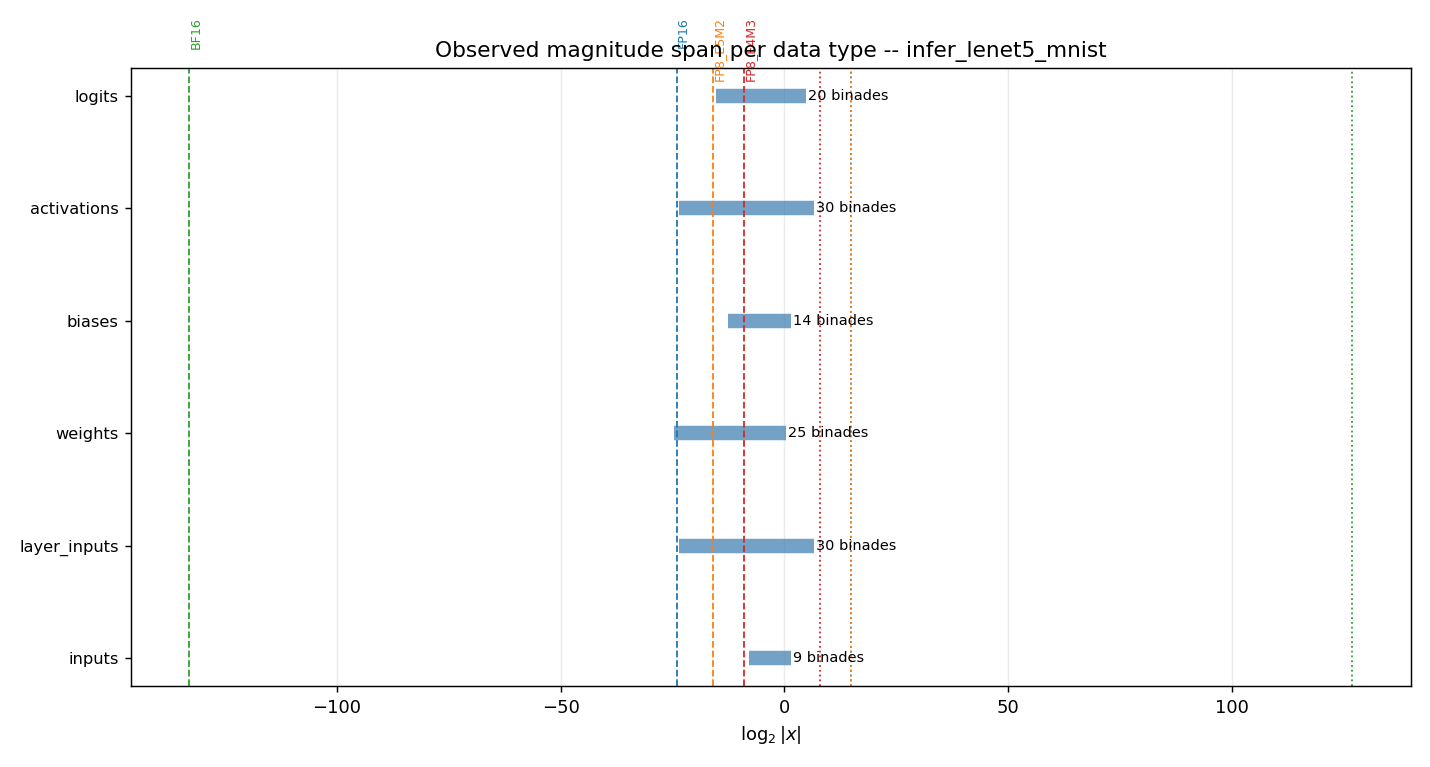


precision_analysis_results/figures/infer_lenet5_mnist/activations.png


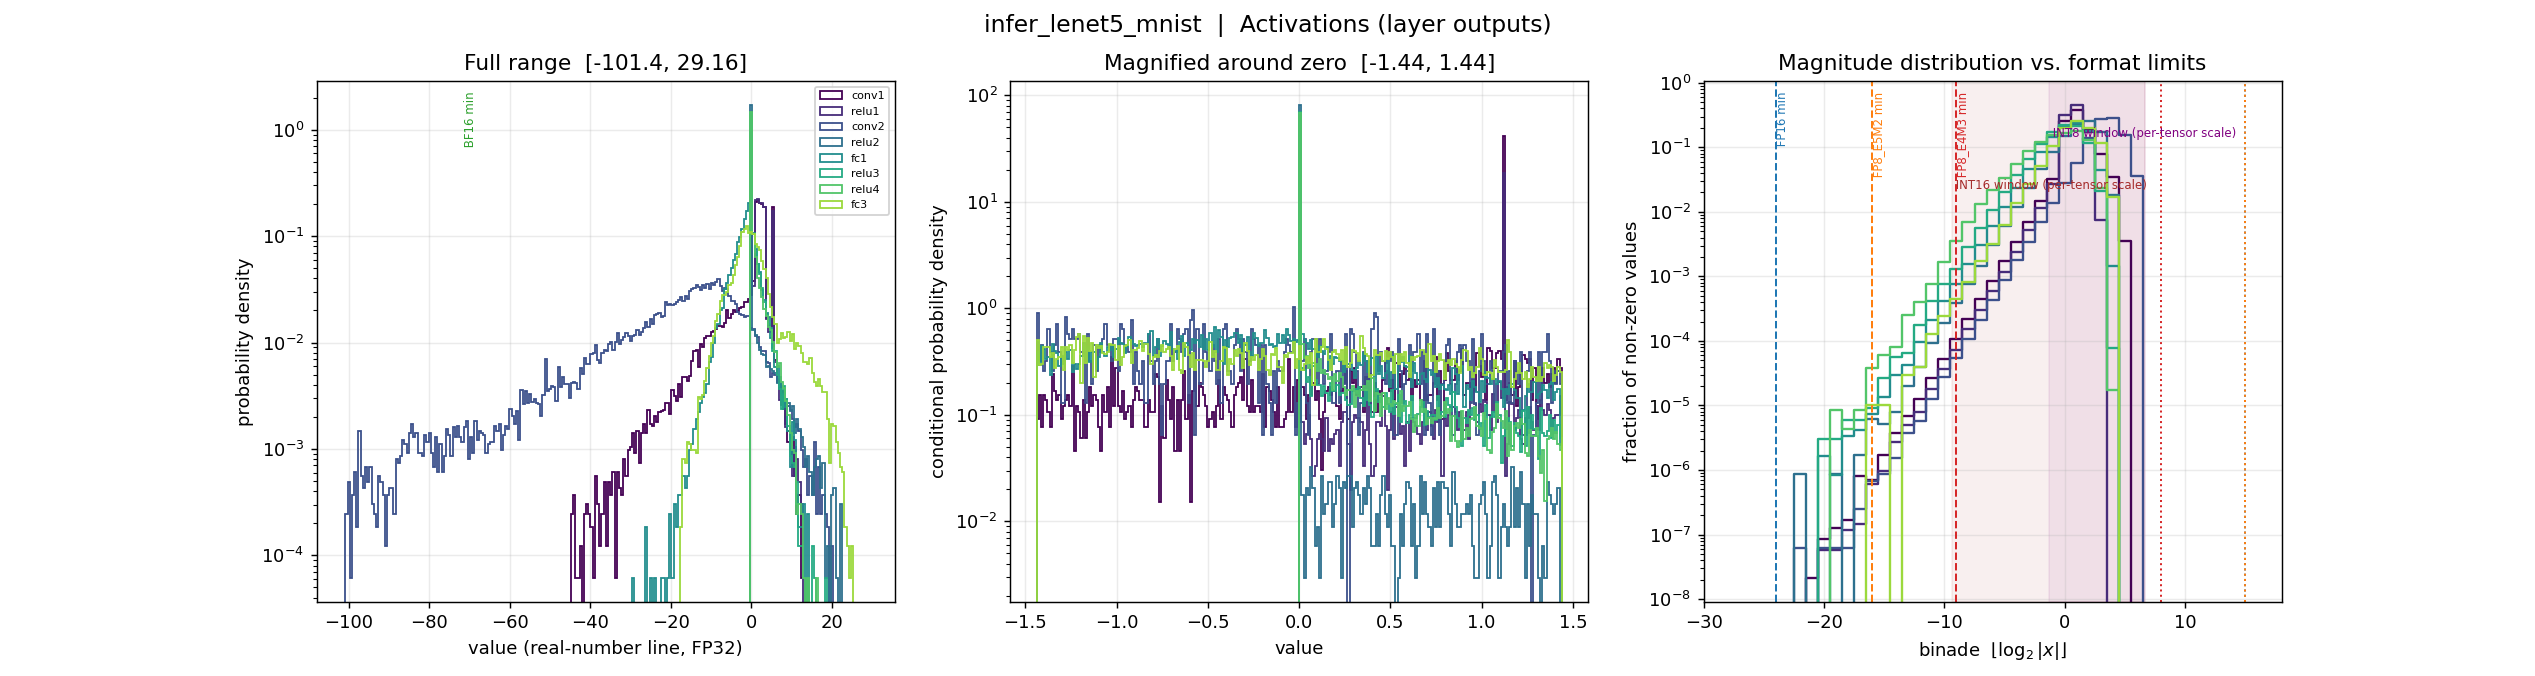


precision_analysis_results/figures/infer_lenet5_mnist/biases.png


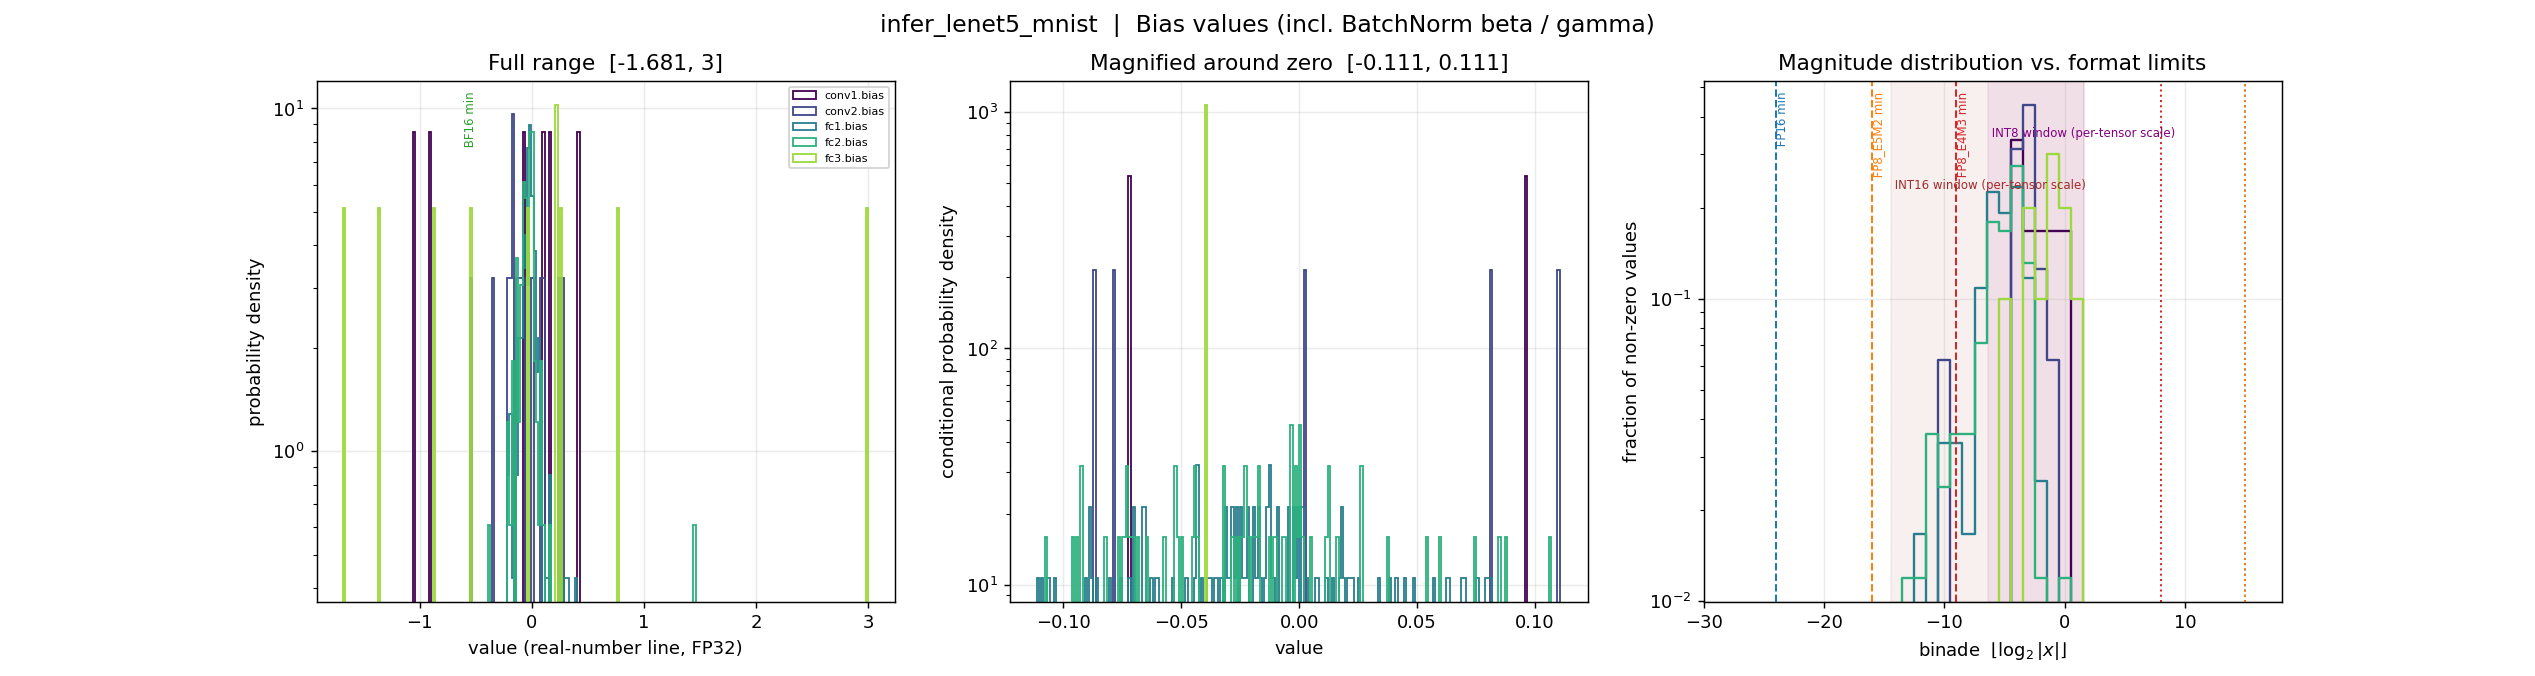


precision_analysis_results/figures/infer_lenet5_mnist/inputs.png


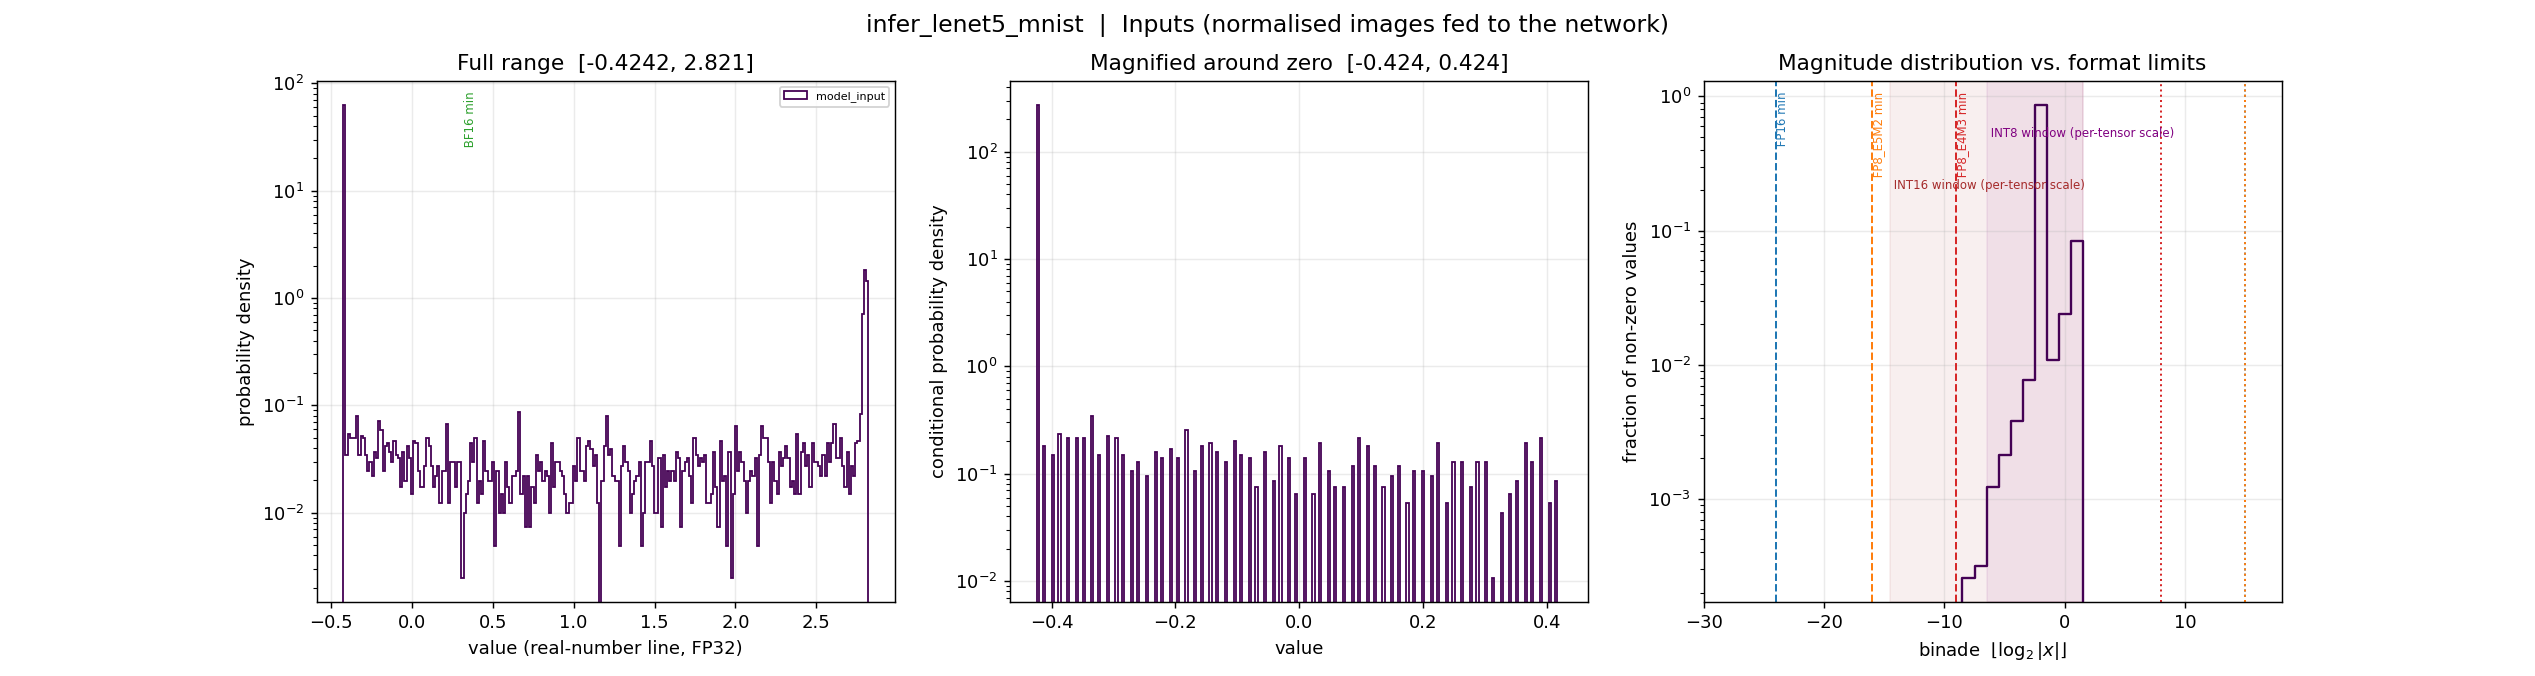


precision_analysis_results/figures/infer_lenet5_mnist/layer_inputs.png


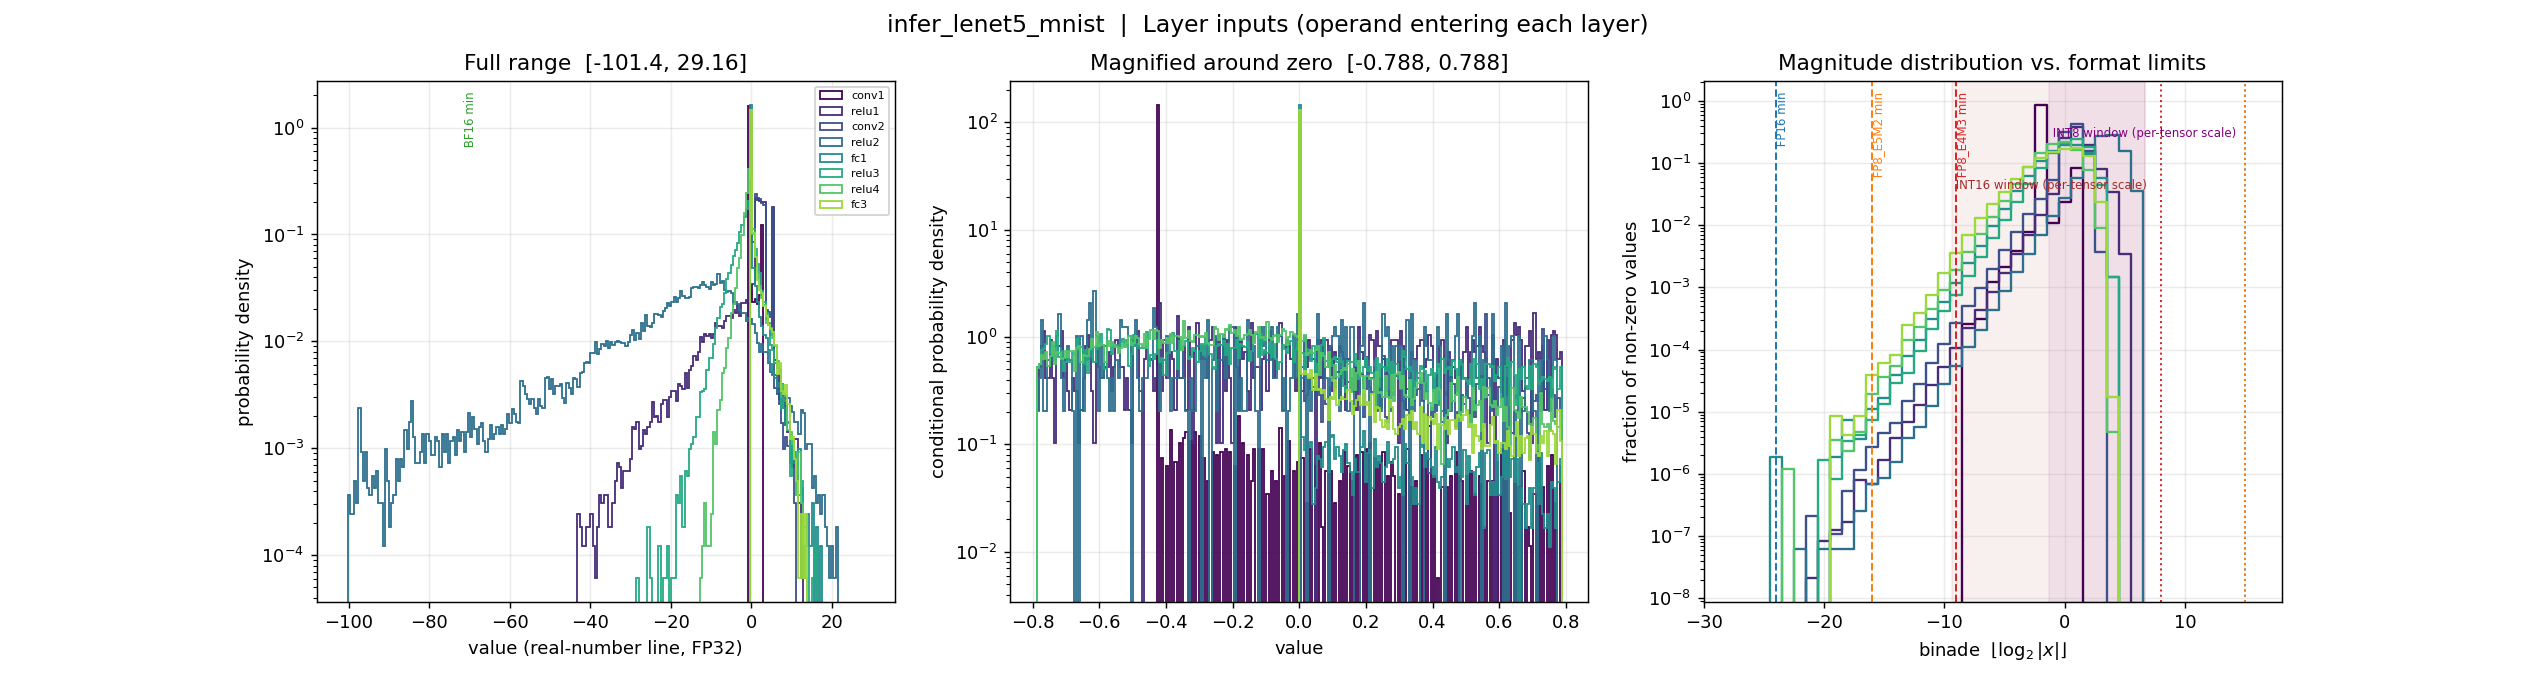


precision_analysis_results/figures/infer_lenet5_mnist/logits.png


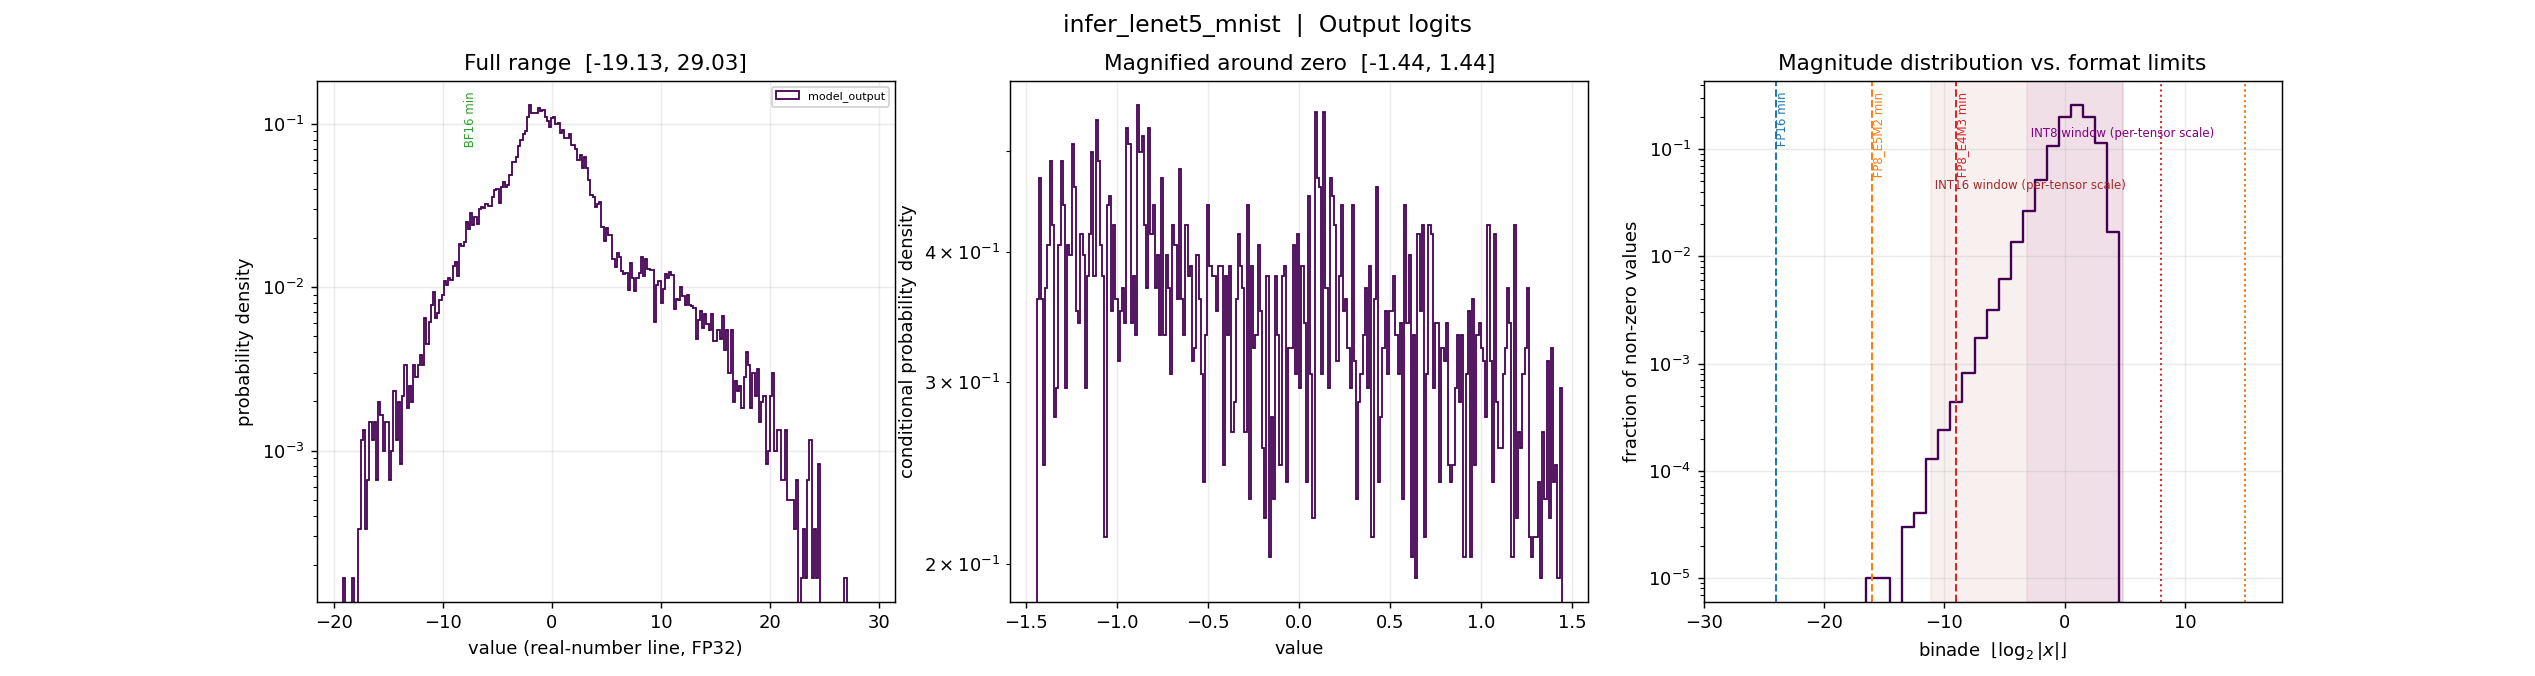


precision_analysis_results/figures/infer_lenet5_mnist/weights.png


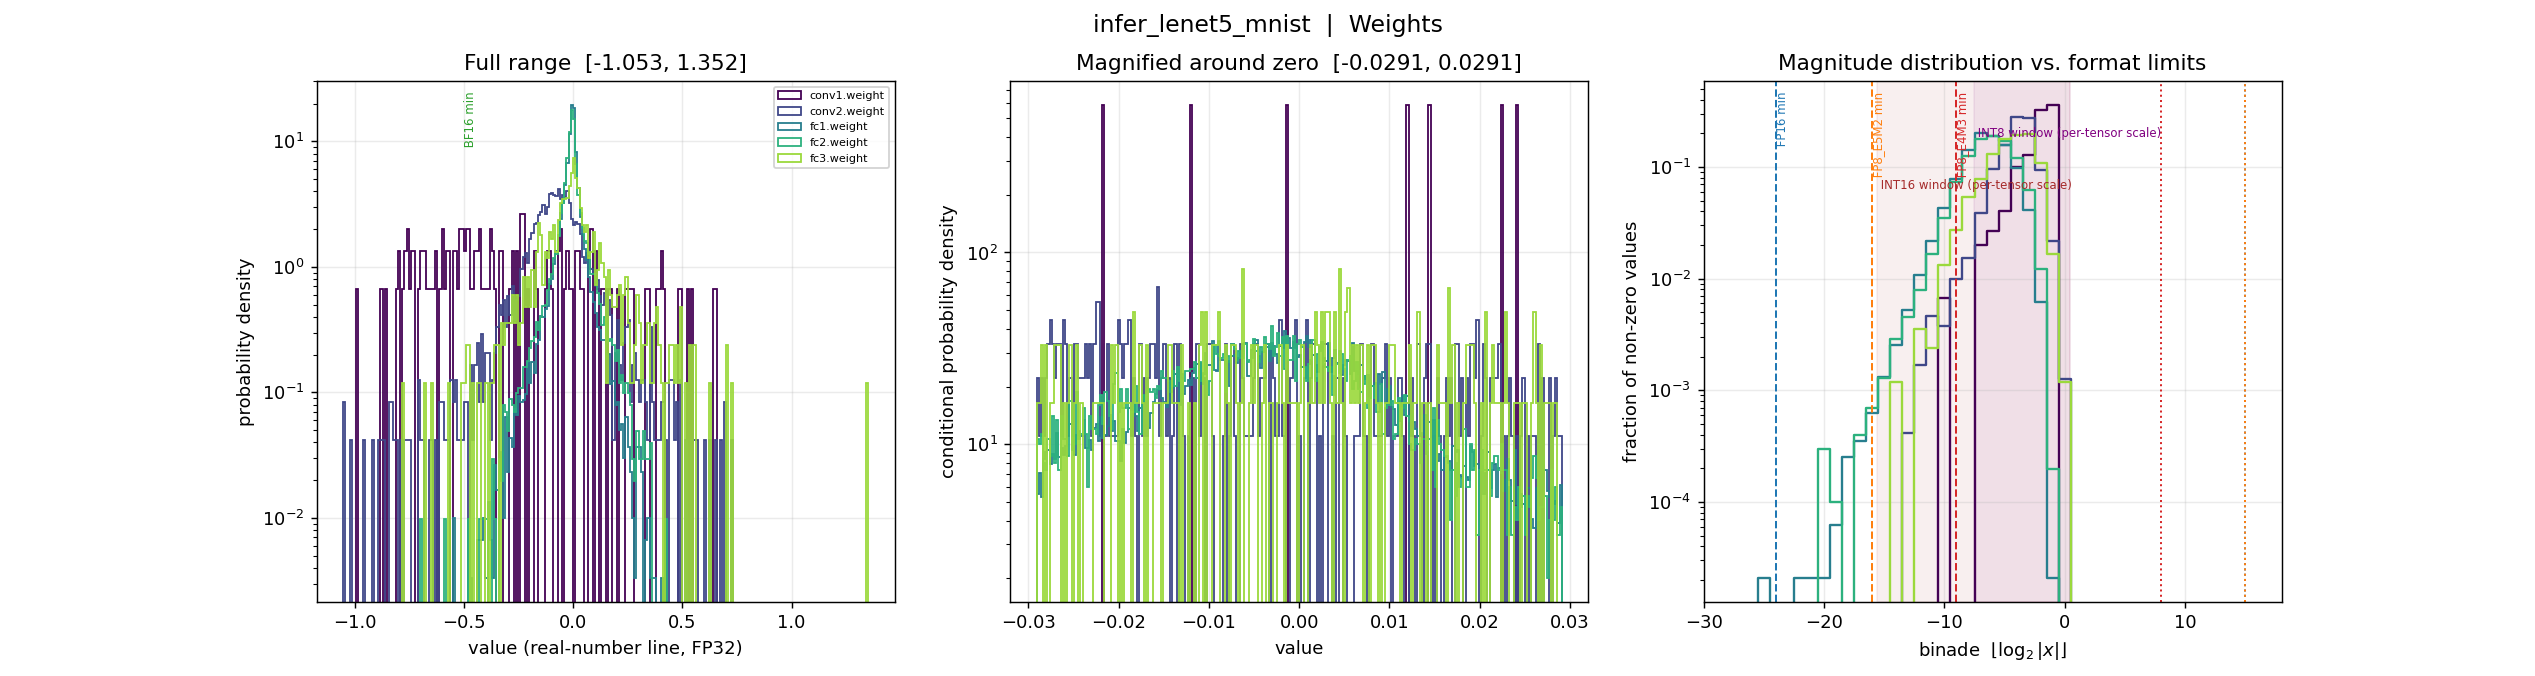


precision_analysis_results/figures/infer_mobilenetv2_cifar100/_range_overview.png


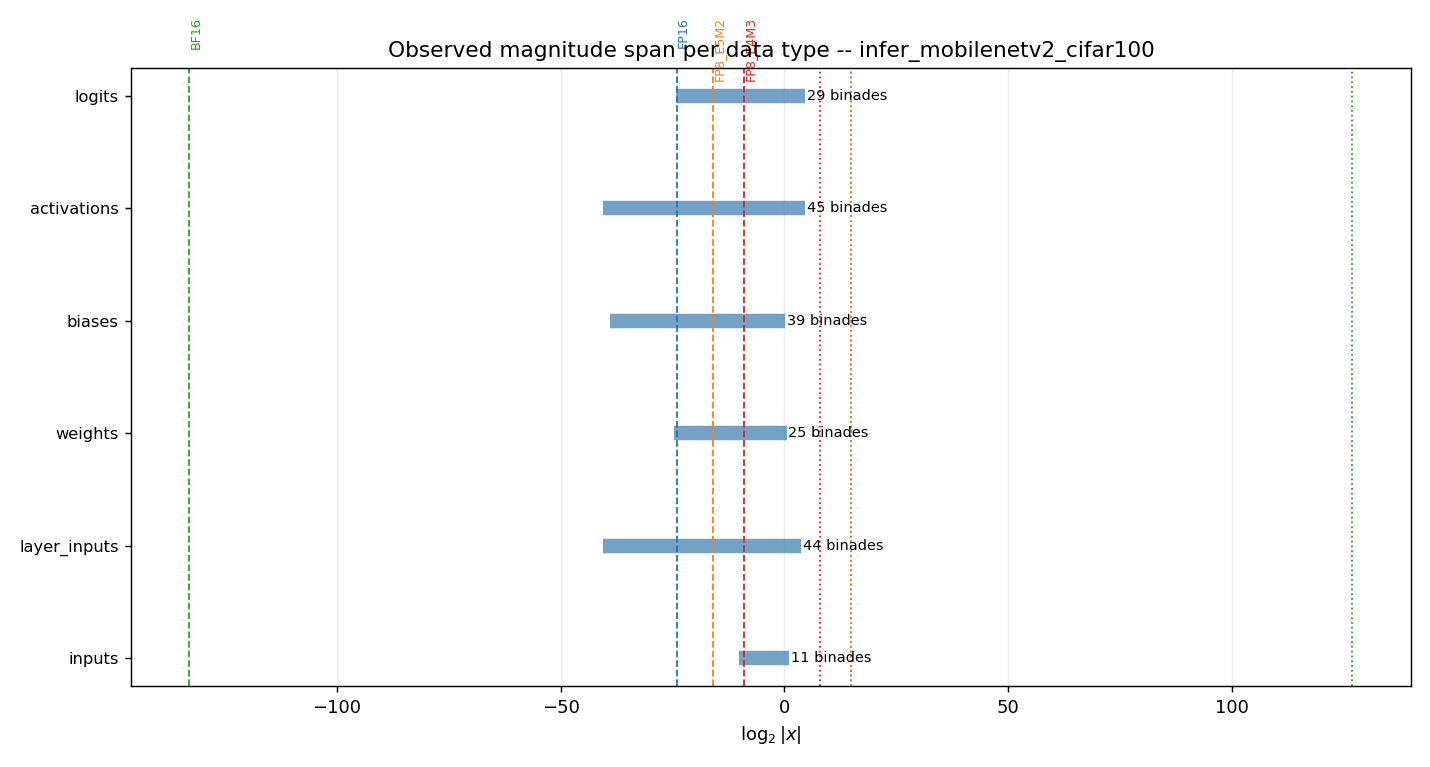


precision_analysis_results/figures/infer_mobilenetv2_cifar100/activations.png


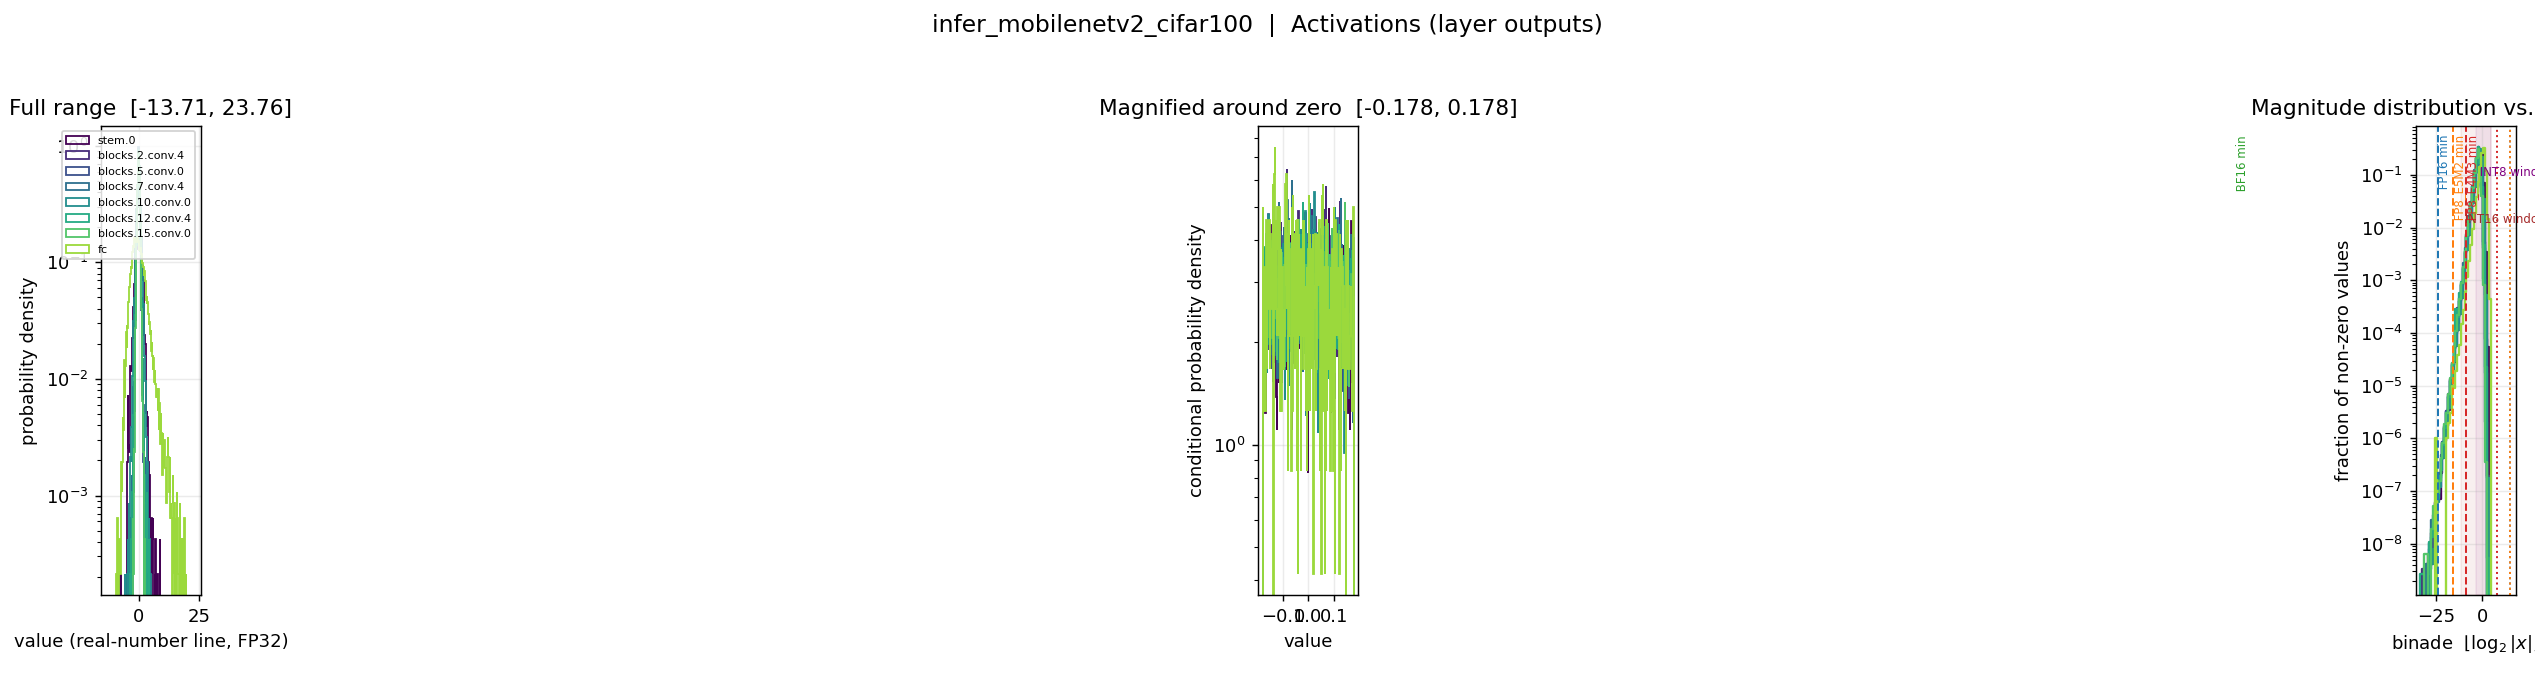


precision_analysis_results/figures/infer_mobilenetv2_cifar100/biases.png


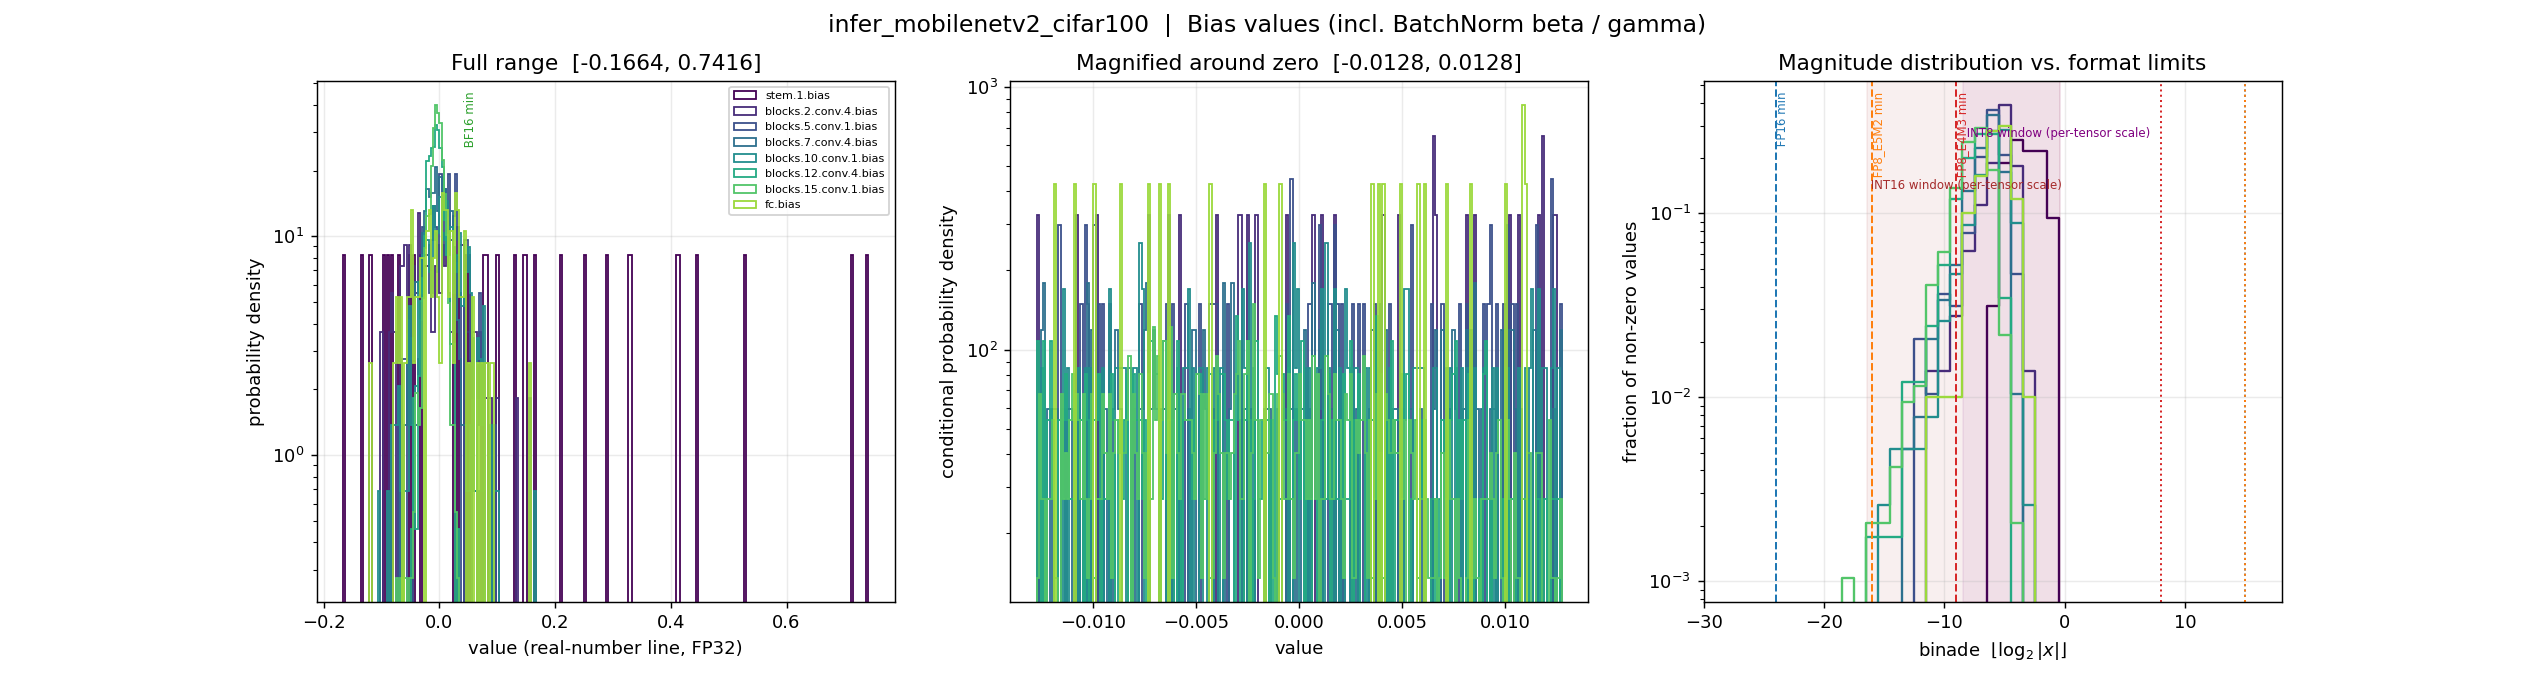


precision_analysis_results/figures/infer_mobilenetv2_cifar100/inputs.png


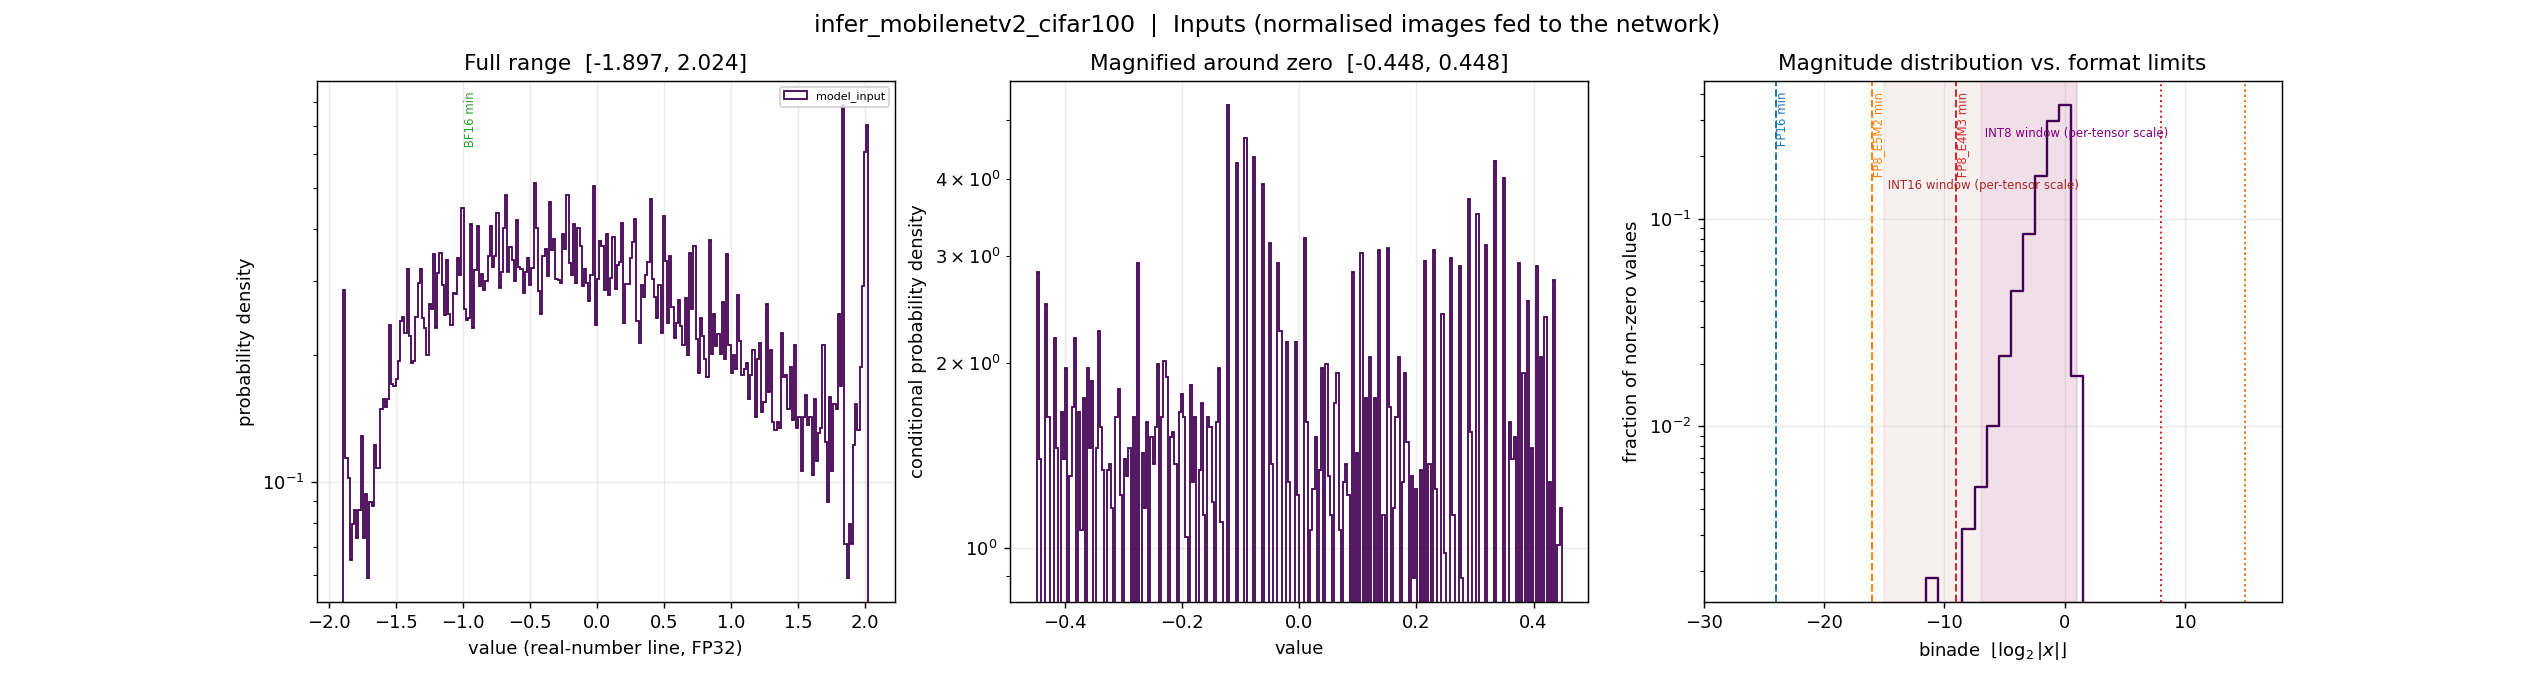


precision_analysis_results/figures/infer_mobilenetv2_cifar100/layer_inputs.png


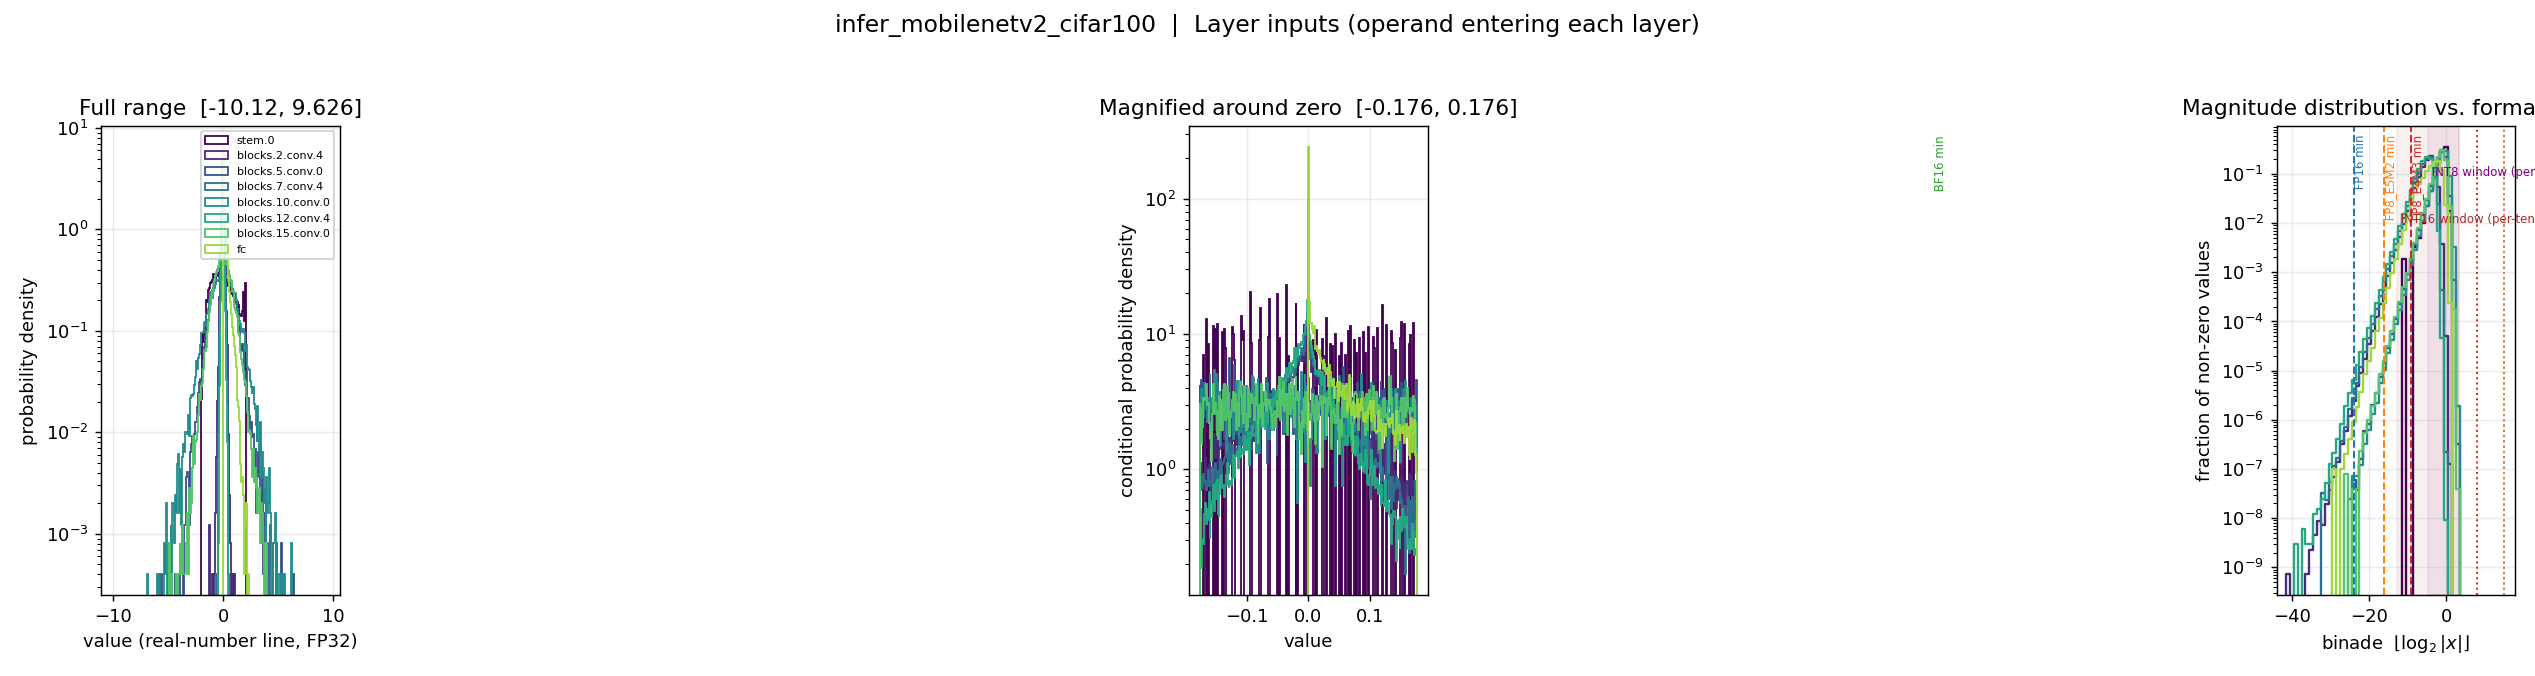


precision_analysis_results/figures/infer_mobilenetv2_cifar100/logits.png


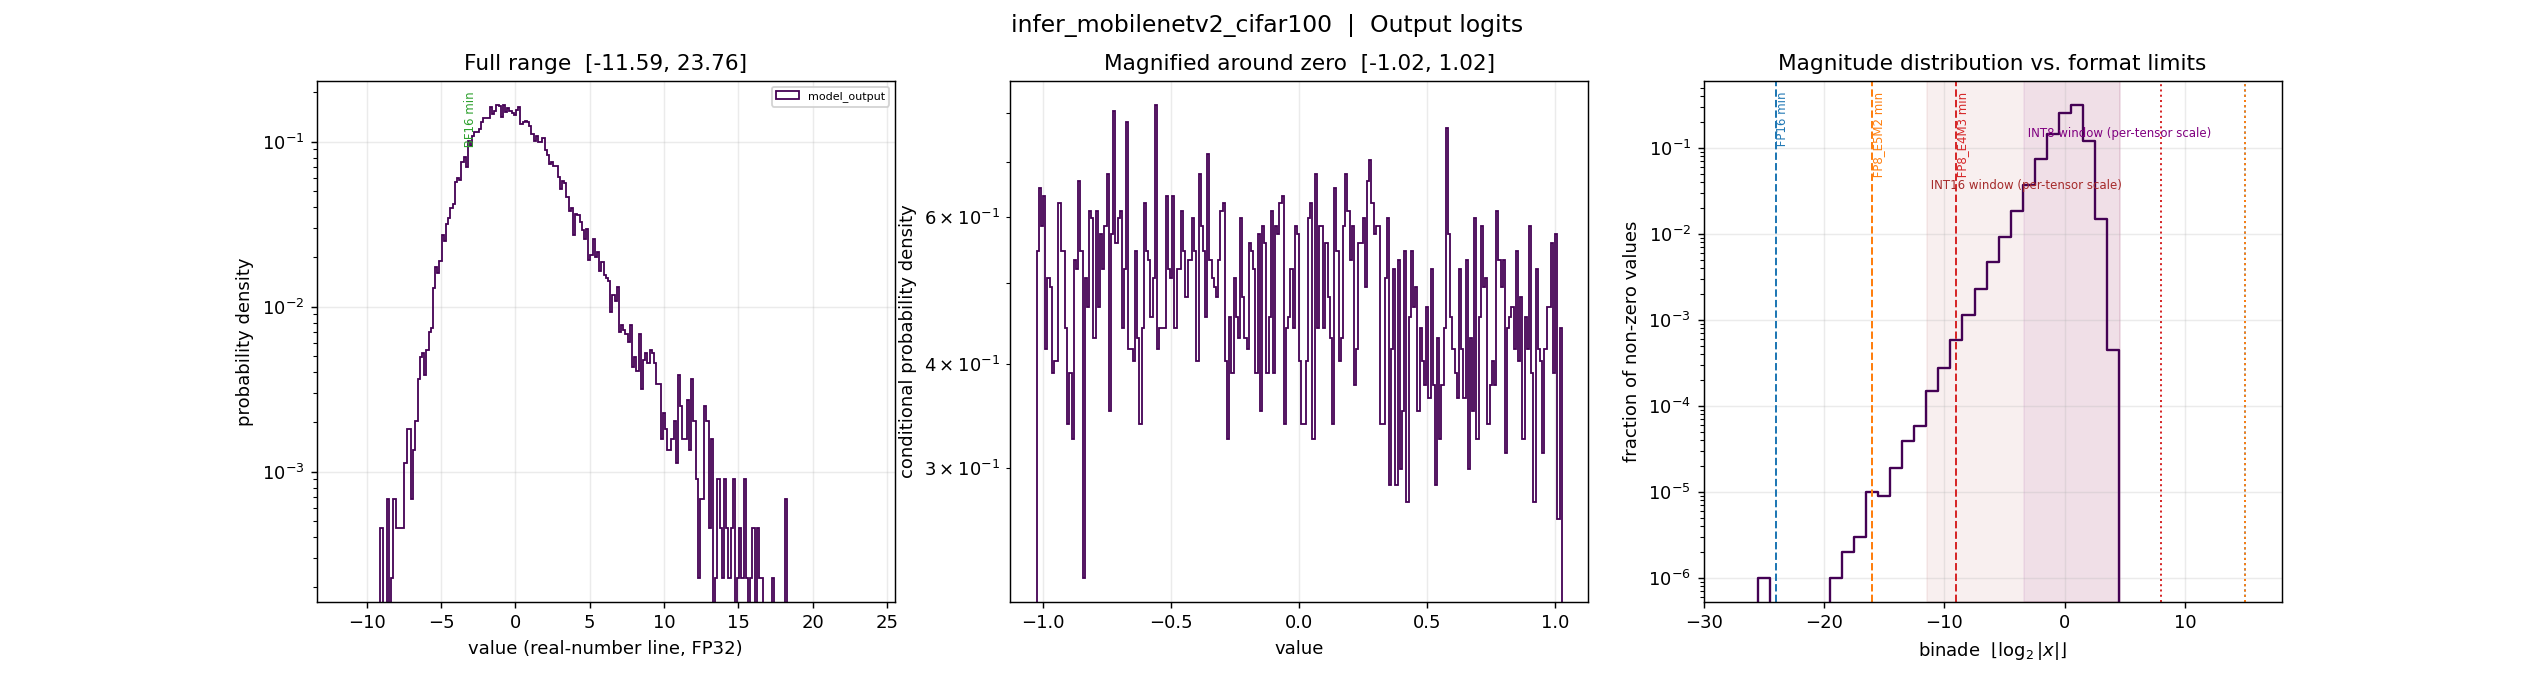


precision_analysis_results/figures/infer_mobilenetv2_cifar100/weights.png


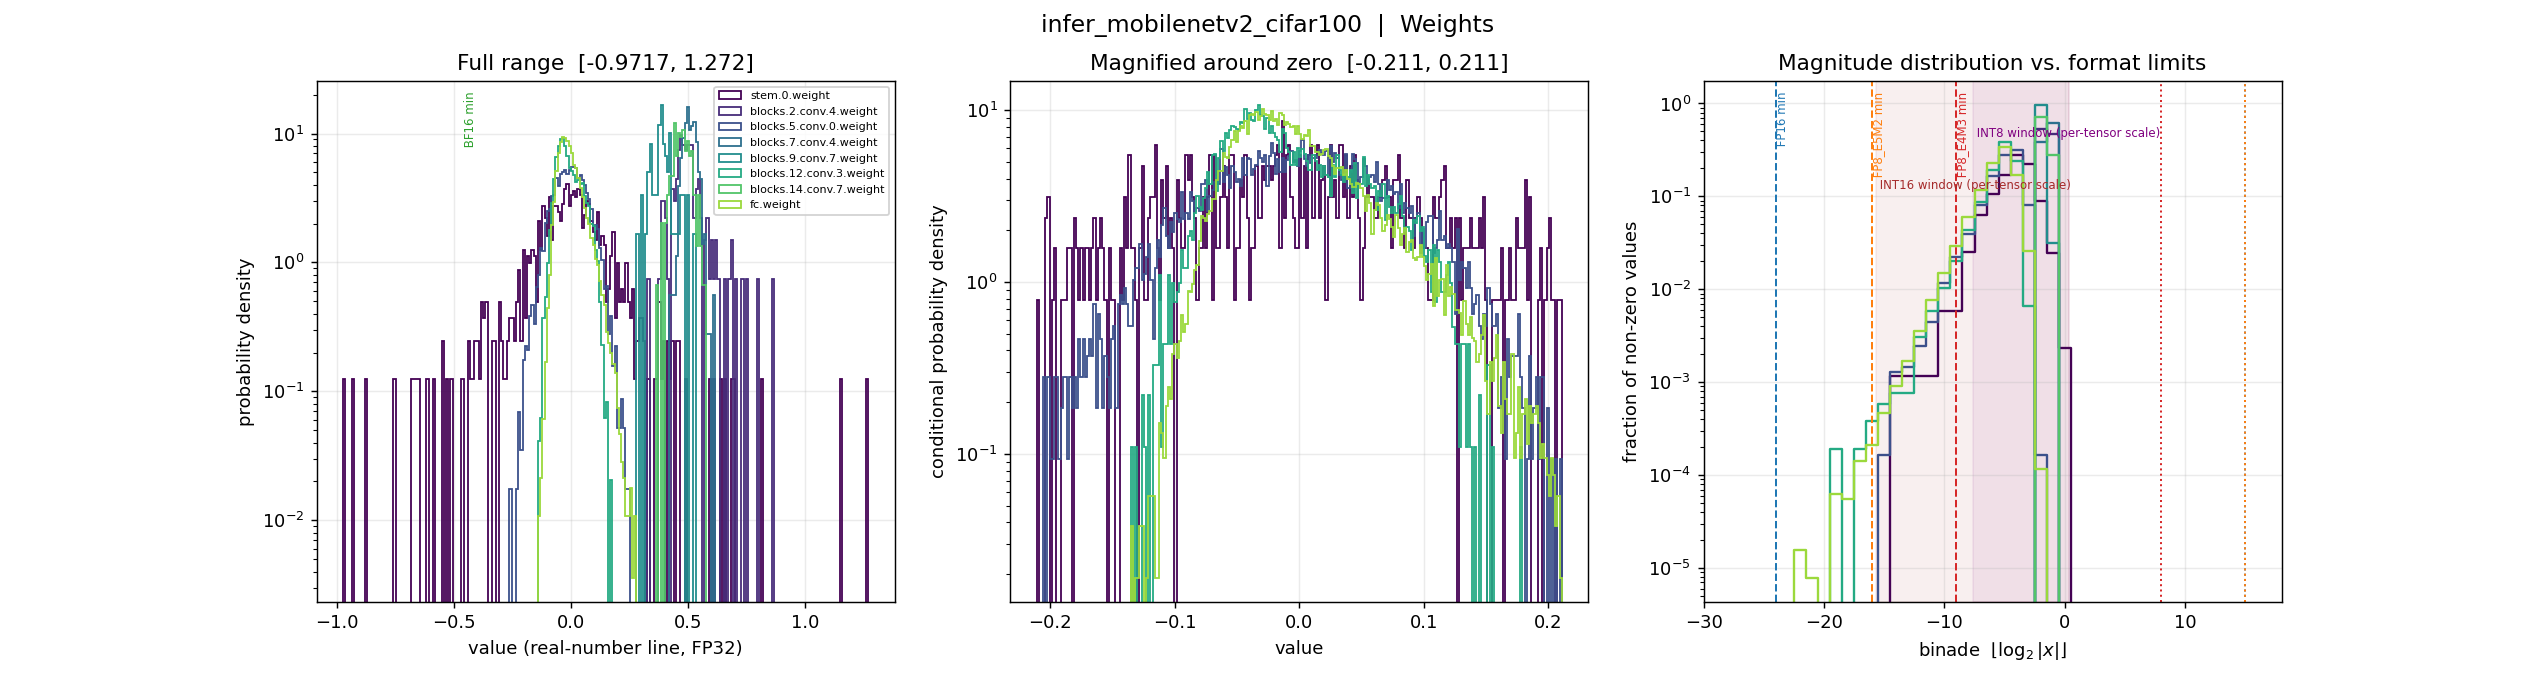


precision_analysis_results/figures/infer_resnet18_cifar10/_range_overview.png


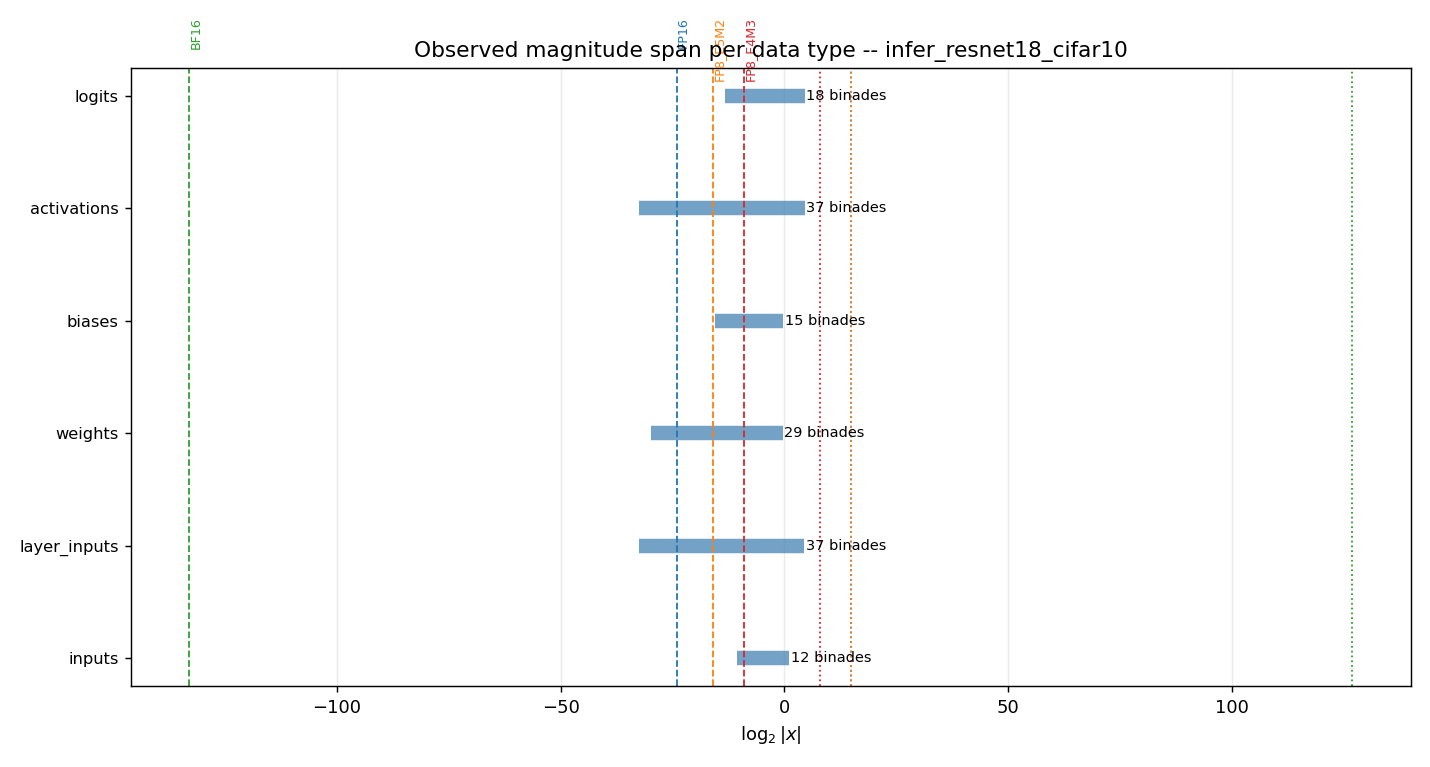


precision_analysis_results/figures/infer_resnet18_cifar10/activations.png


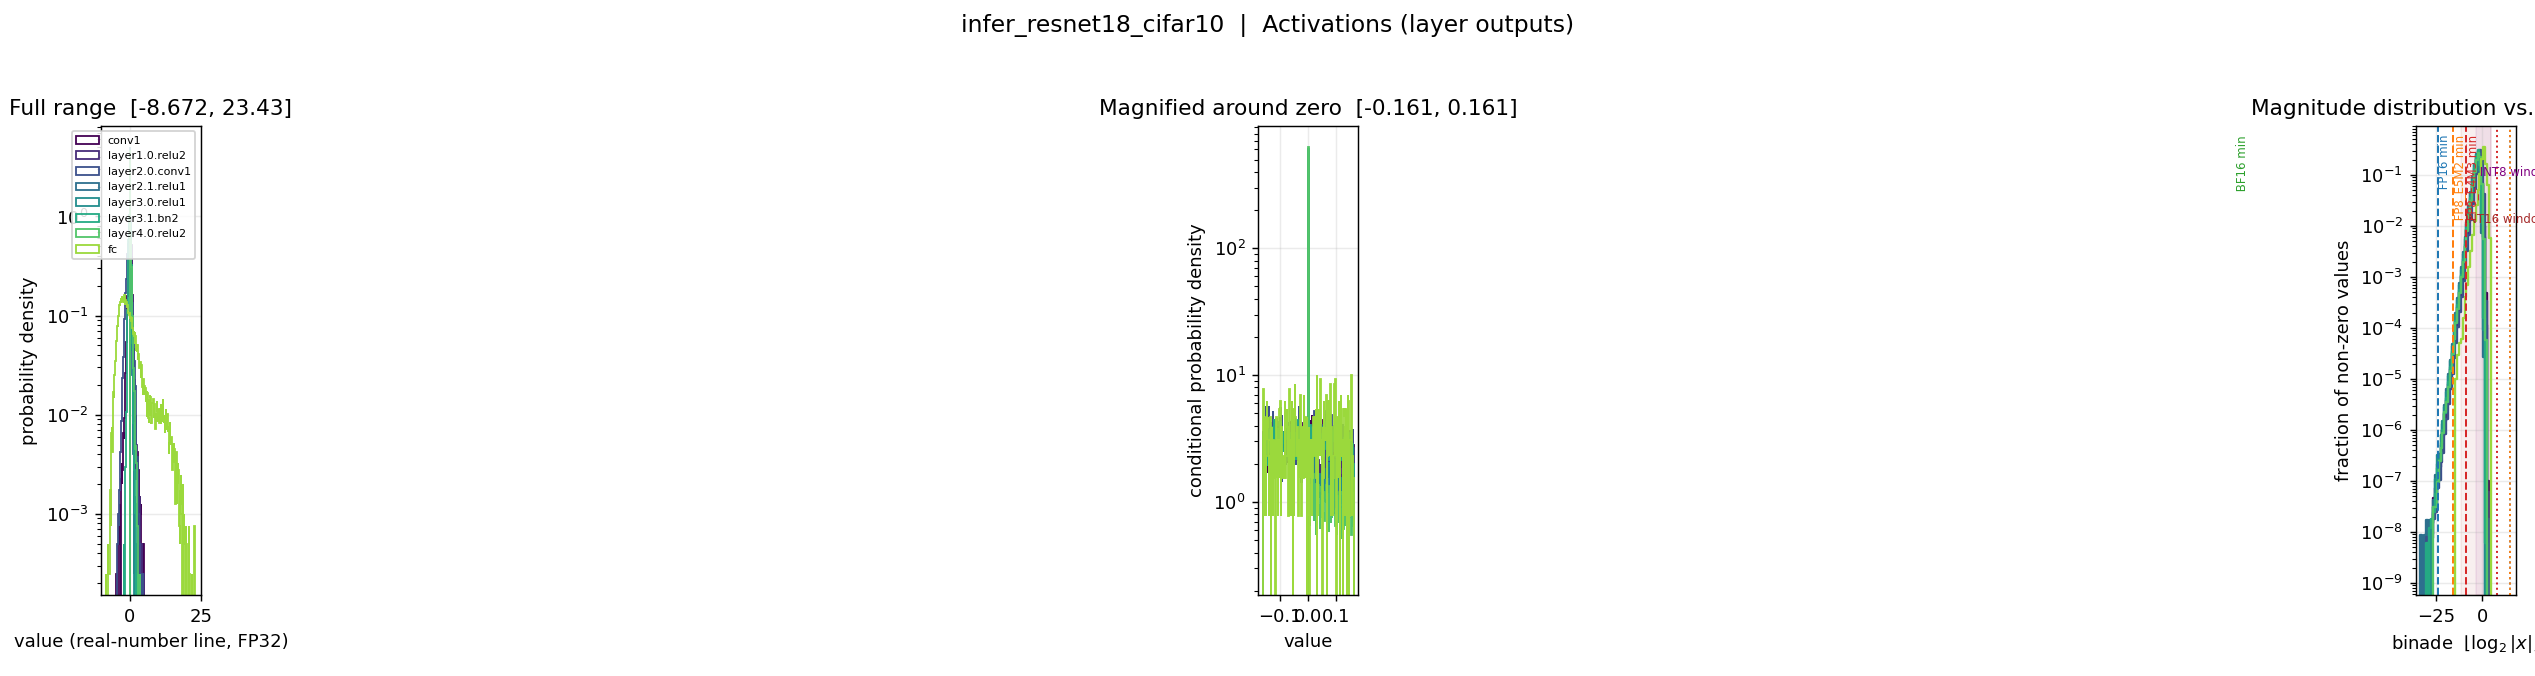


precision_analysis_results/figures/infer_resnet18_cifar10/biases.png


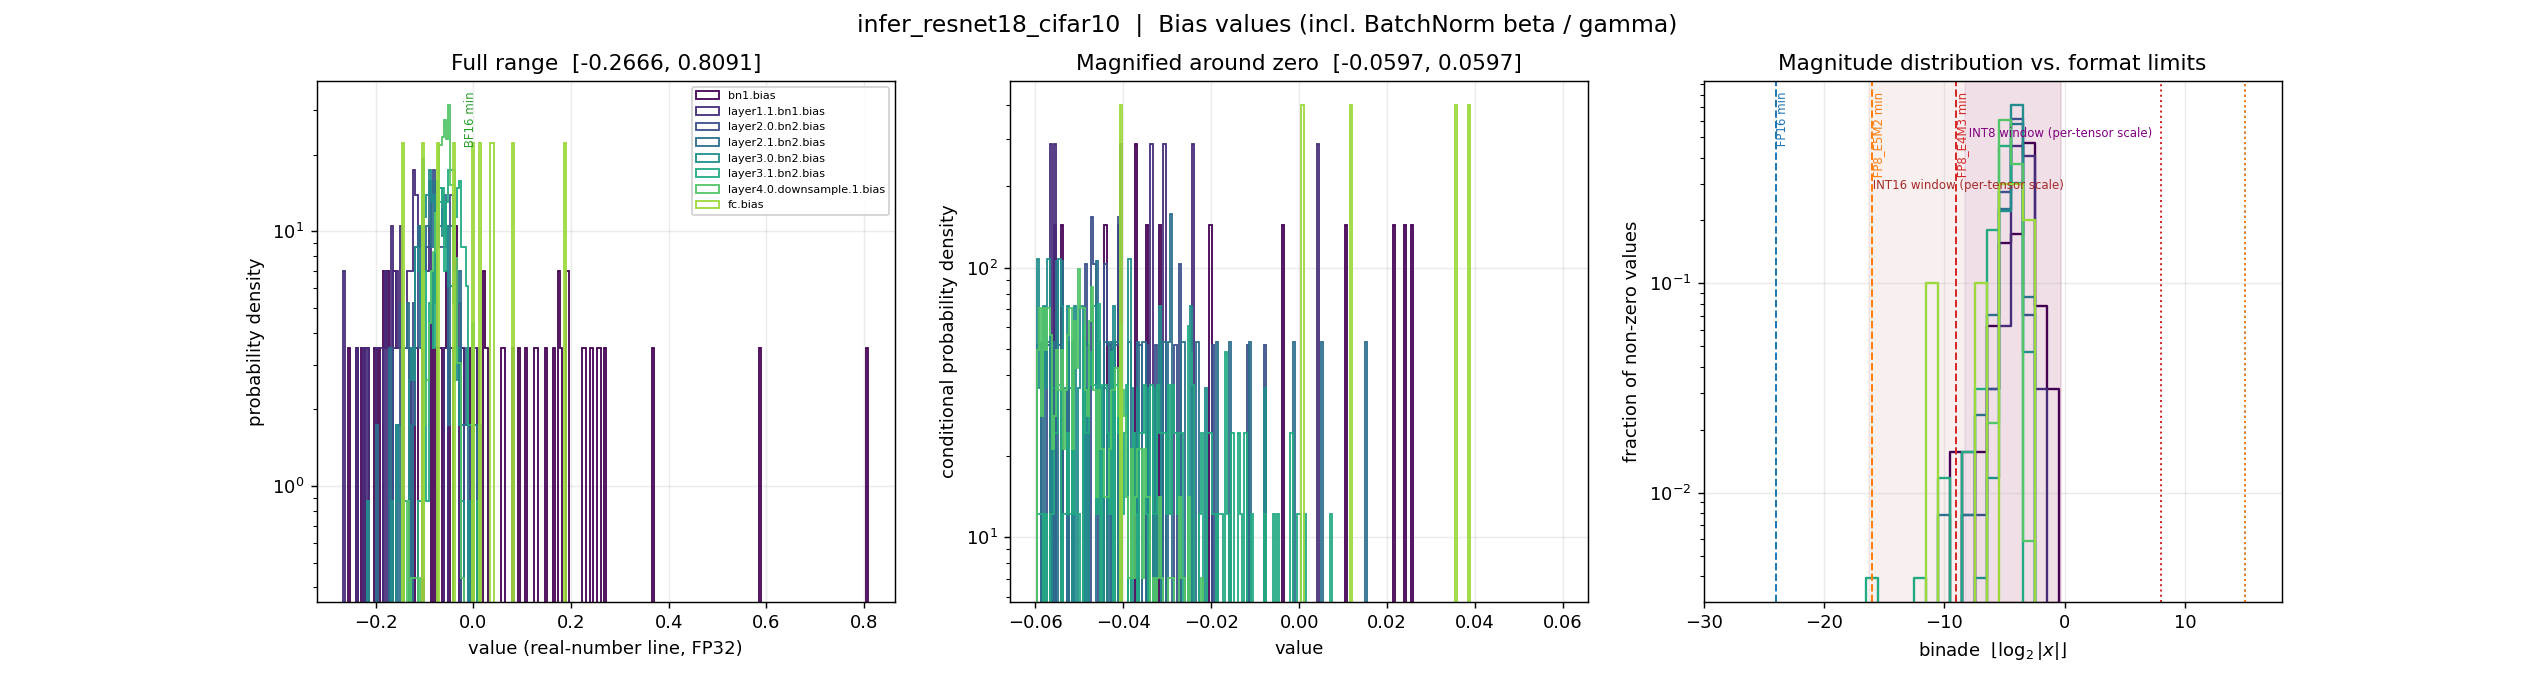


precision_analysis_results/figures/infer_resnet18_cifar10/inputs.png


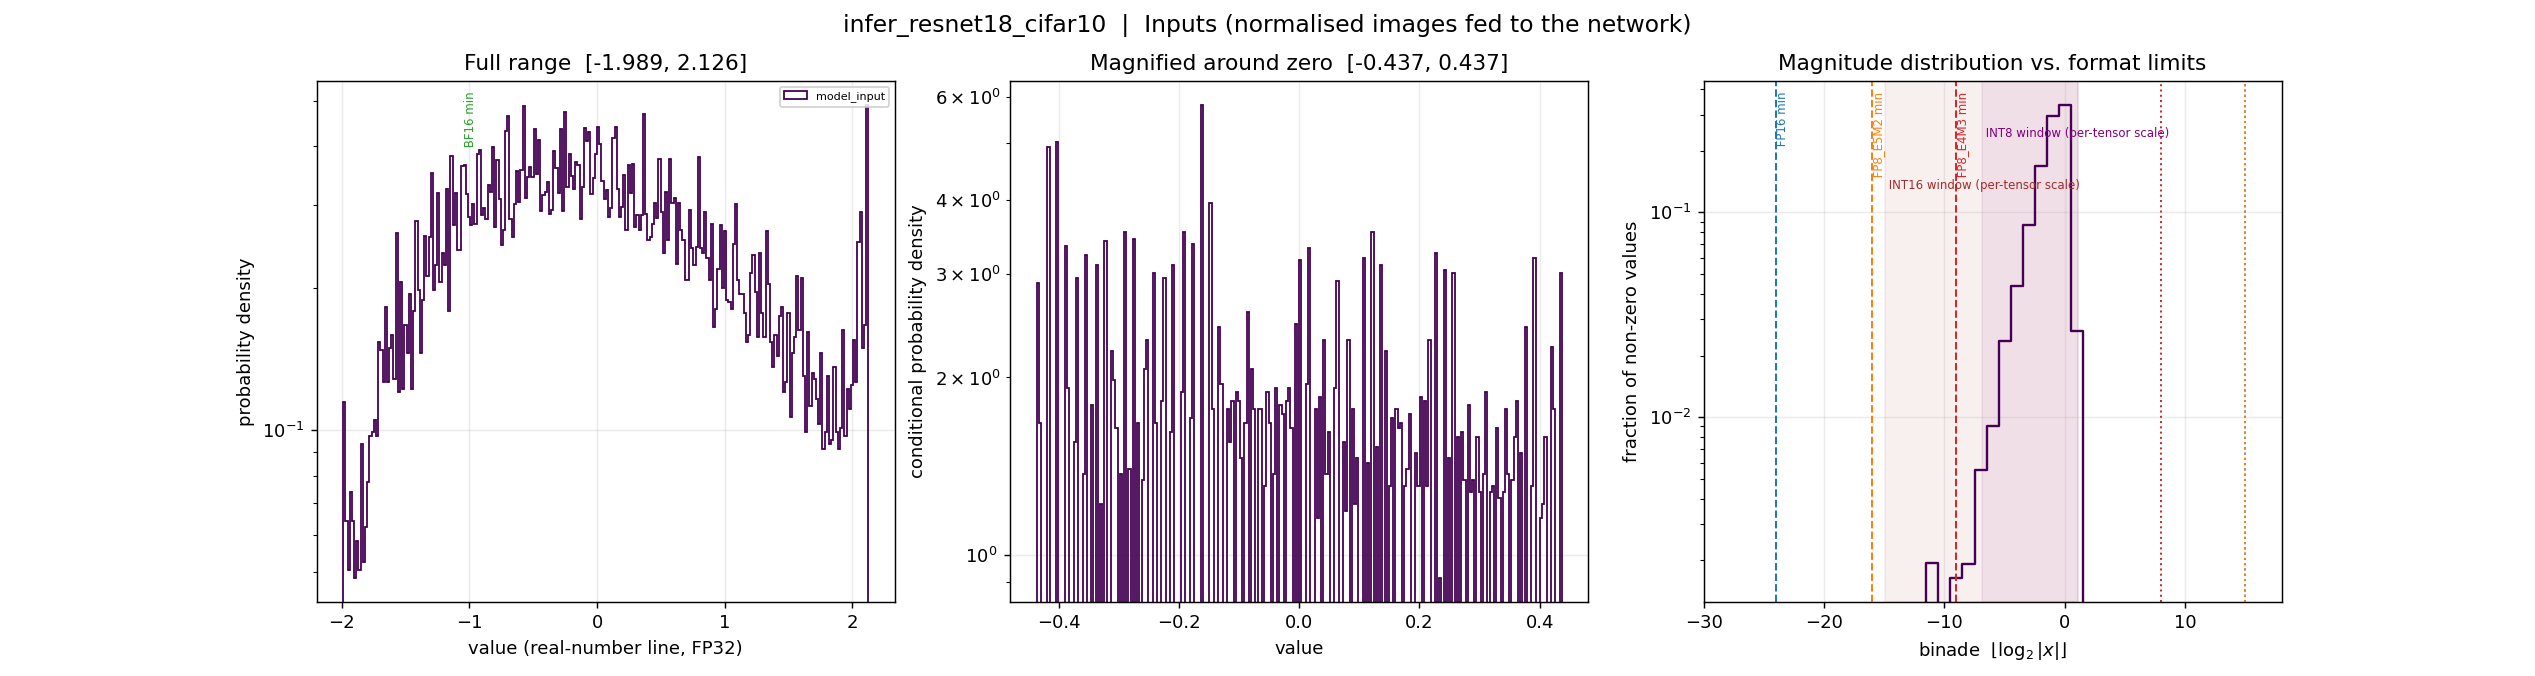


precision_analysis_results/figures/infer_resnet18_cifar10/layer_inputs.png


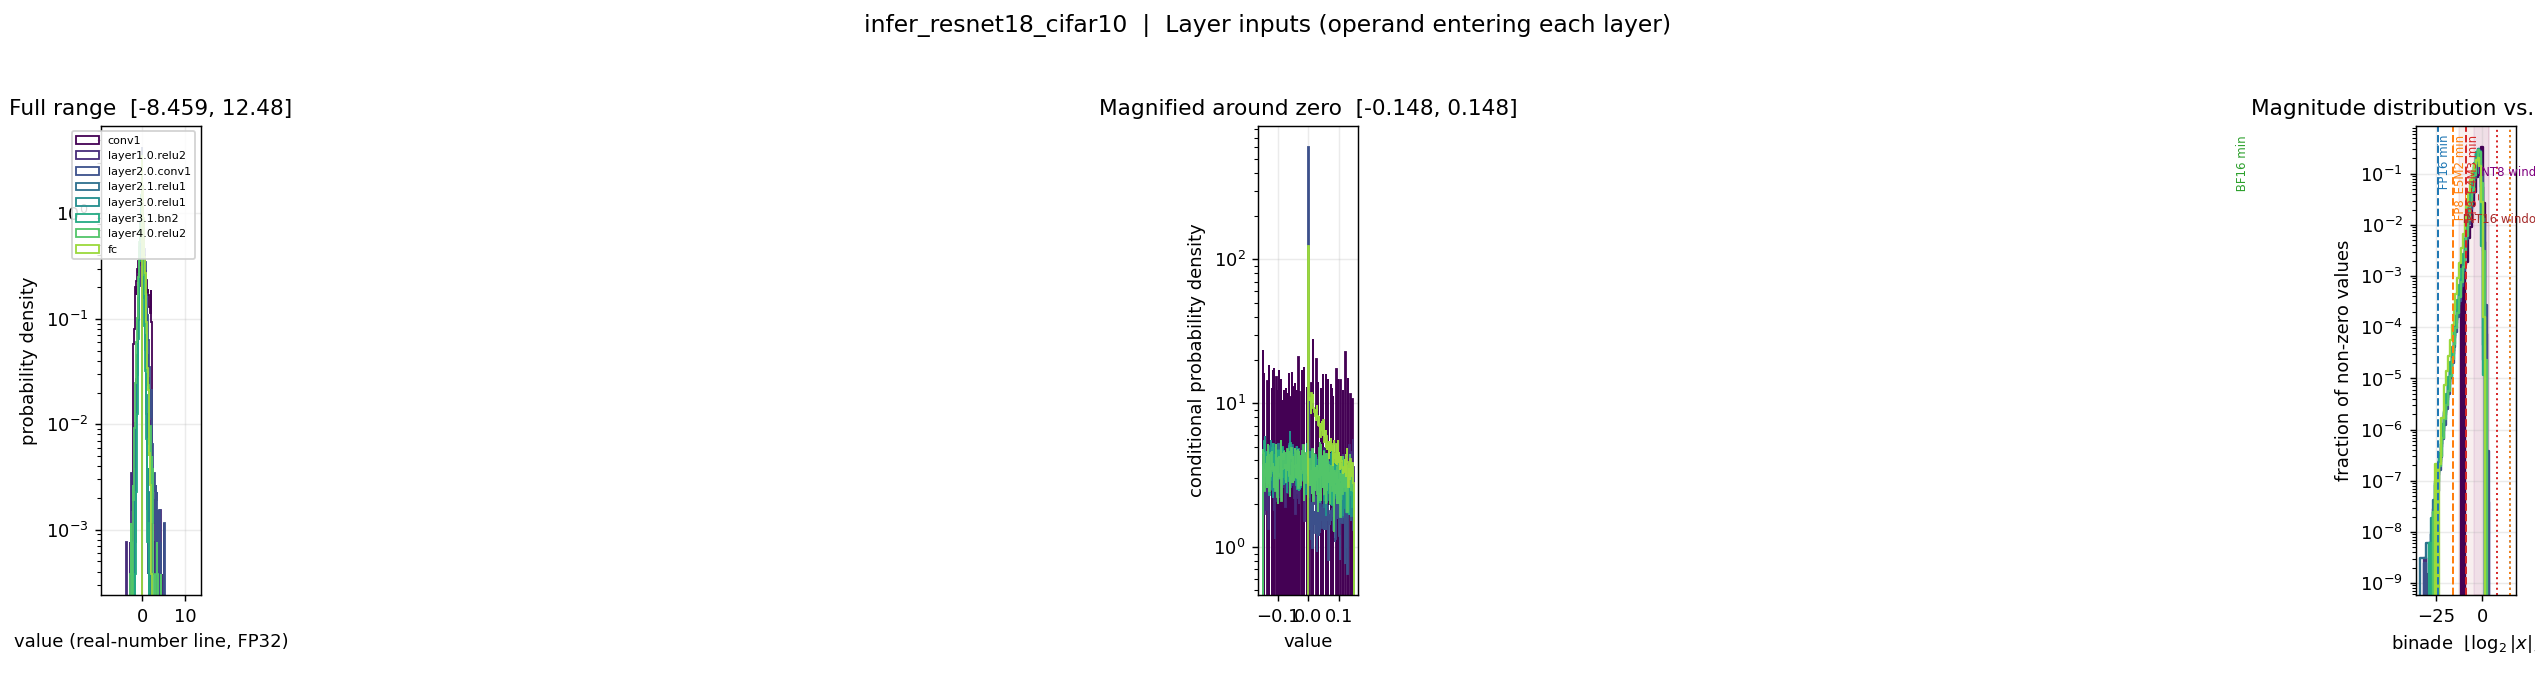


precision_analysis_results/figures/infer_resnet18_cifar10/logits.png


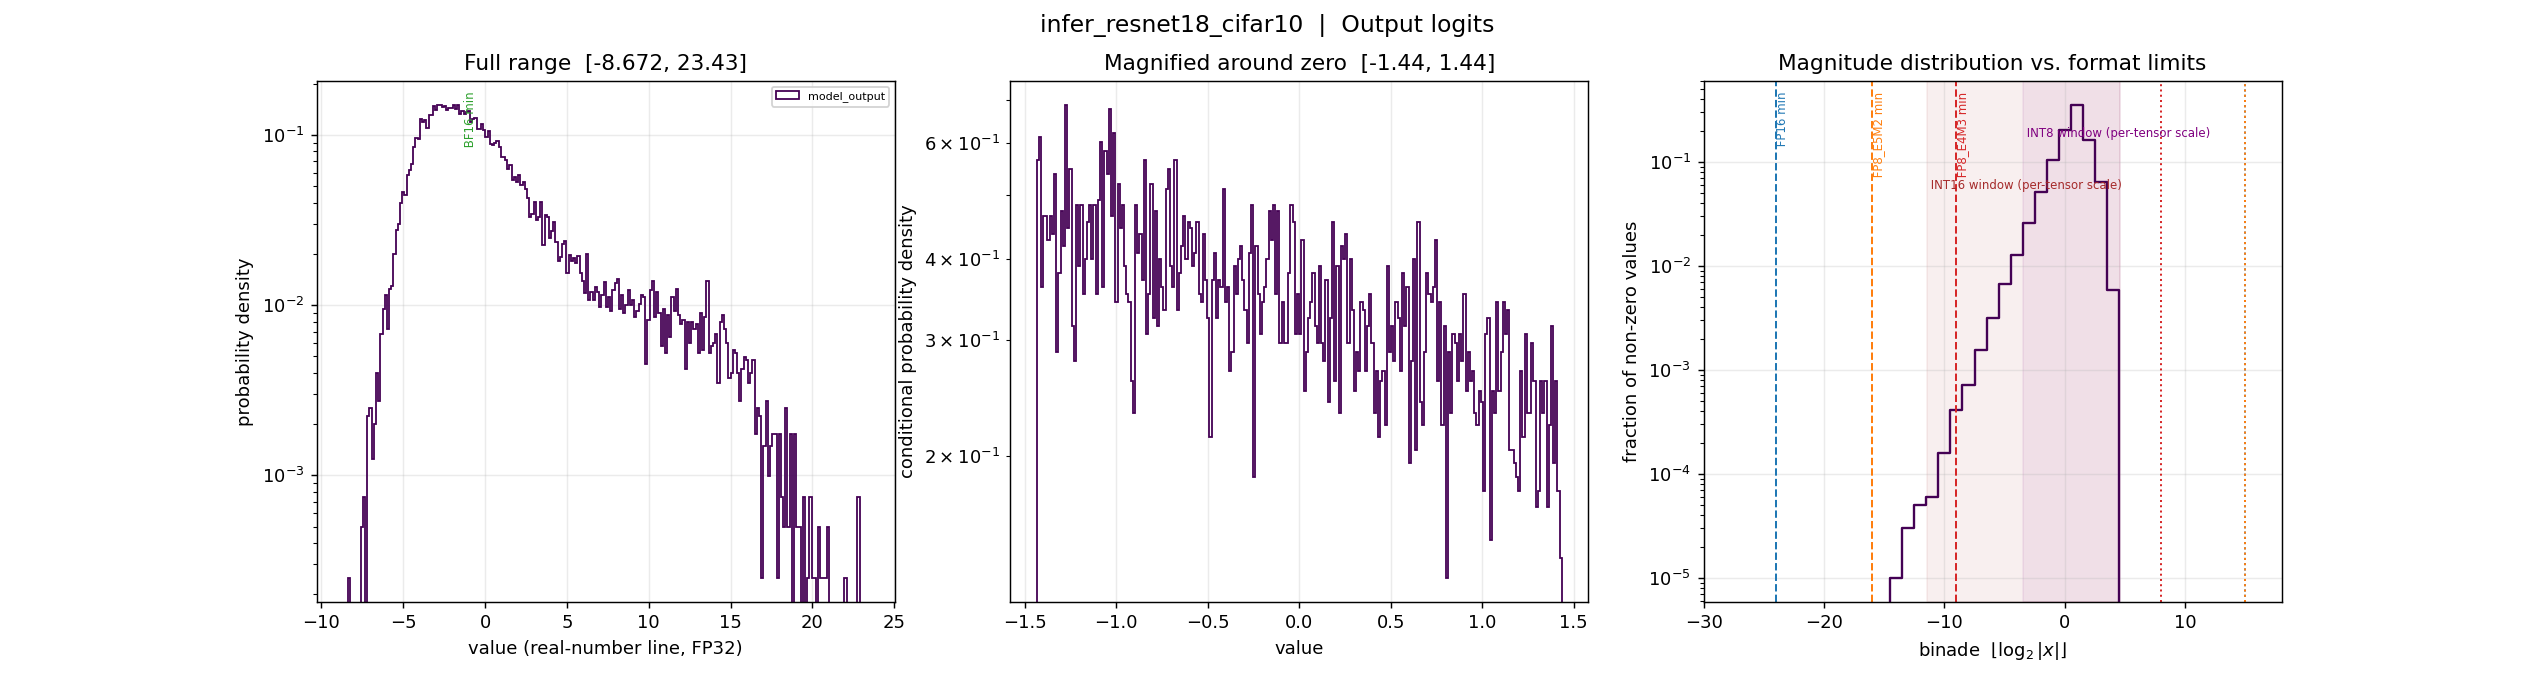


precision_analysis_results/figures/infer_resnet18_cifar10/weights.png


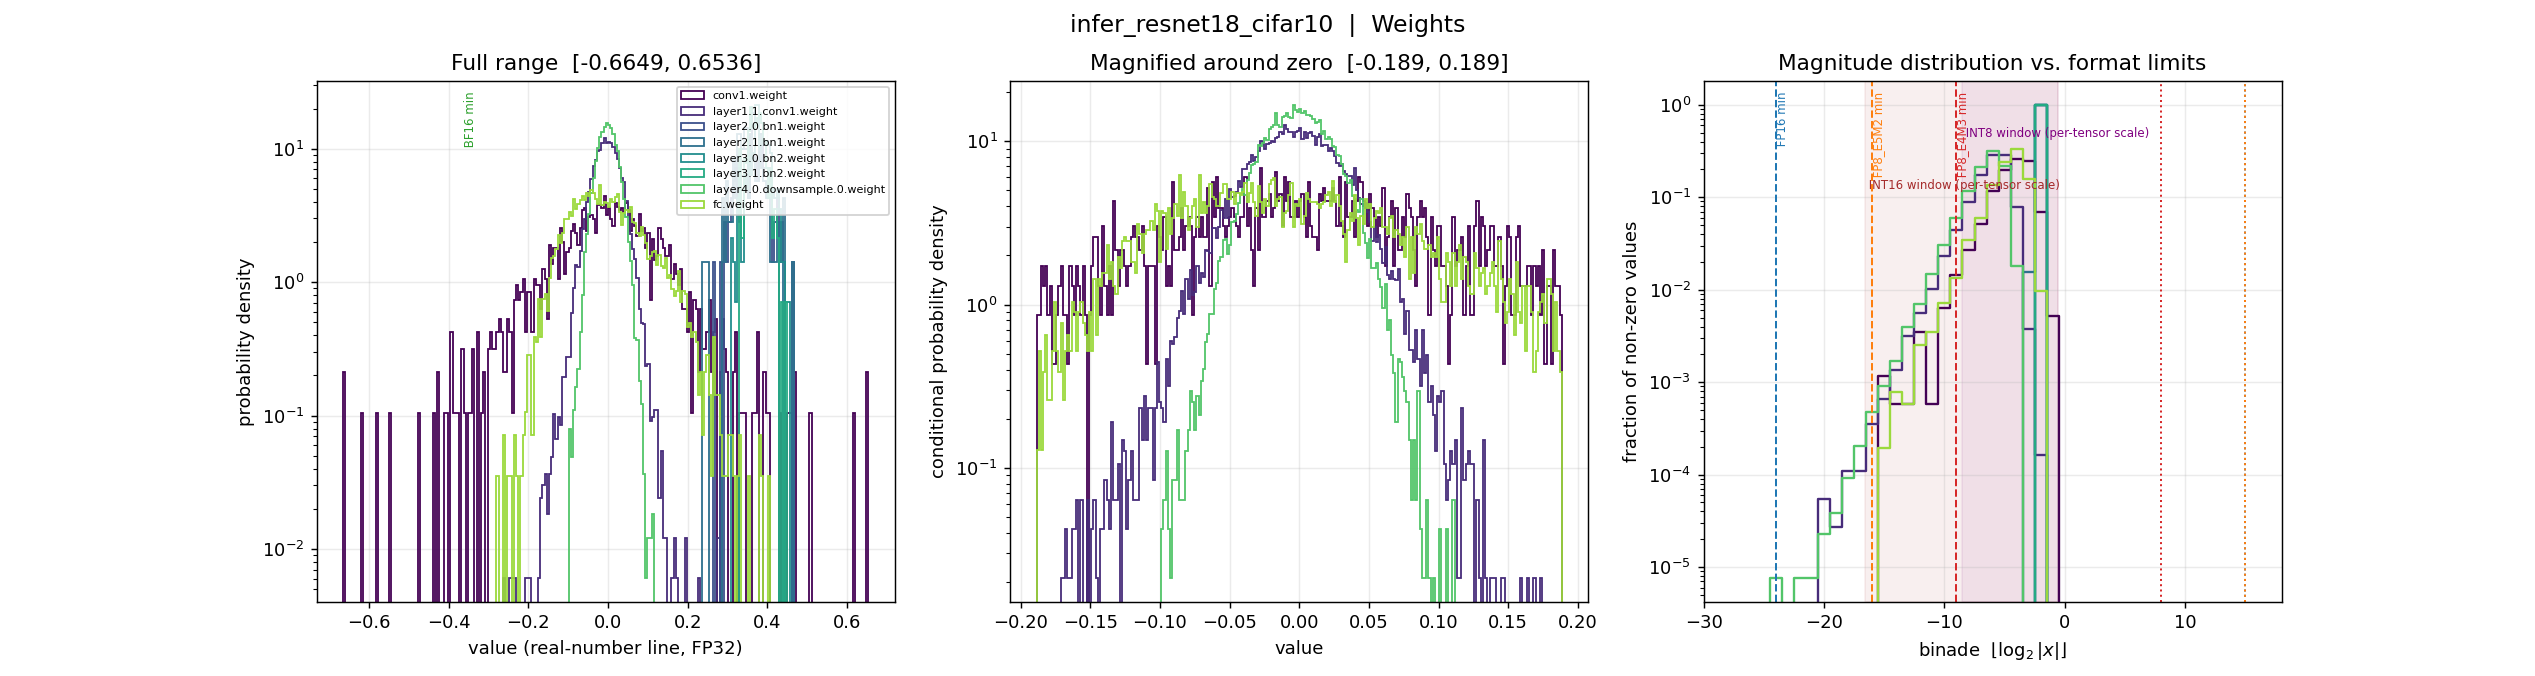


precision_analysis_results/figures/train_end/_range_overview.png


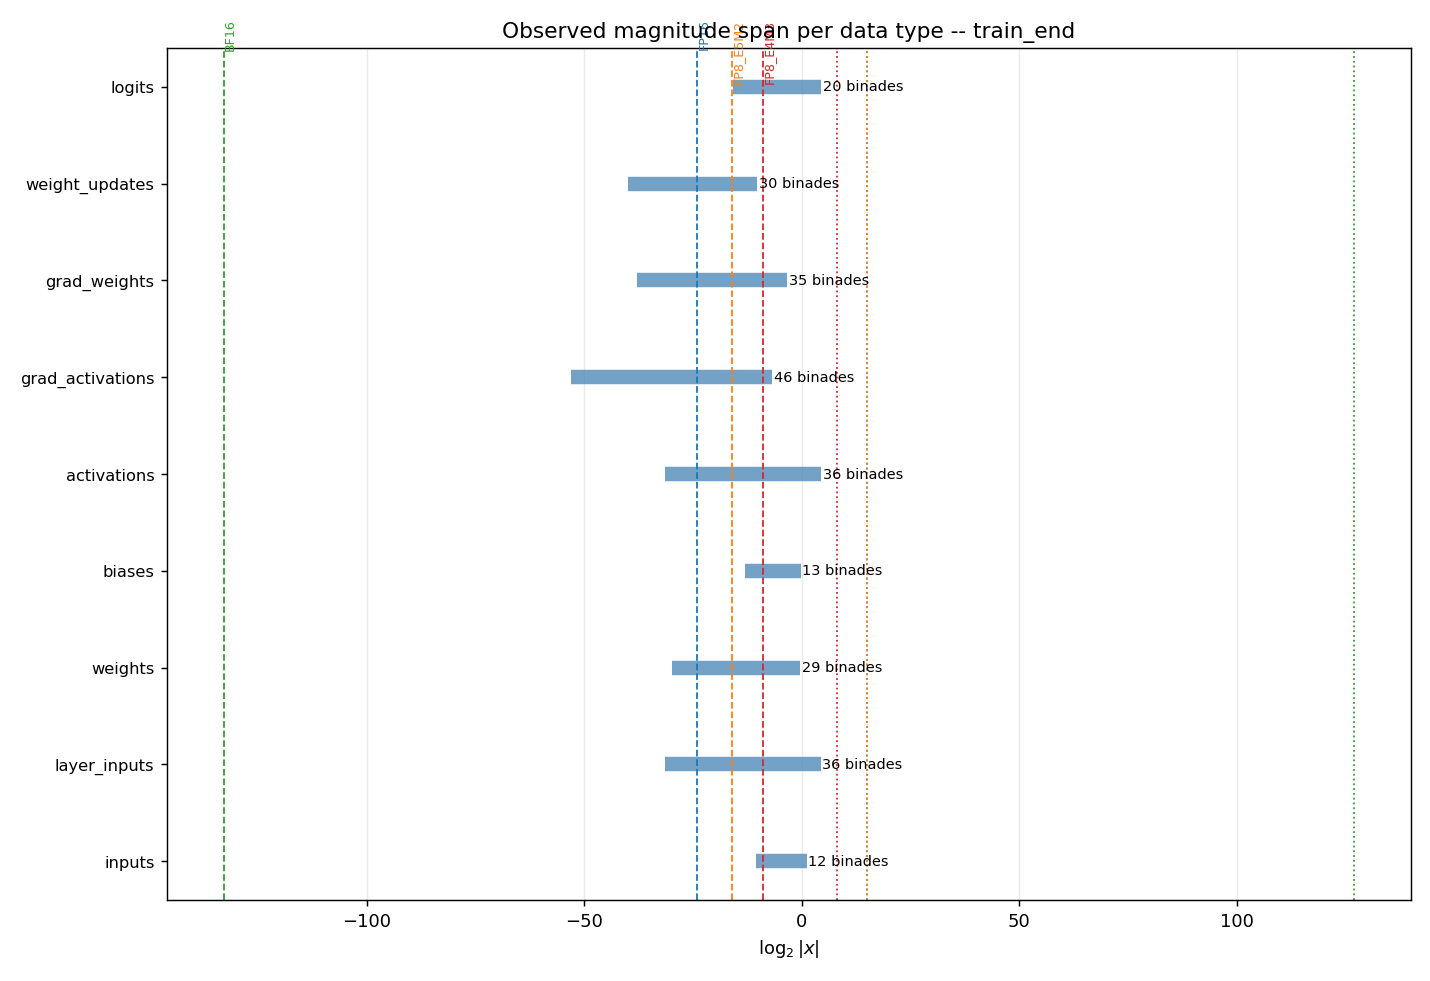


precision_analysis_results/figures/train_end/activations.png


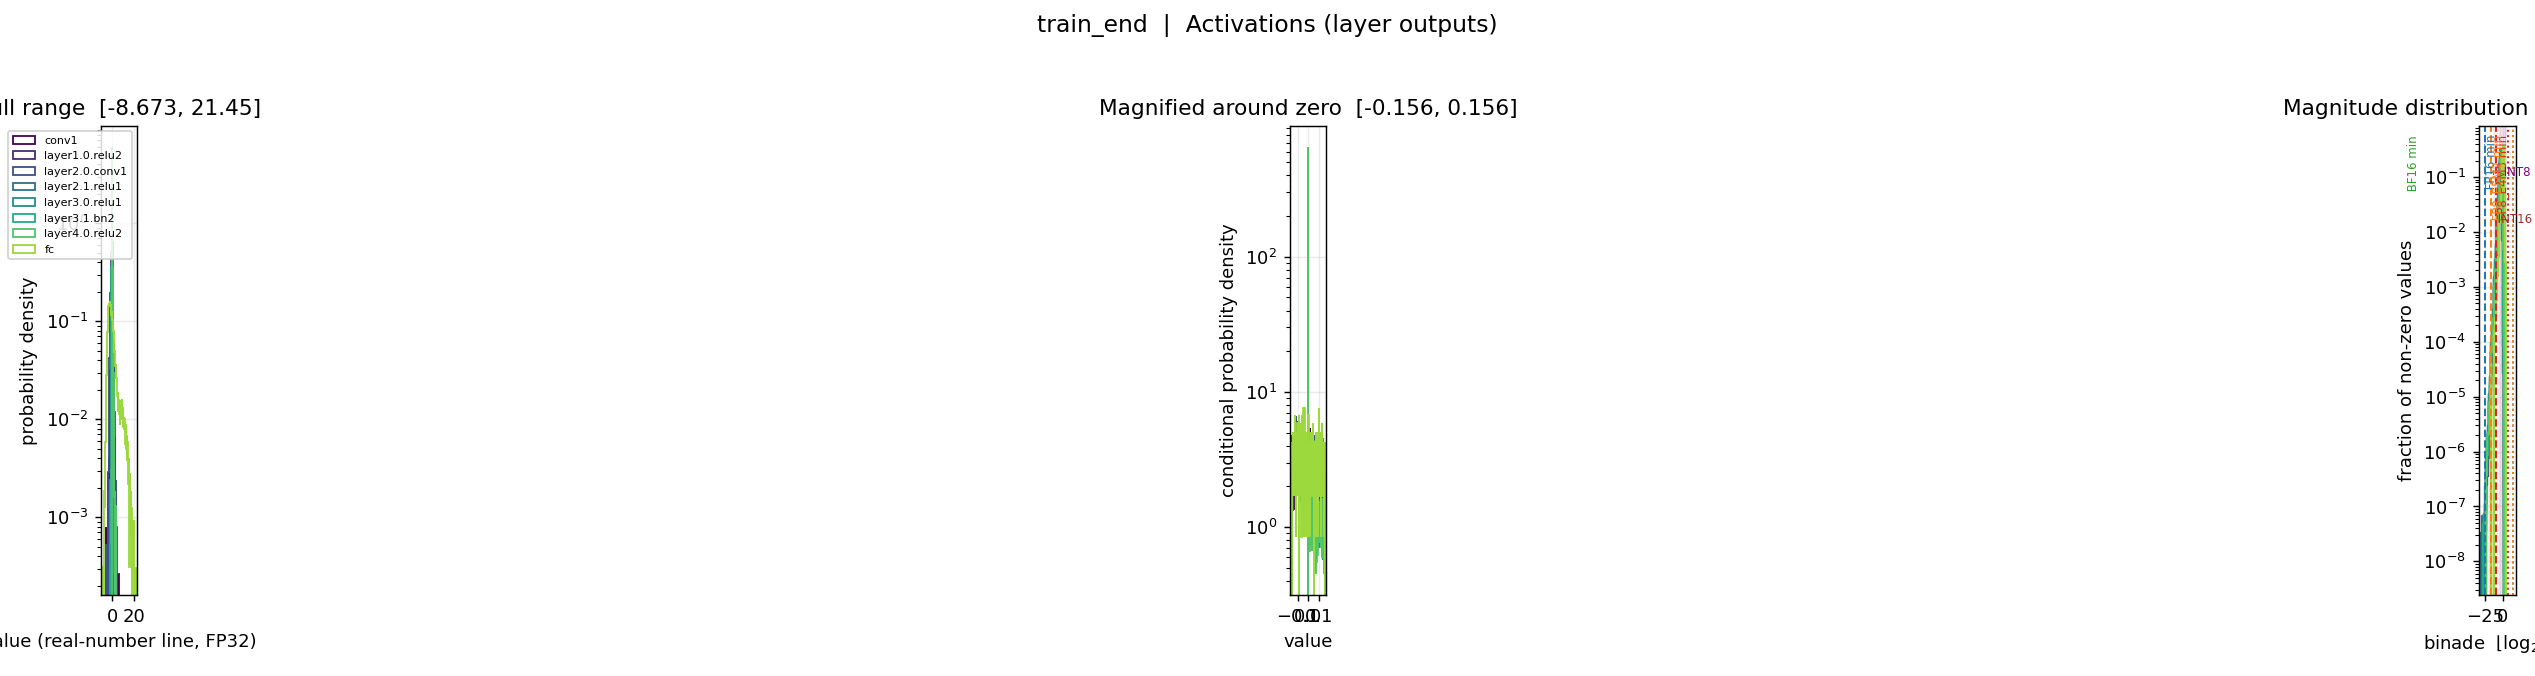


precision_analysis_results/figures/train_end/biases.png


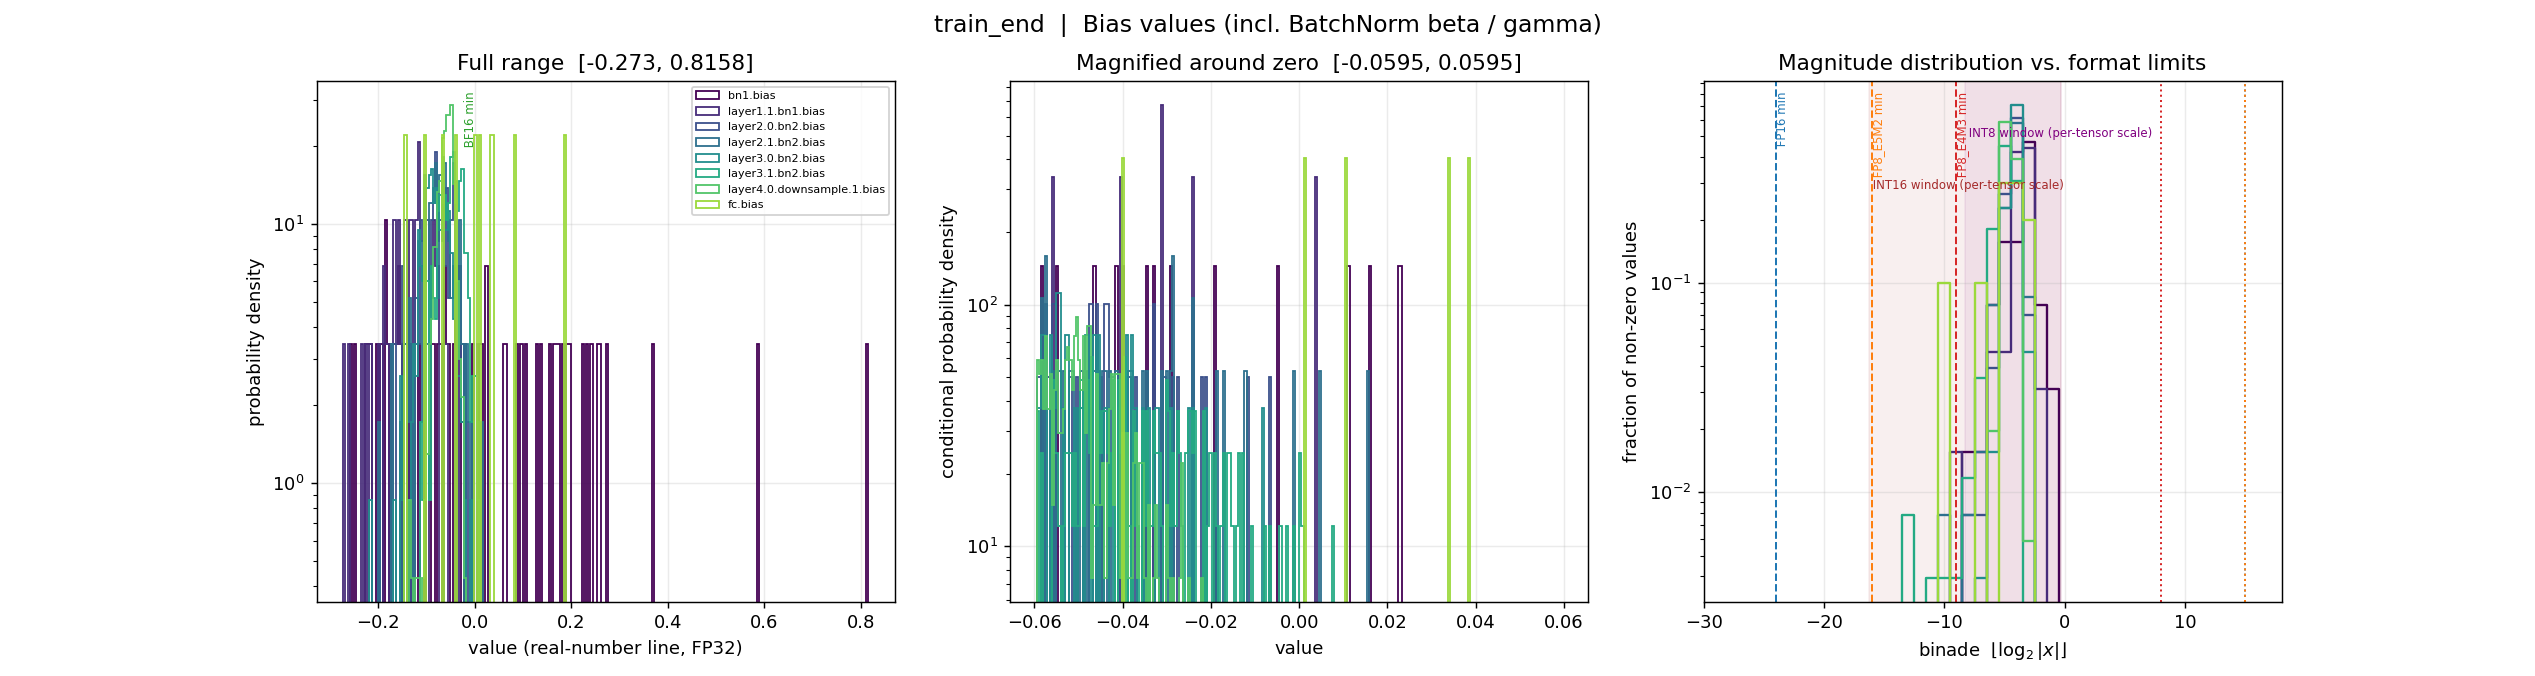


precision_analysis_results/figures/train_end/grad_activations.png


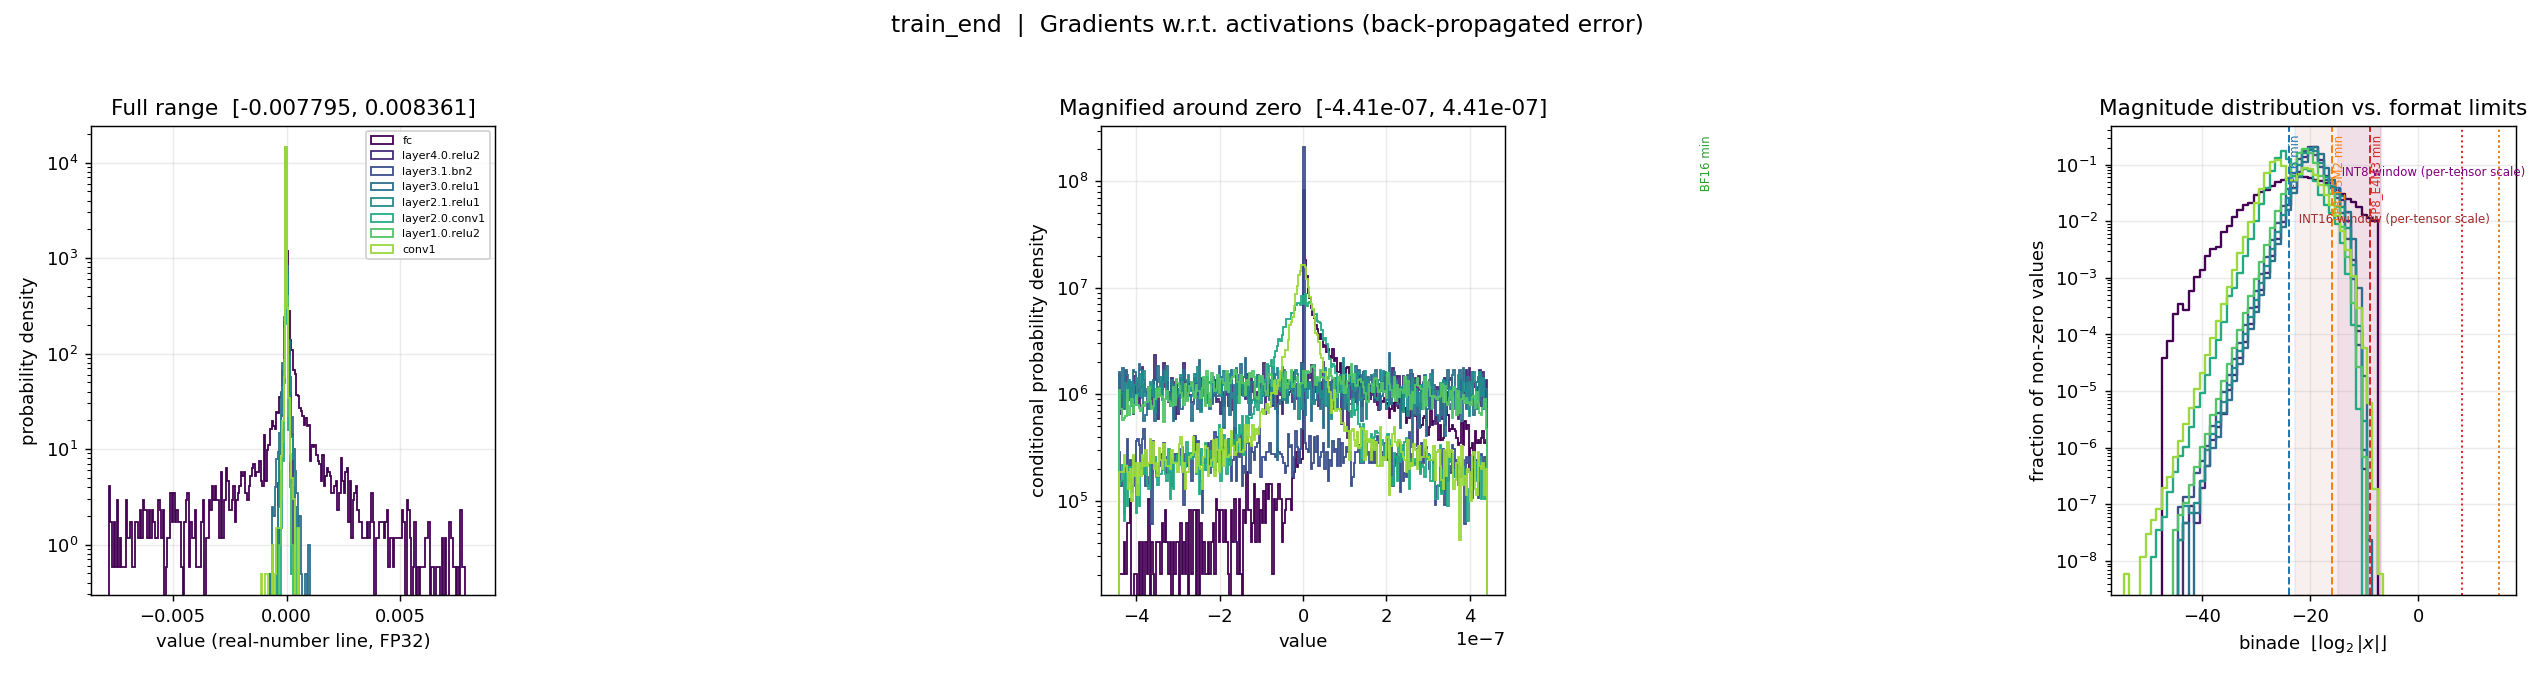


precision_analysis_results/figures/train_end/grad_weights.png


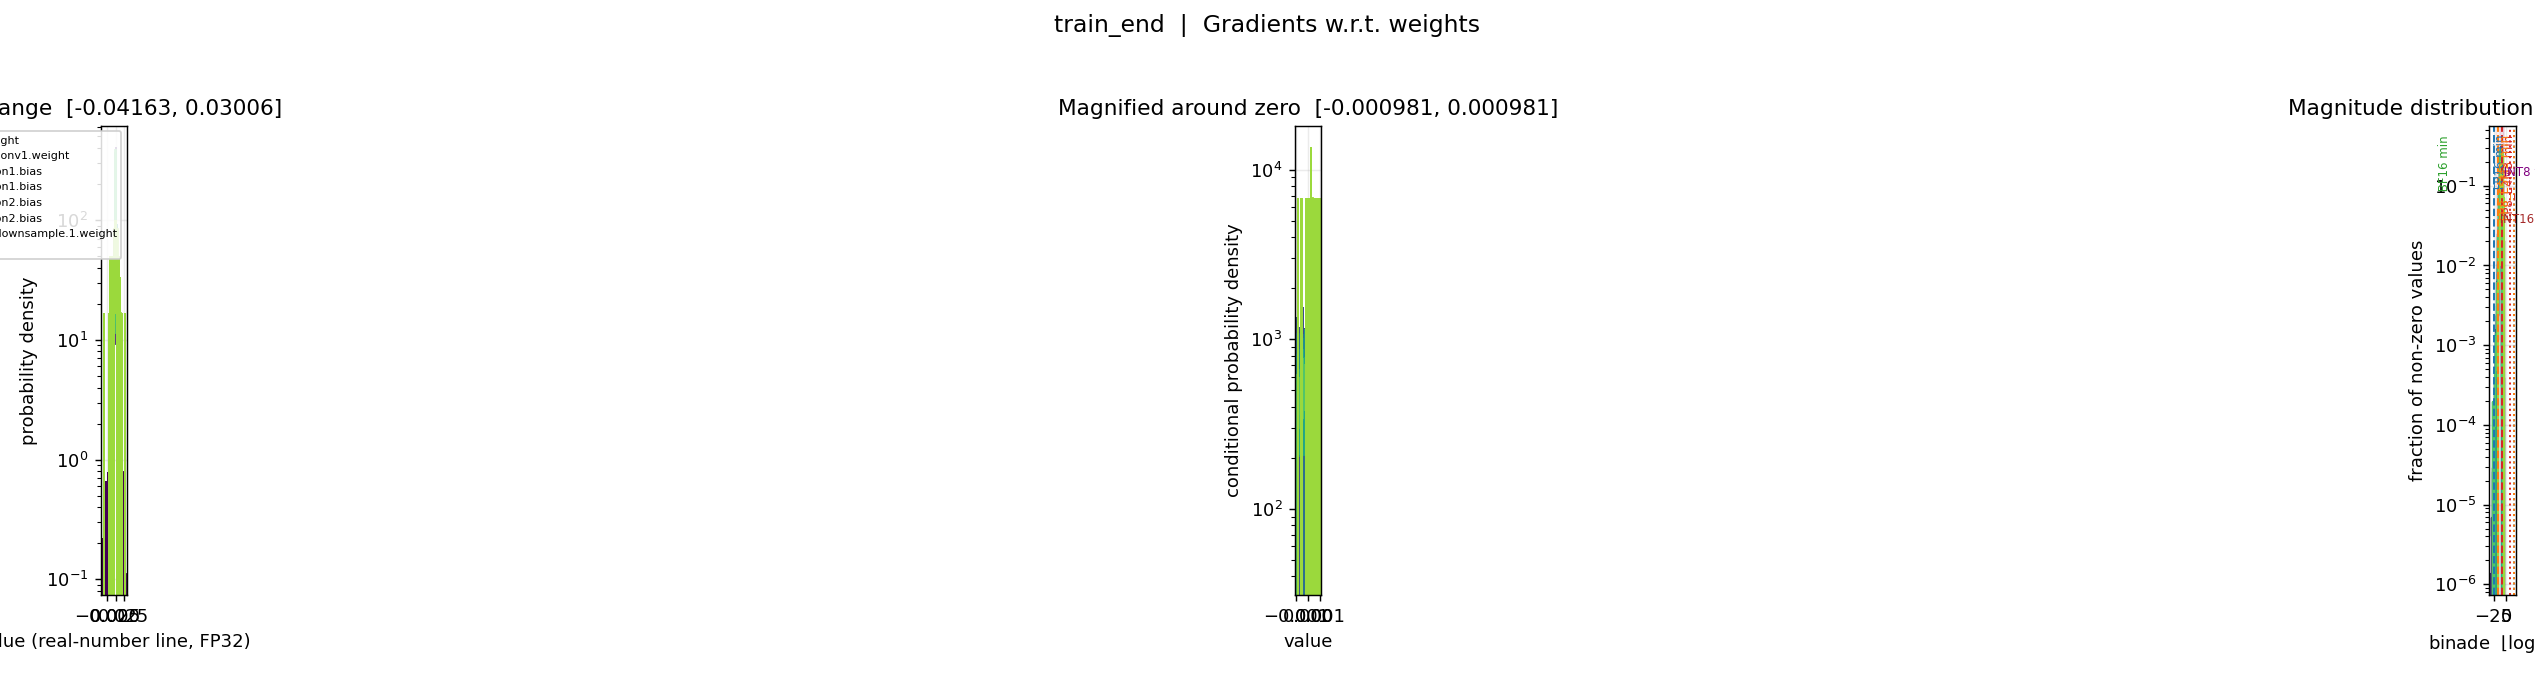


precision_analysis_results/figures/train_end/inputs.png


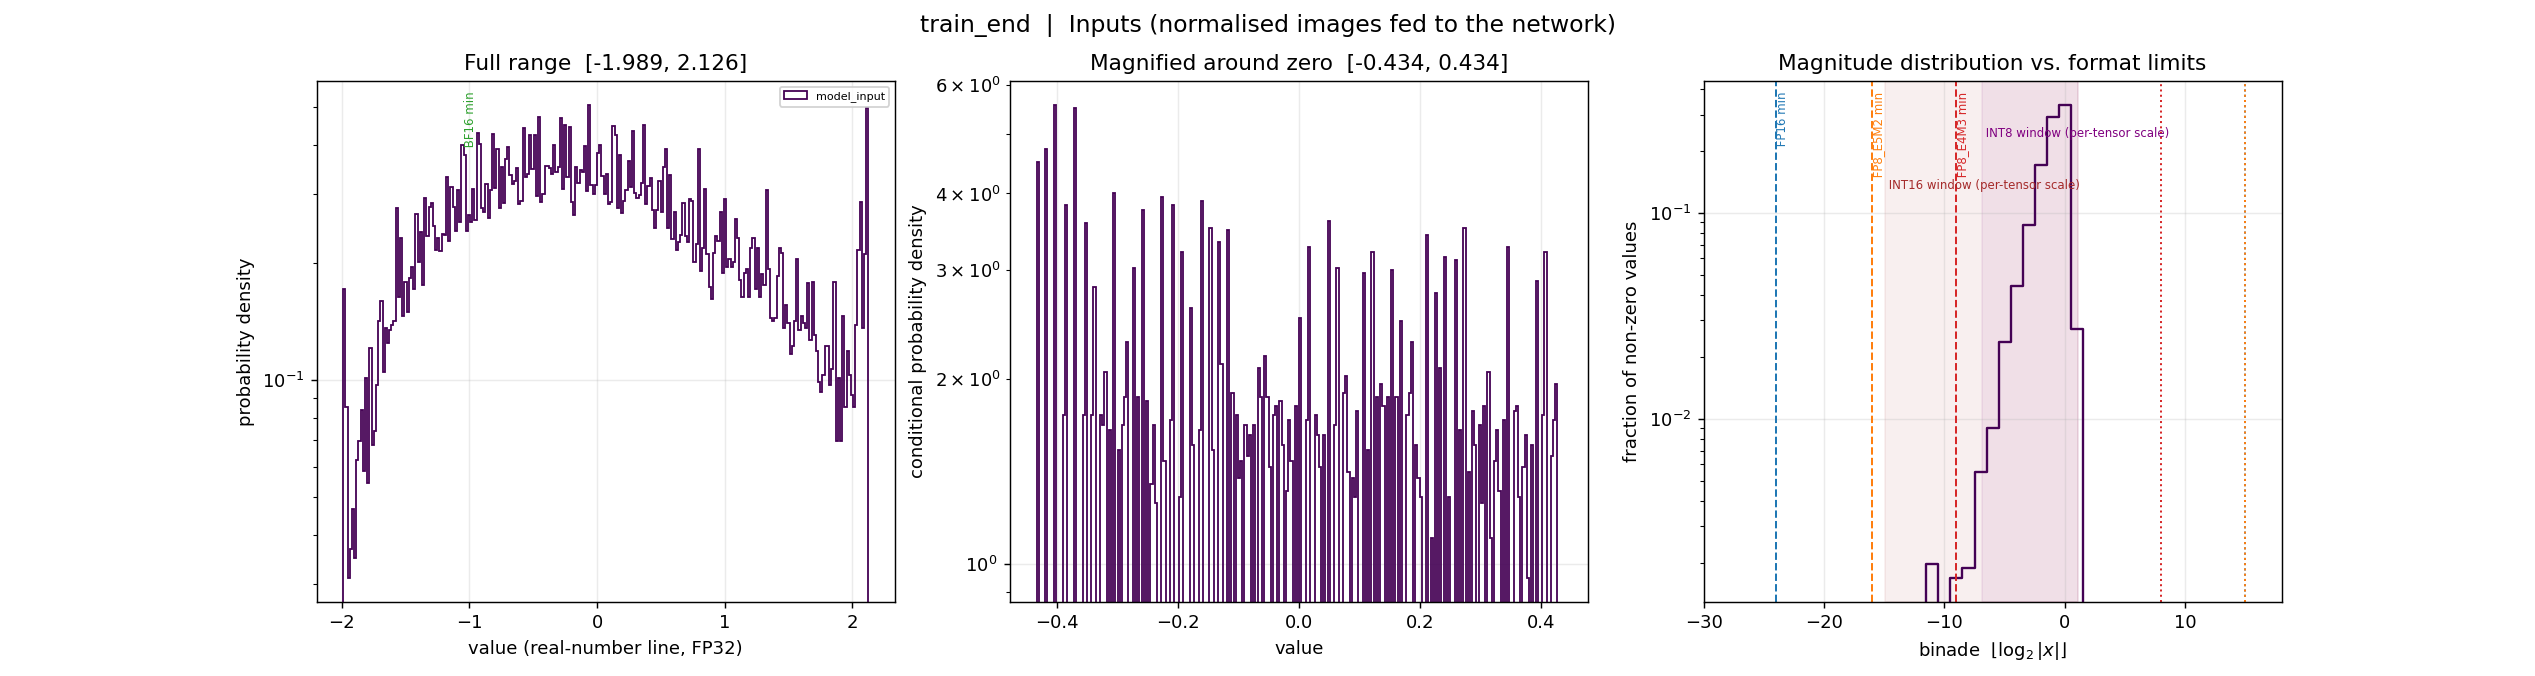


precision_analysis_results/figures/train_end/layer_inputs.png


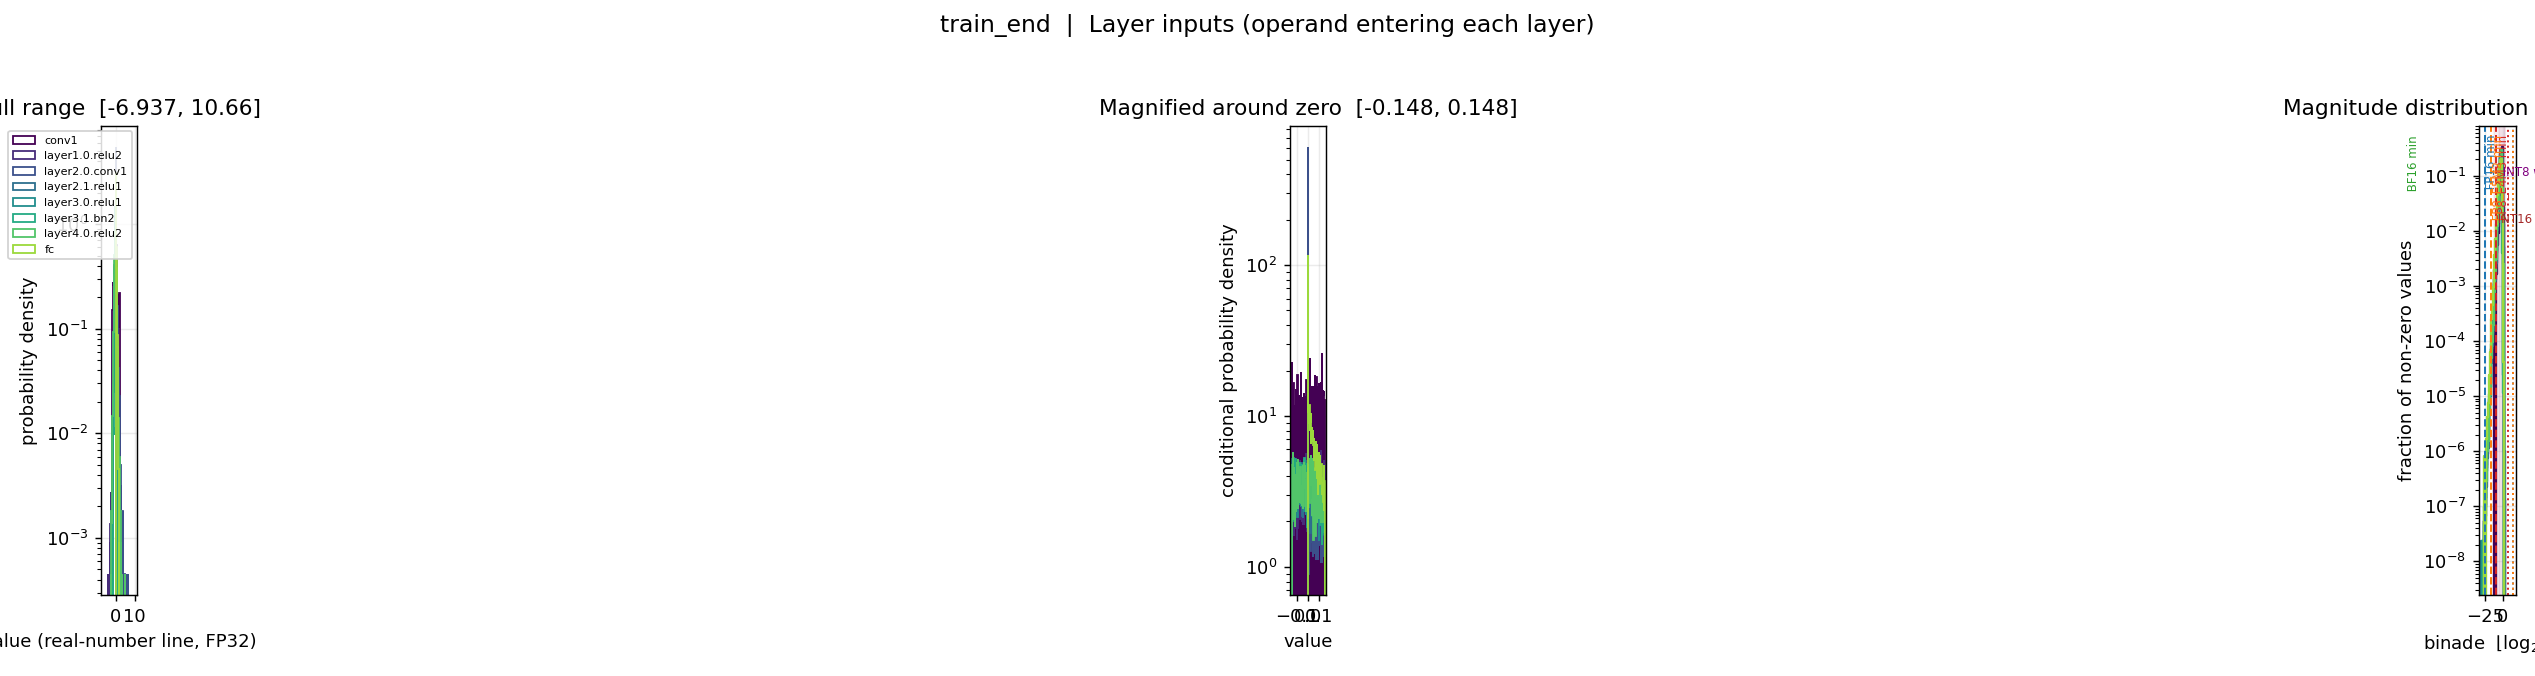


precision_analysis_results/figures/train_end/logits.png


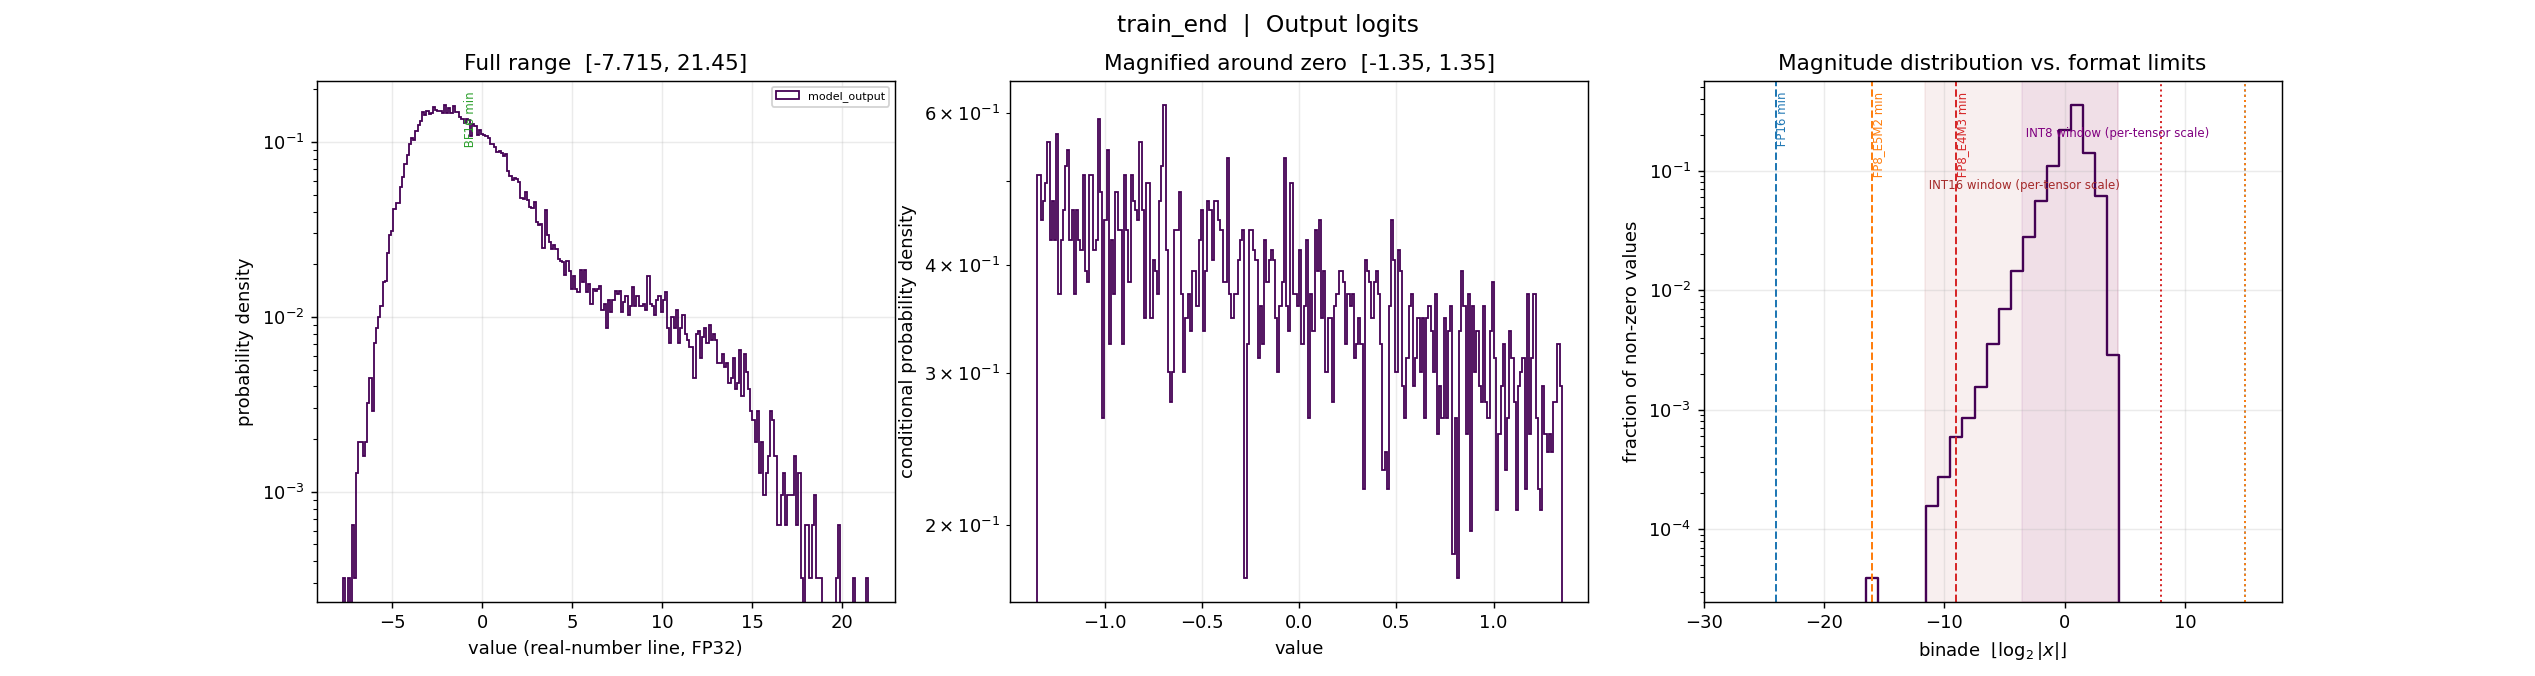


precision_analysis_results/figures/train_end/weight_updates.png


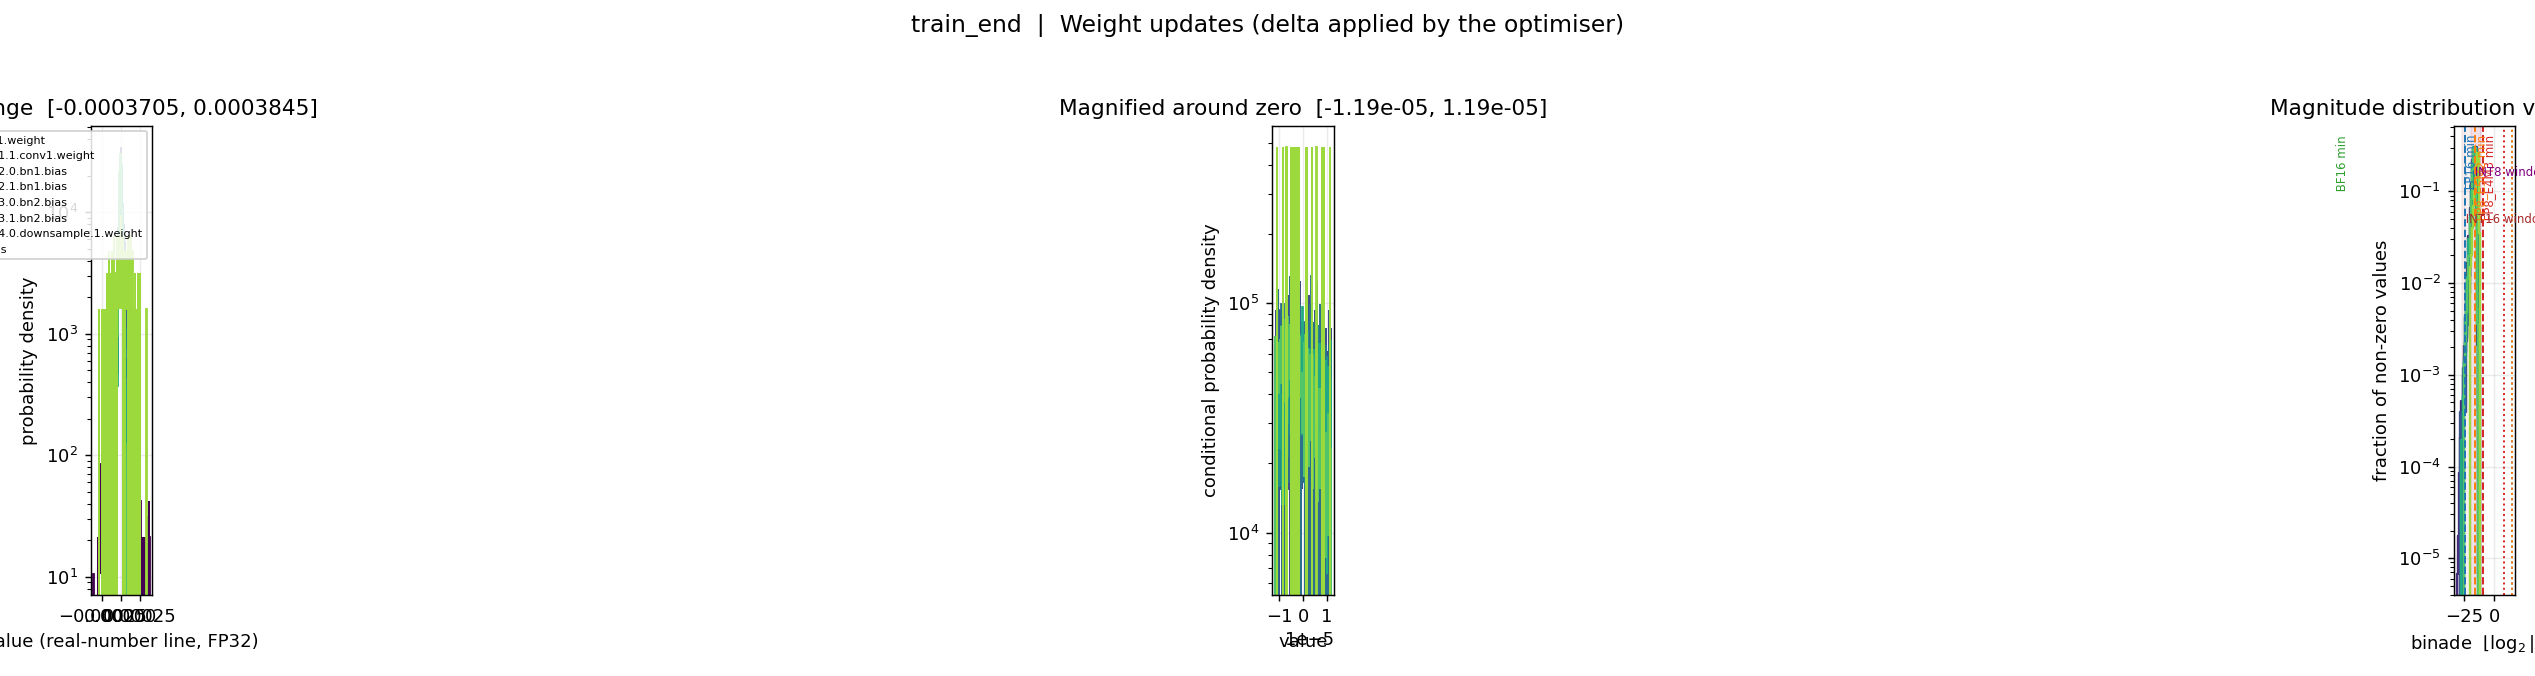


precision_analysis_results/figures/train_end/weights.png


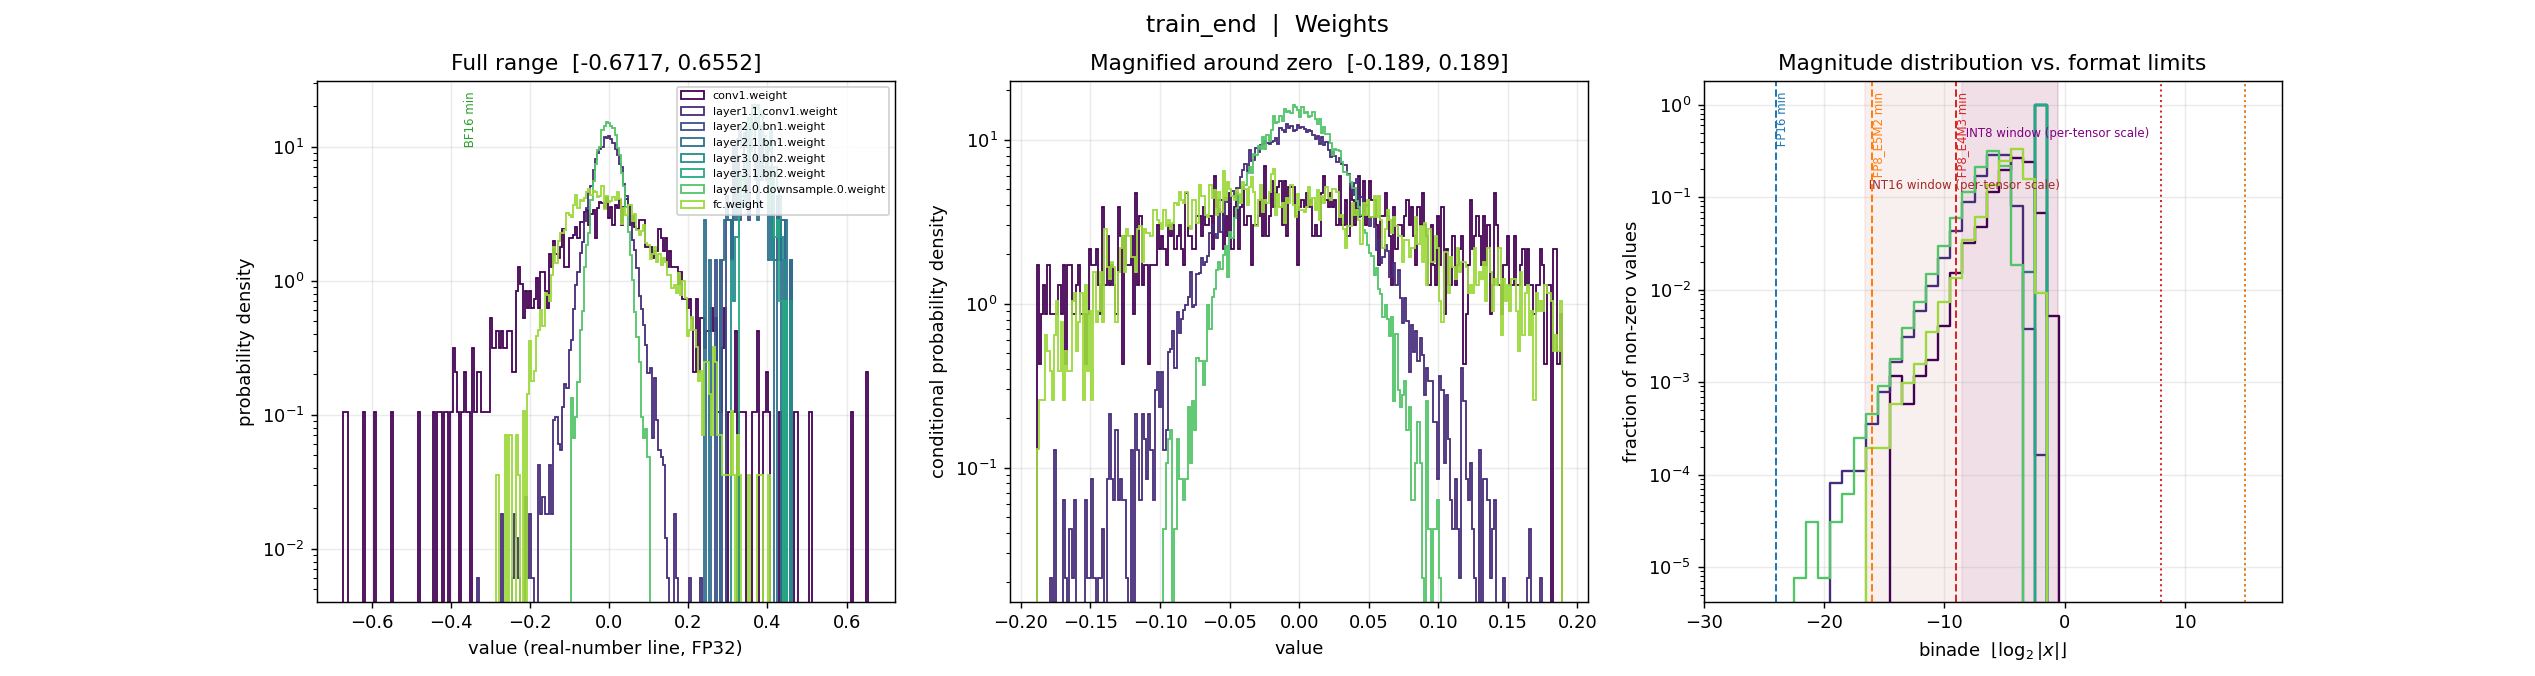


precision_analysis_results/figures/train_middle/_range_overview.png


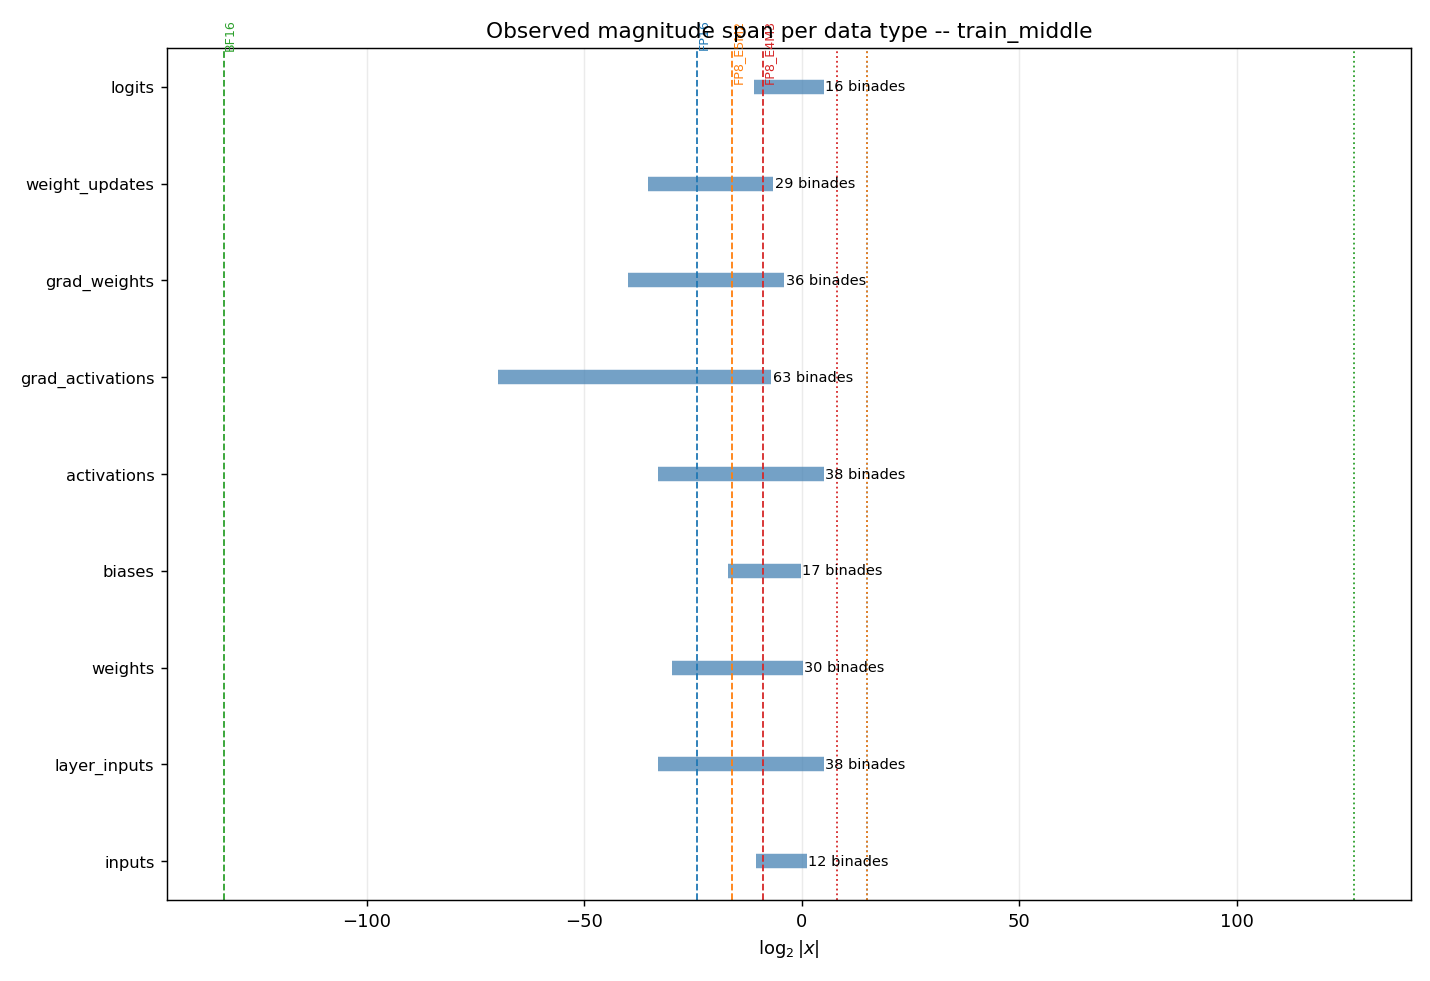


precision_analysis_results/figures/train_middle/activations.png


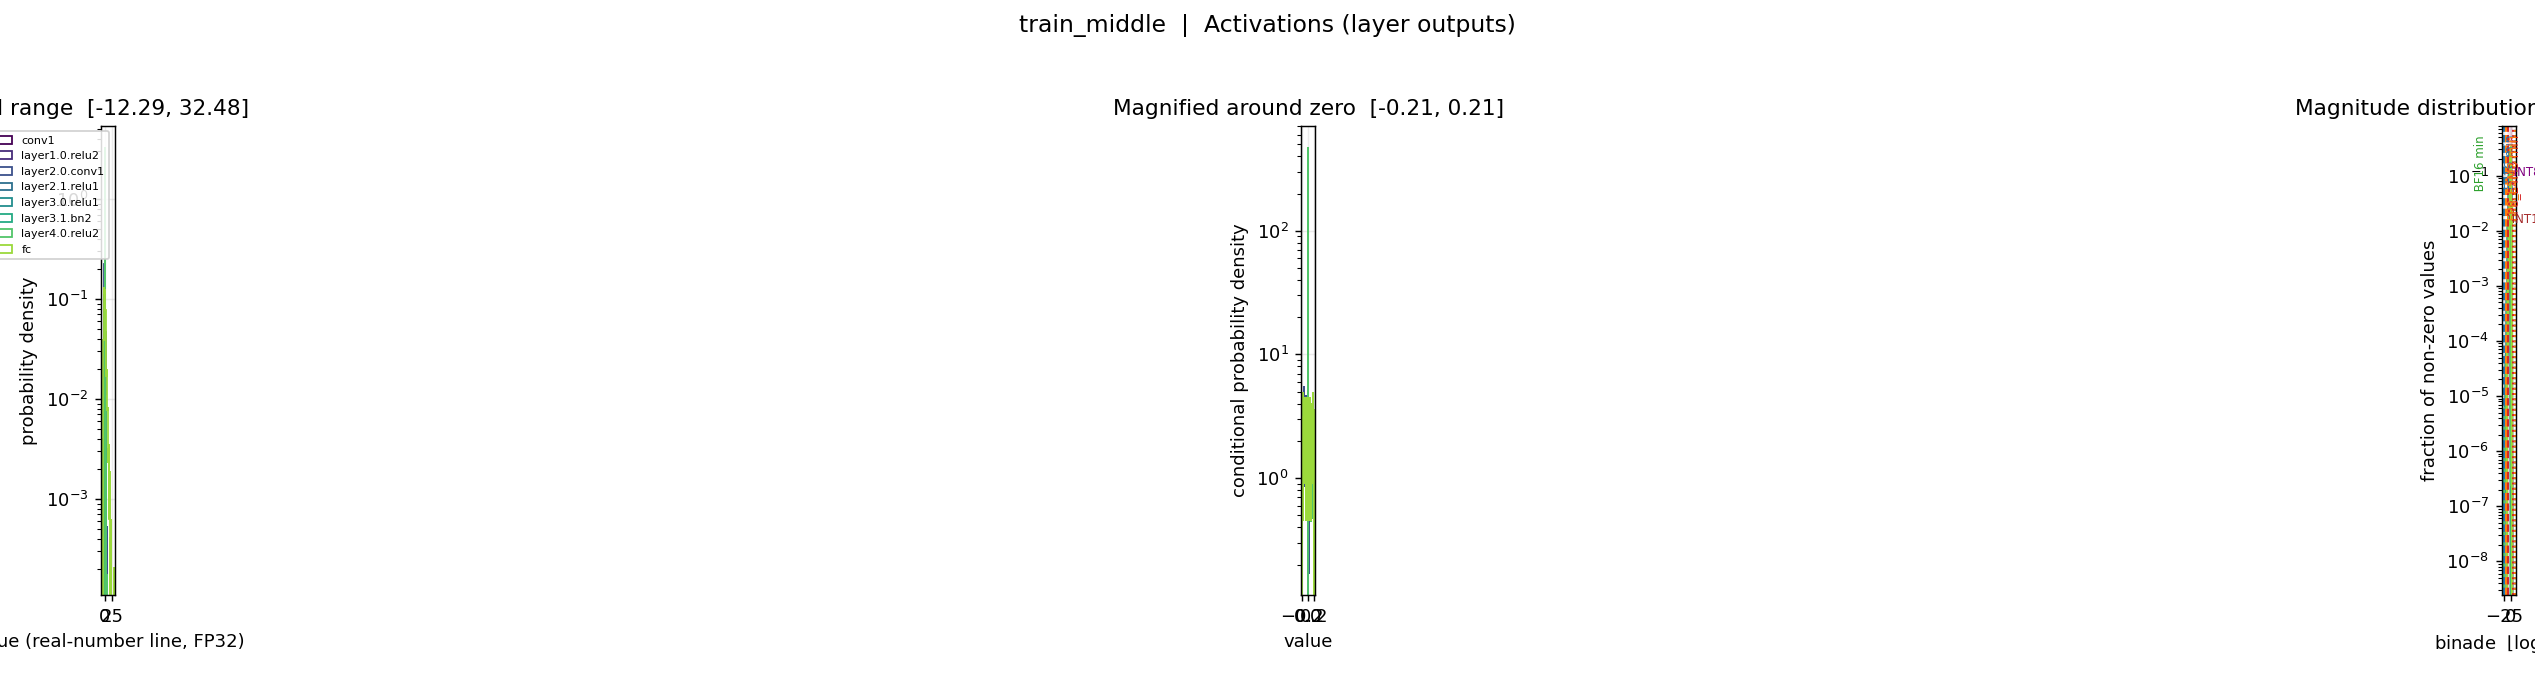


precision_analysis_results/figures/train_middle/biases.png


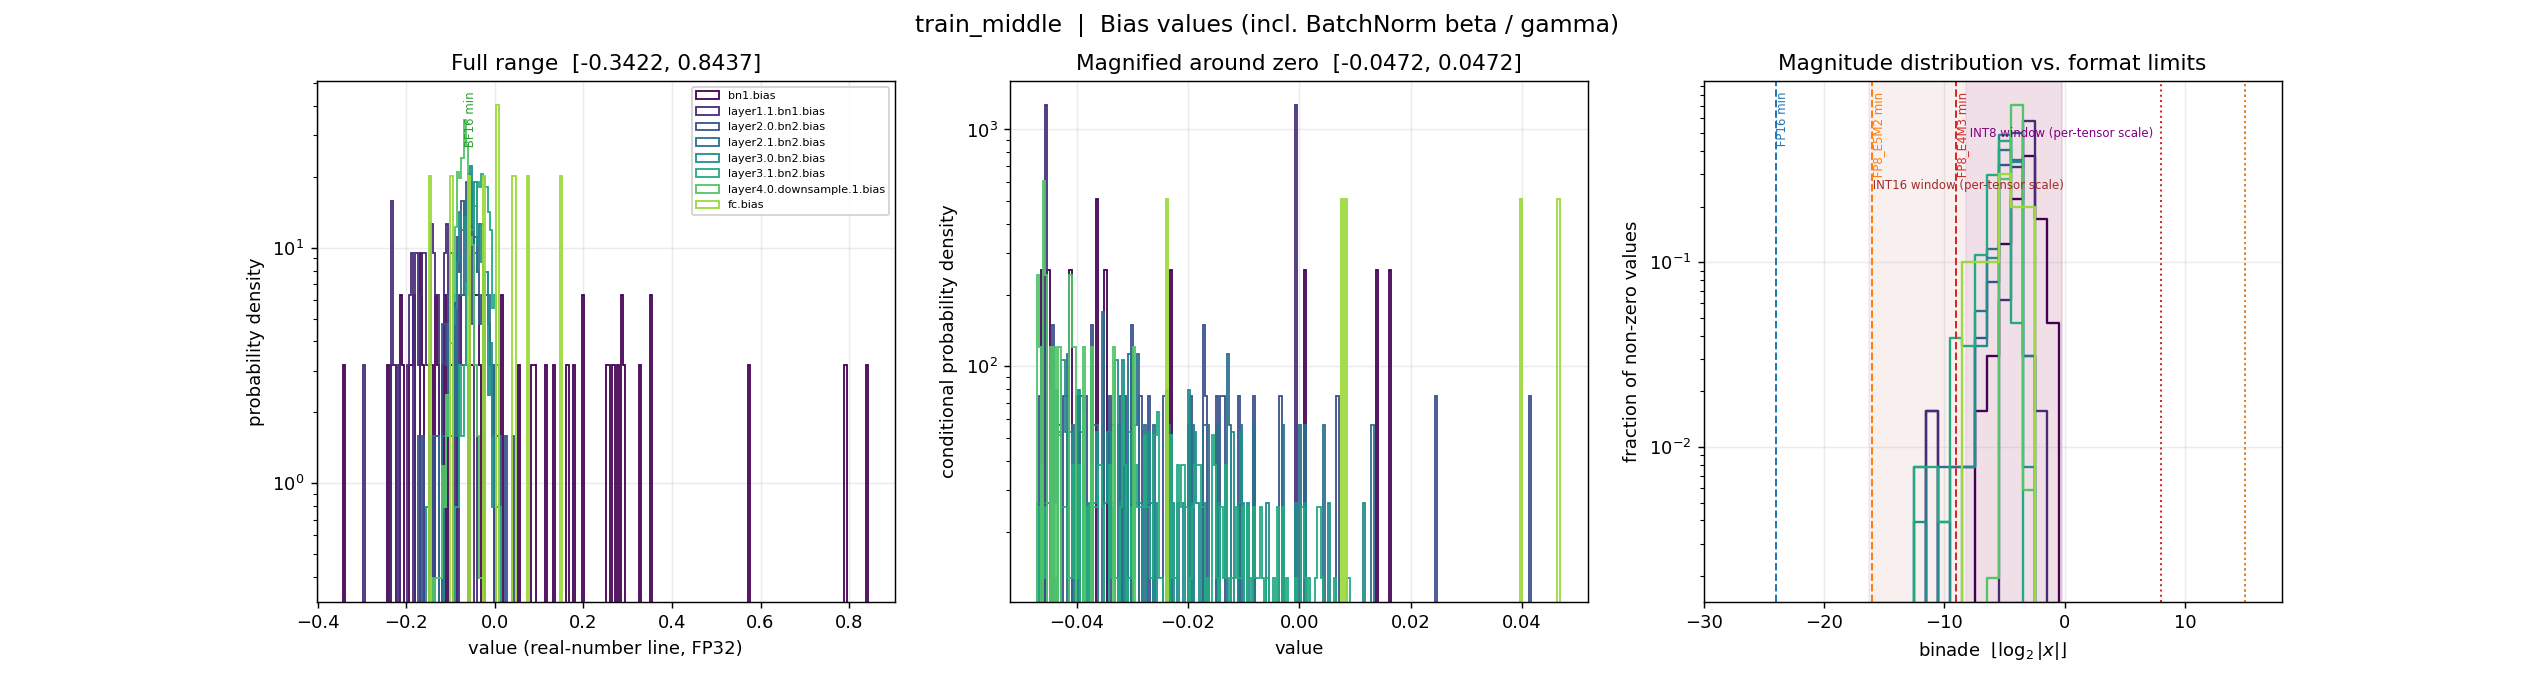


precision_analysis_results/figures/train_middle/grad_activations.png


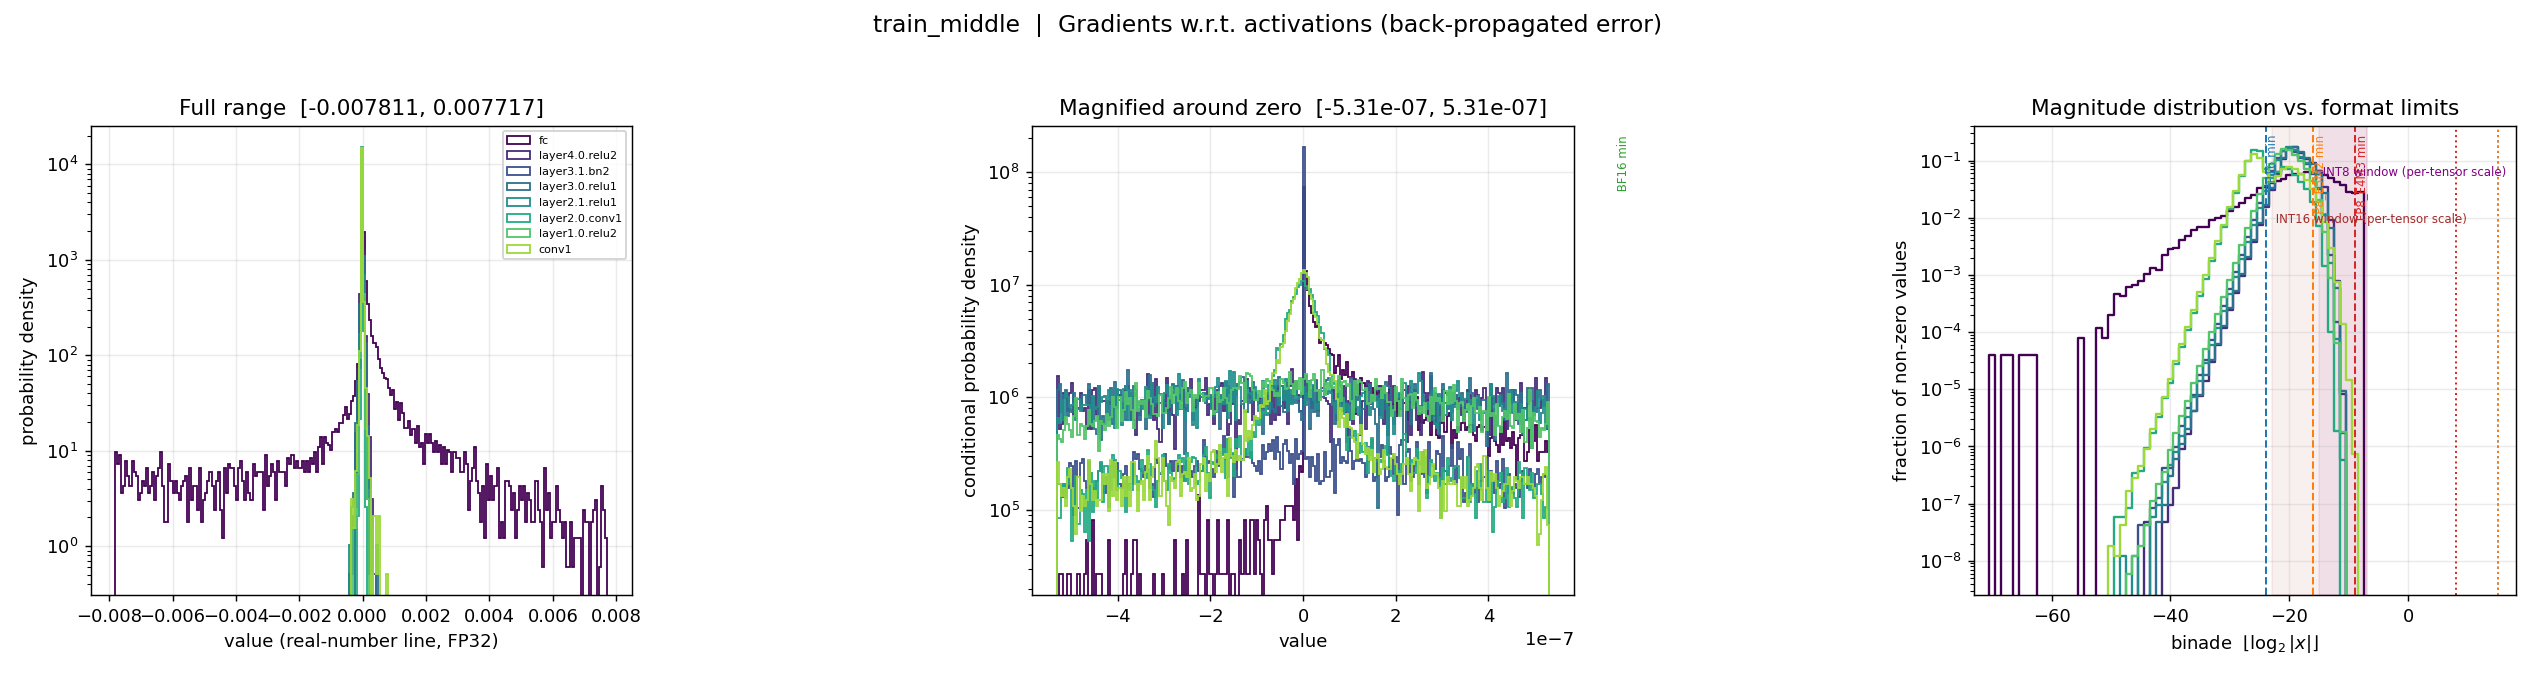


precision_analysis_results/figures/train_middle/grad_weights.png


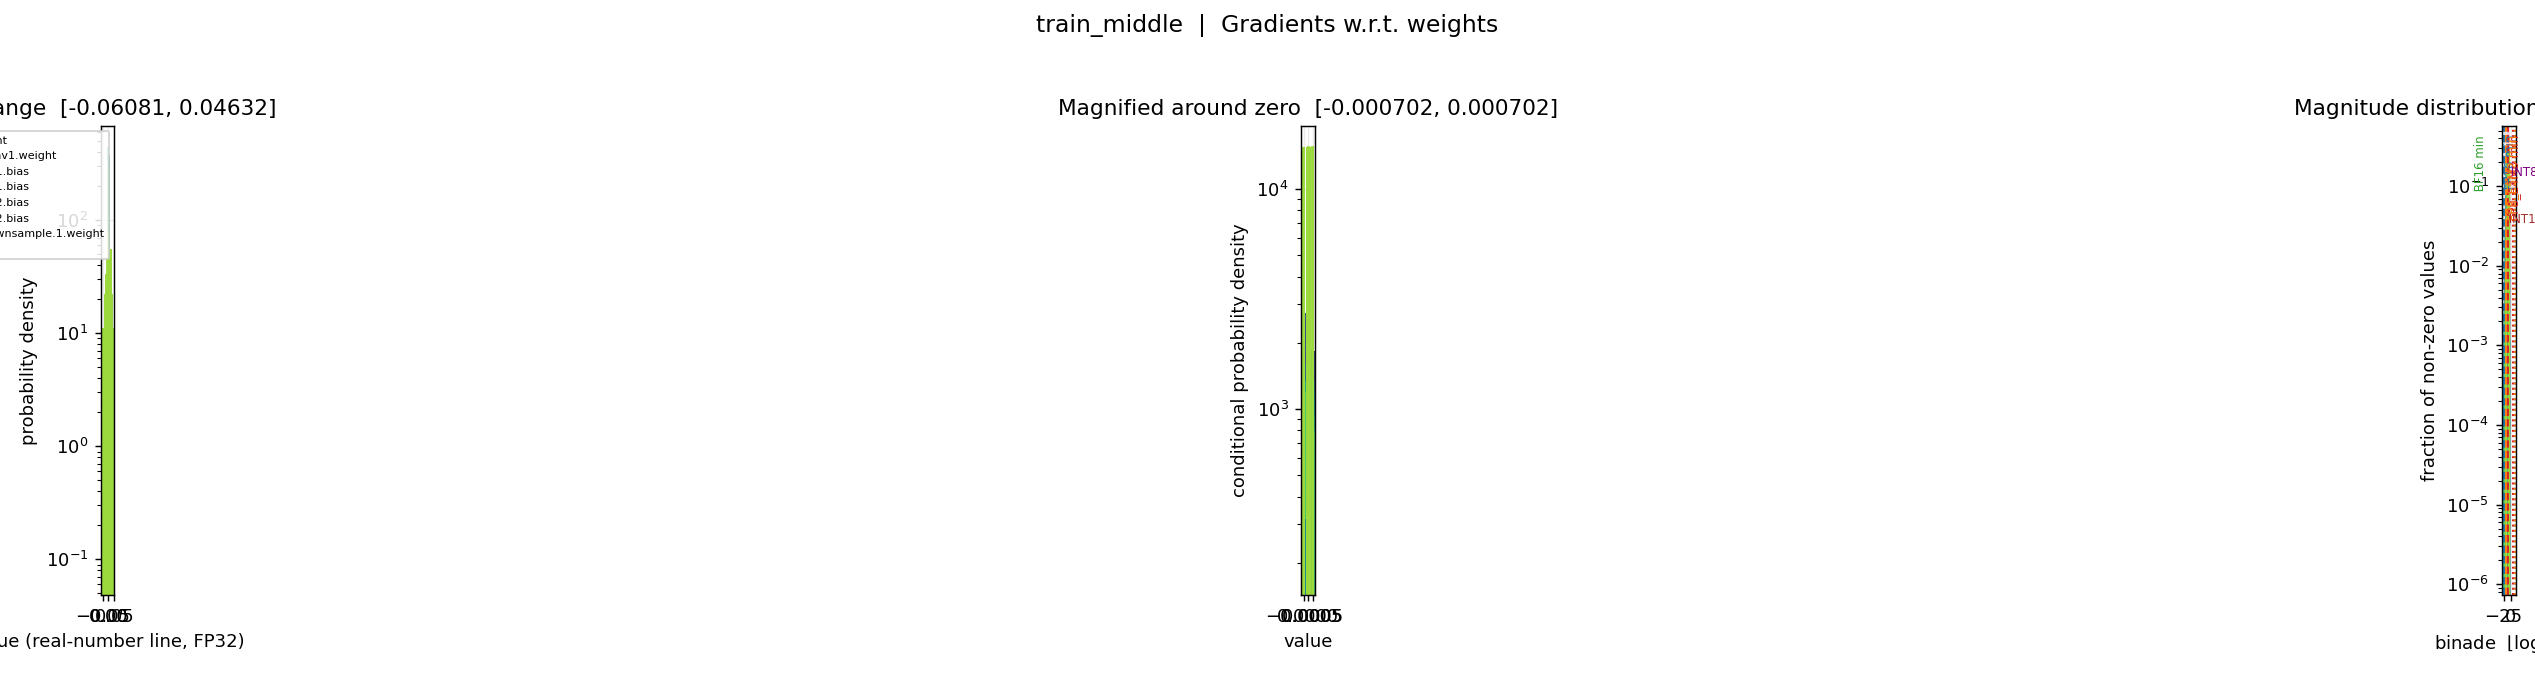


precision_analysis_results/figures/train_middle/inputs.png


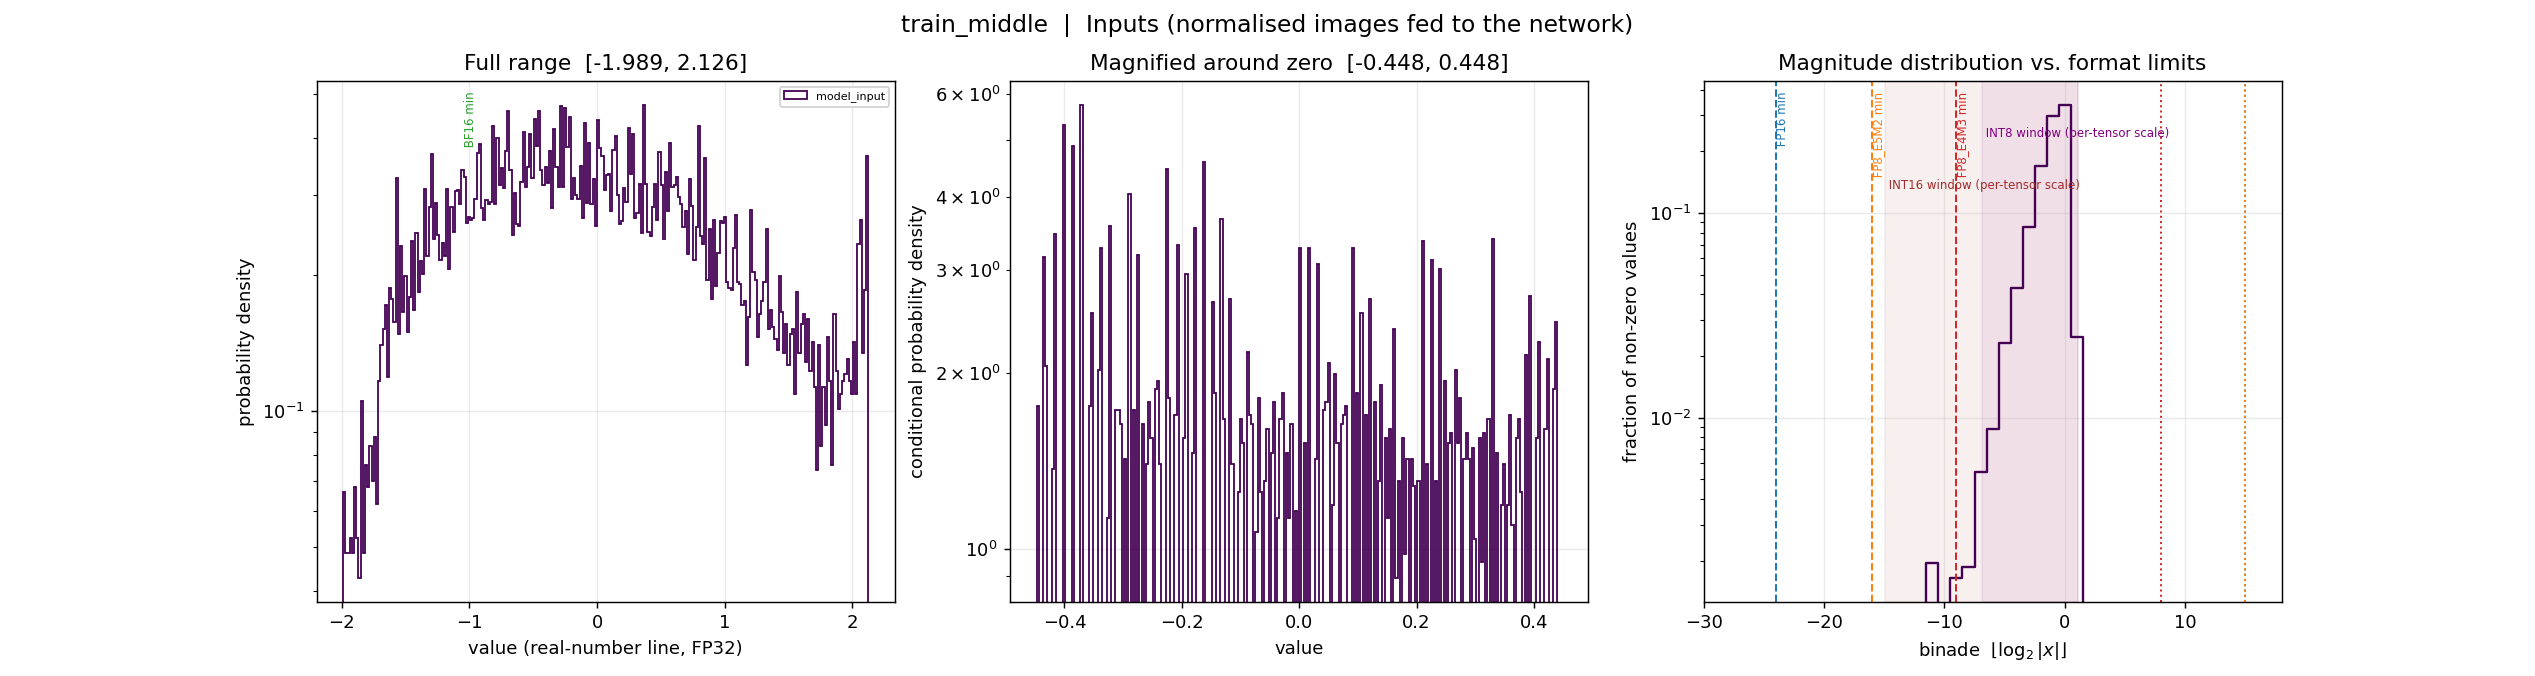


precision_analysis_results/figures/train_middle/layer_inputs.png


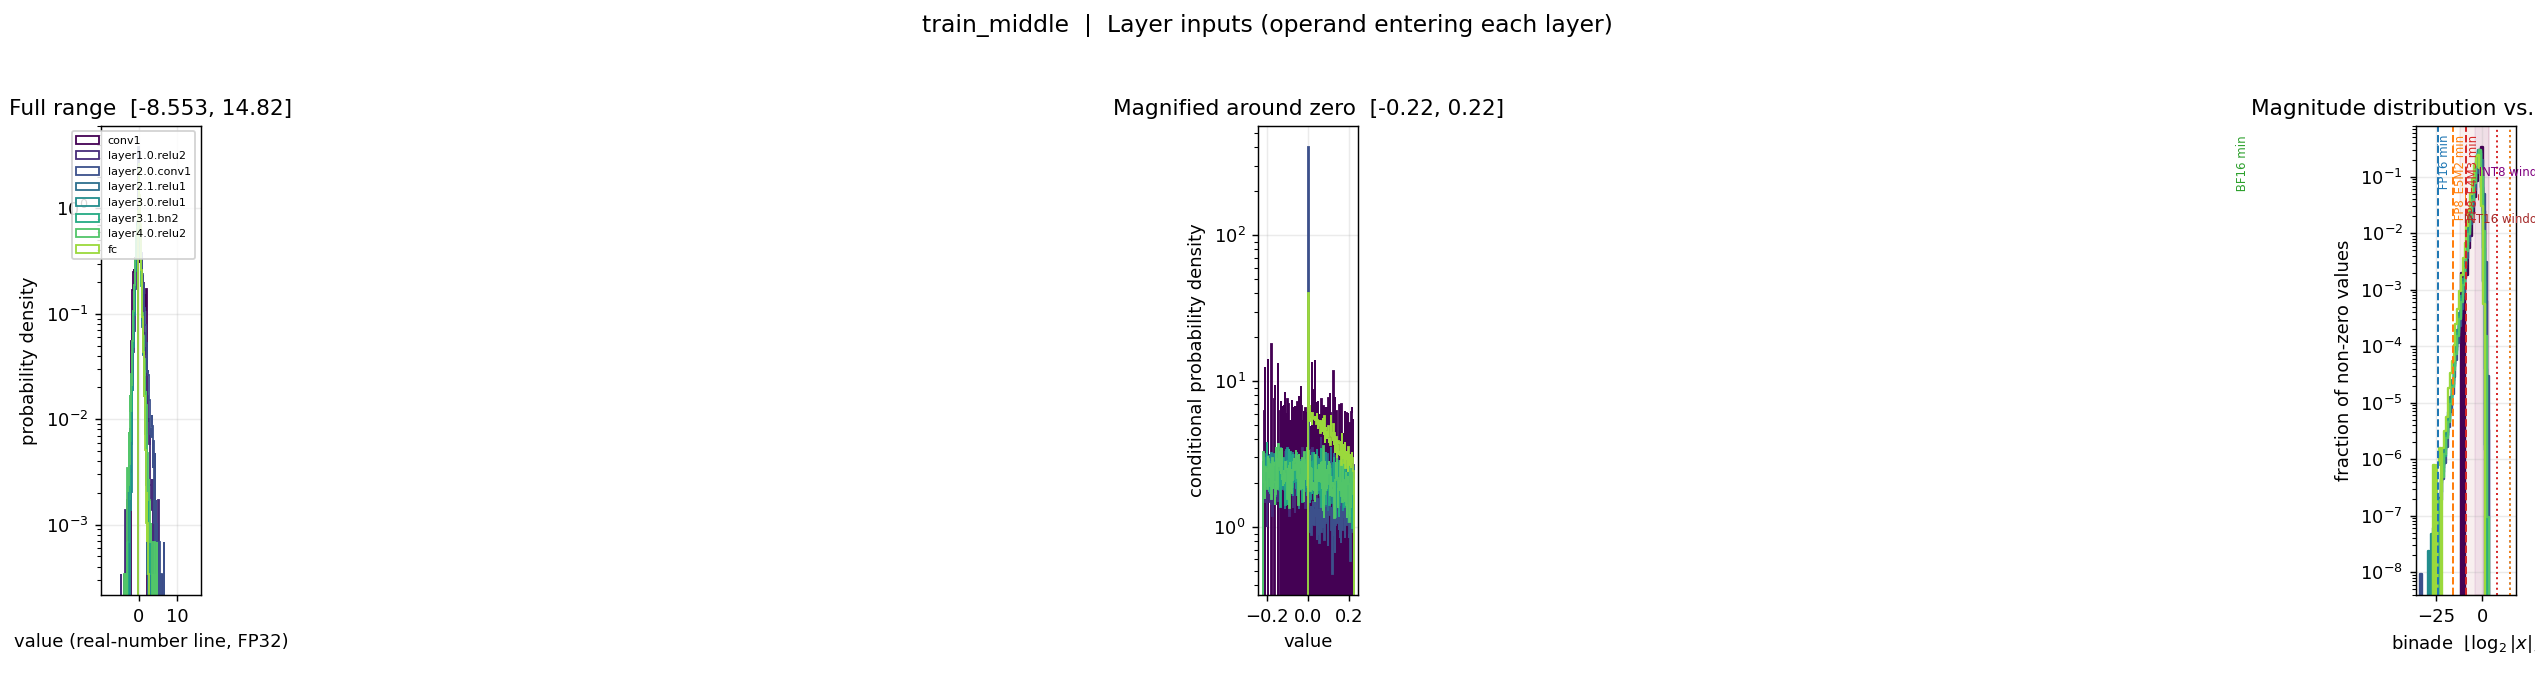


precision_analysis_results/figures/train_middle/logits.png


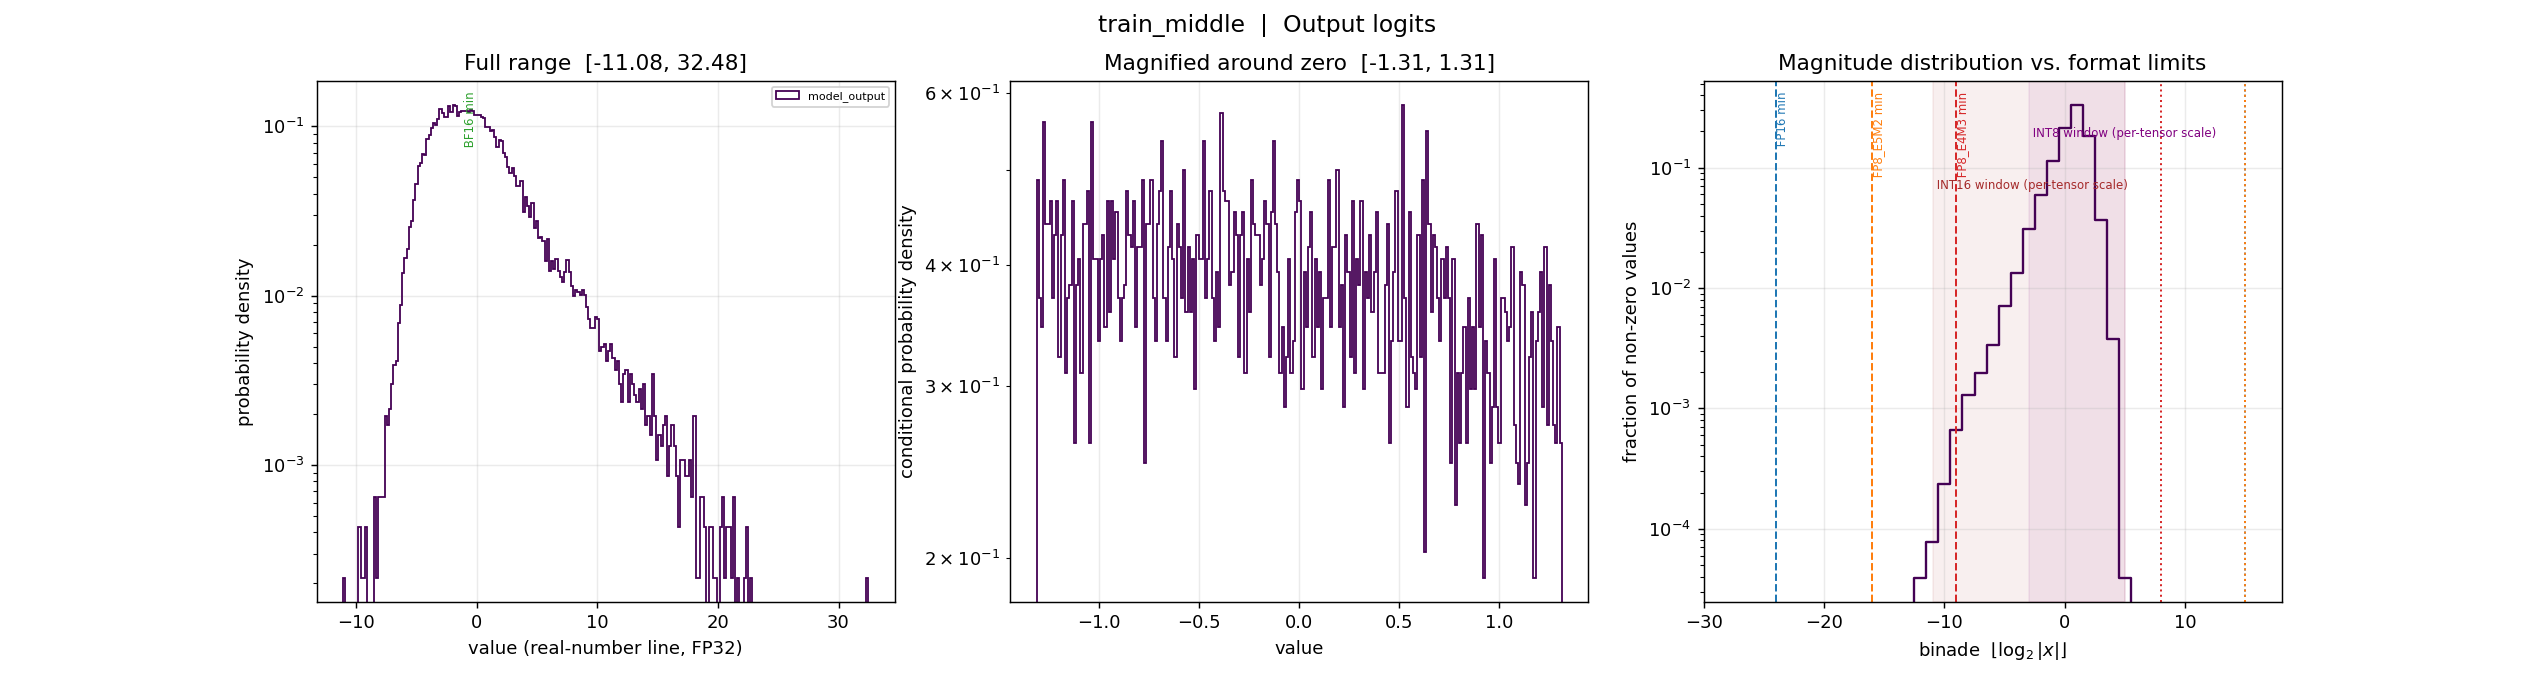


precision_analysis_results/figures/train_middle/weight_updates.png


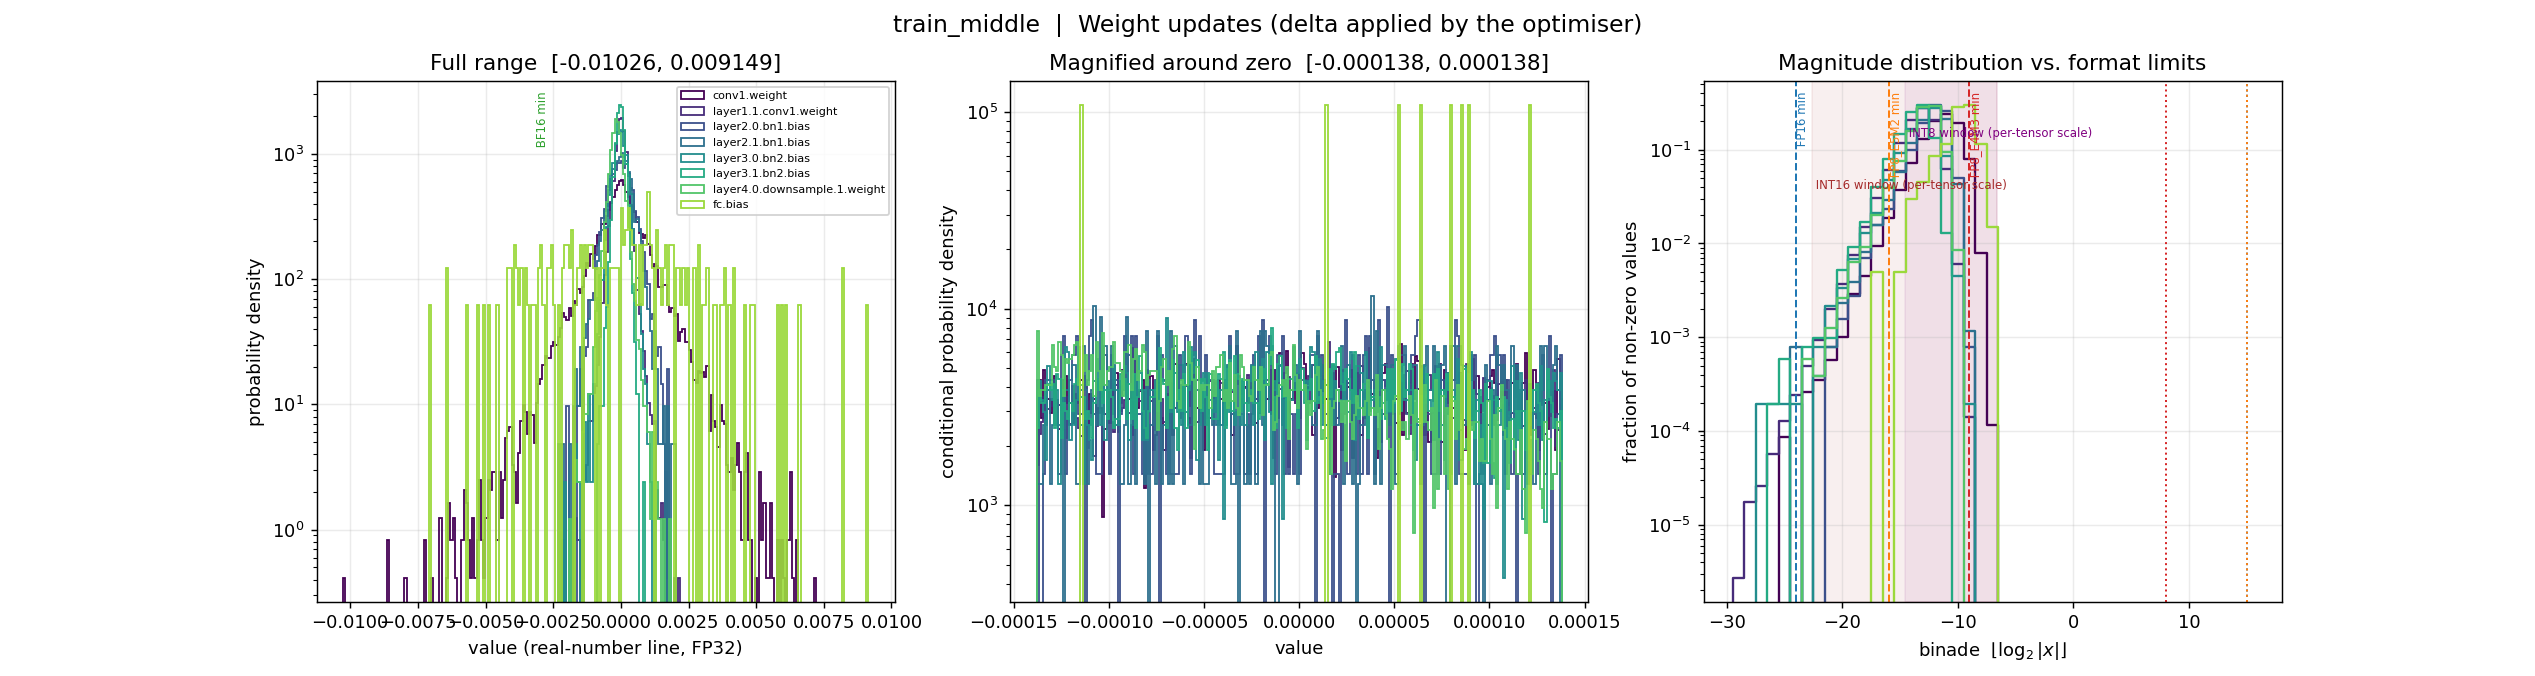


precision_analysis_results/figures/train_middle/weights.png


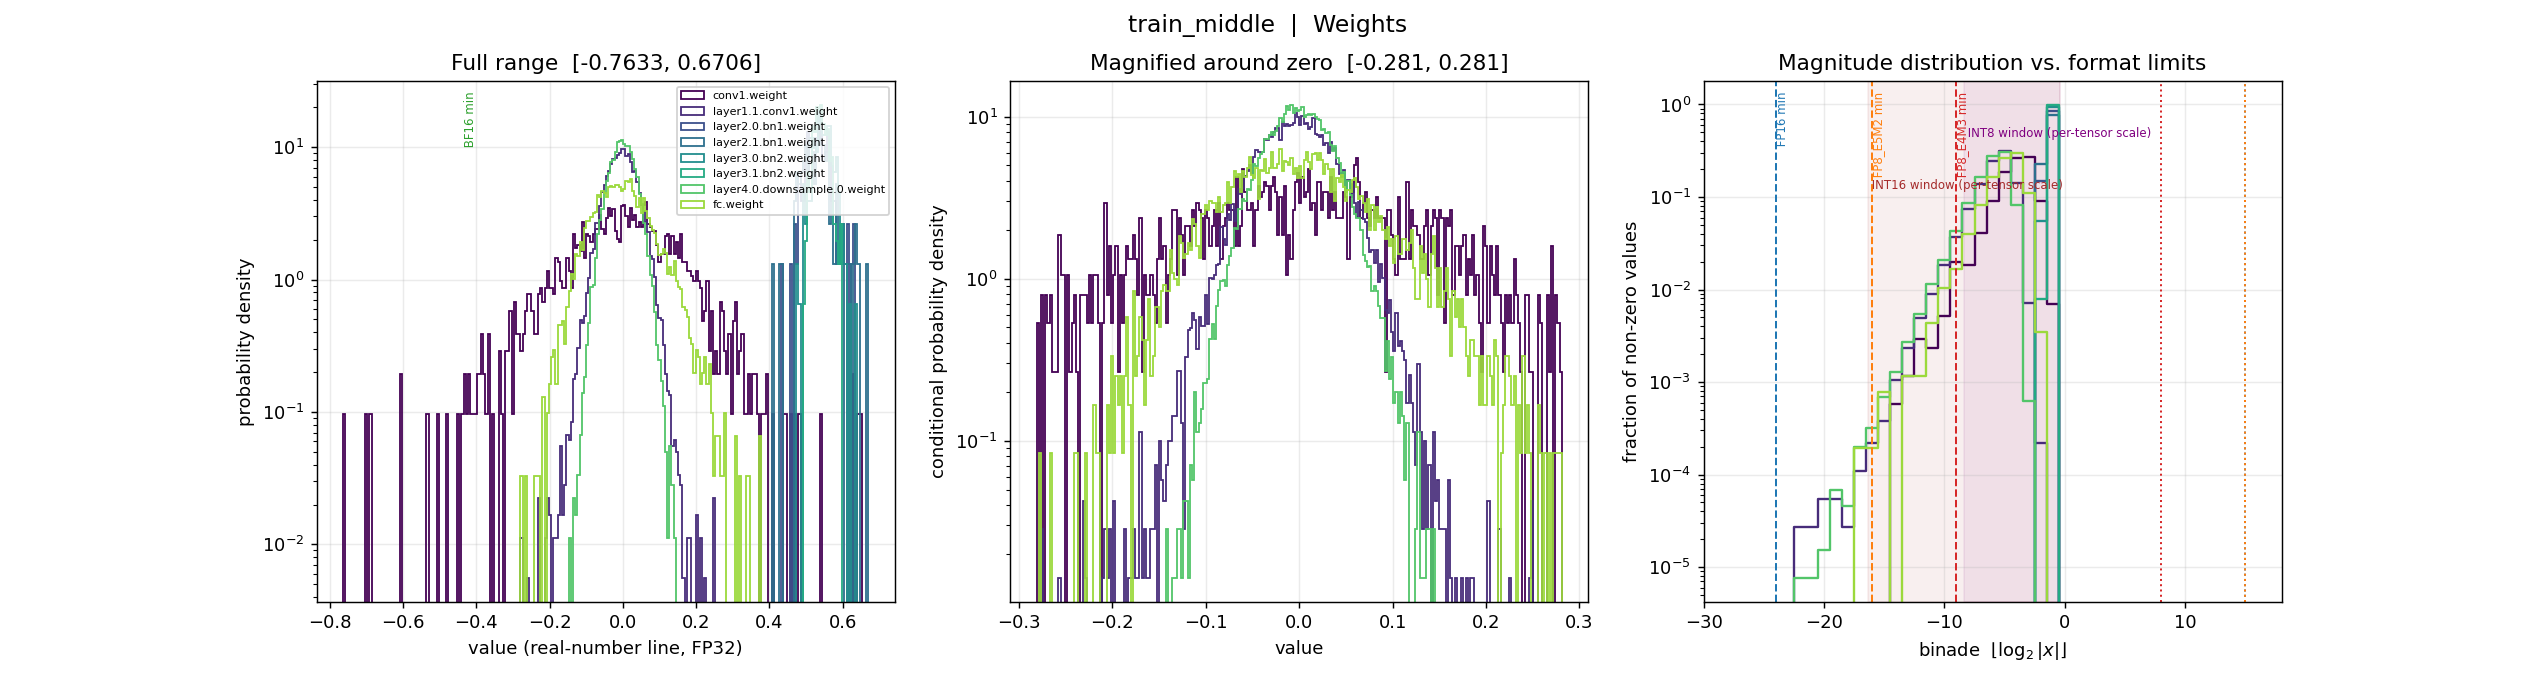


precision_analysis_results/figures/train_start/_range_overview.png


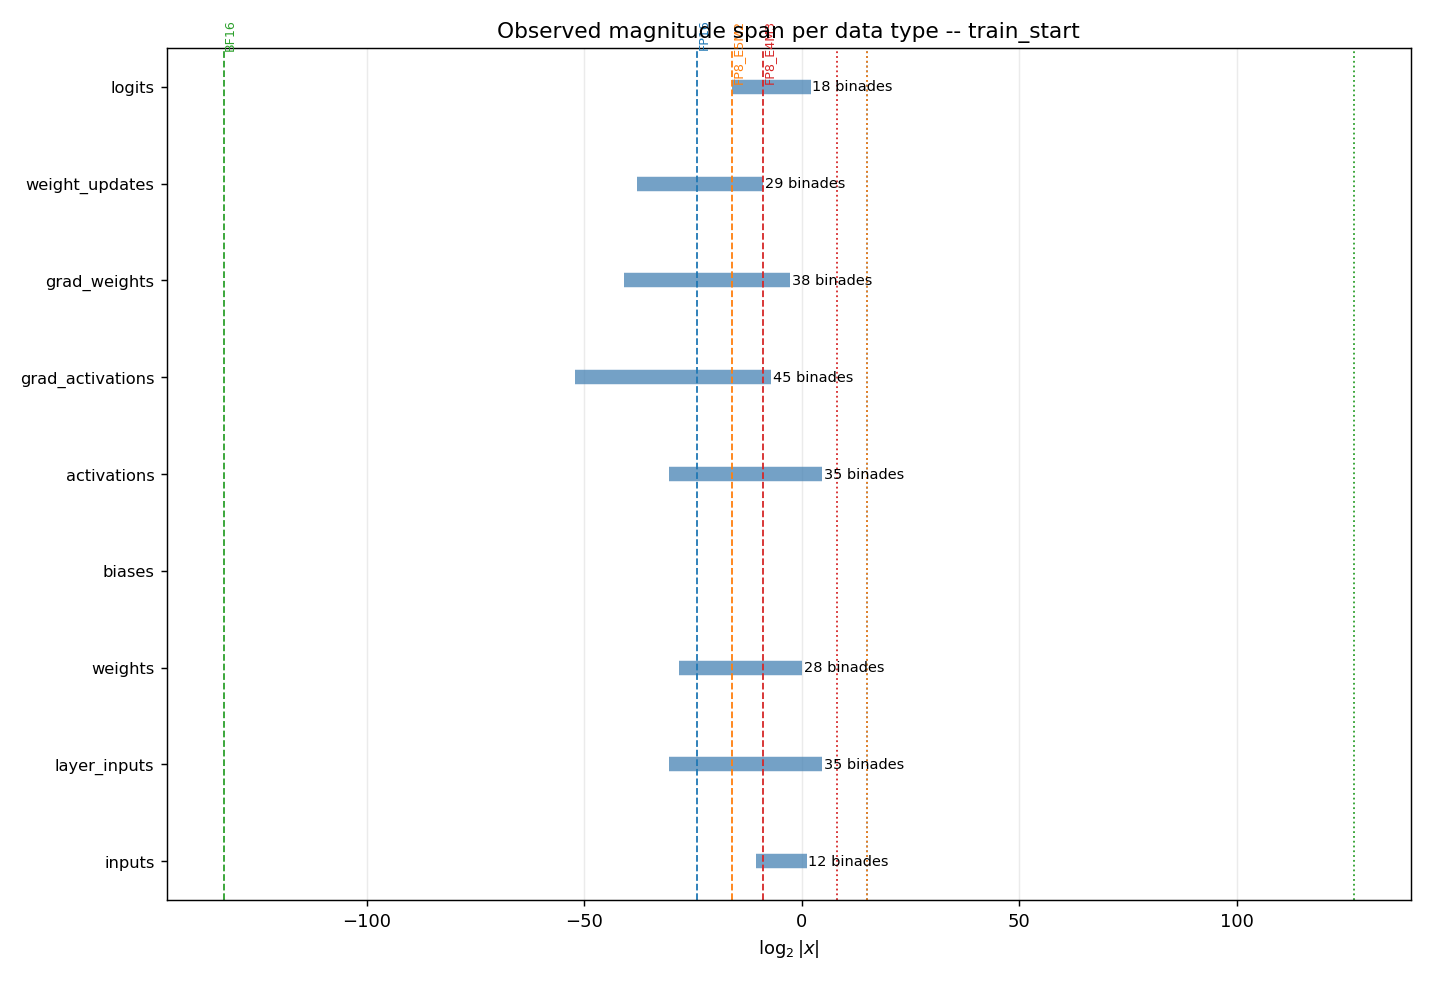


precision_analysis_results/figures/train_start/activations.png


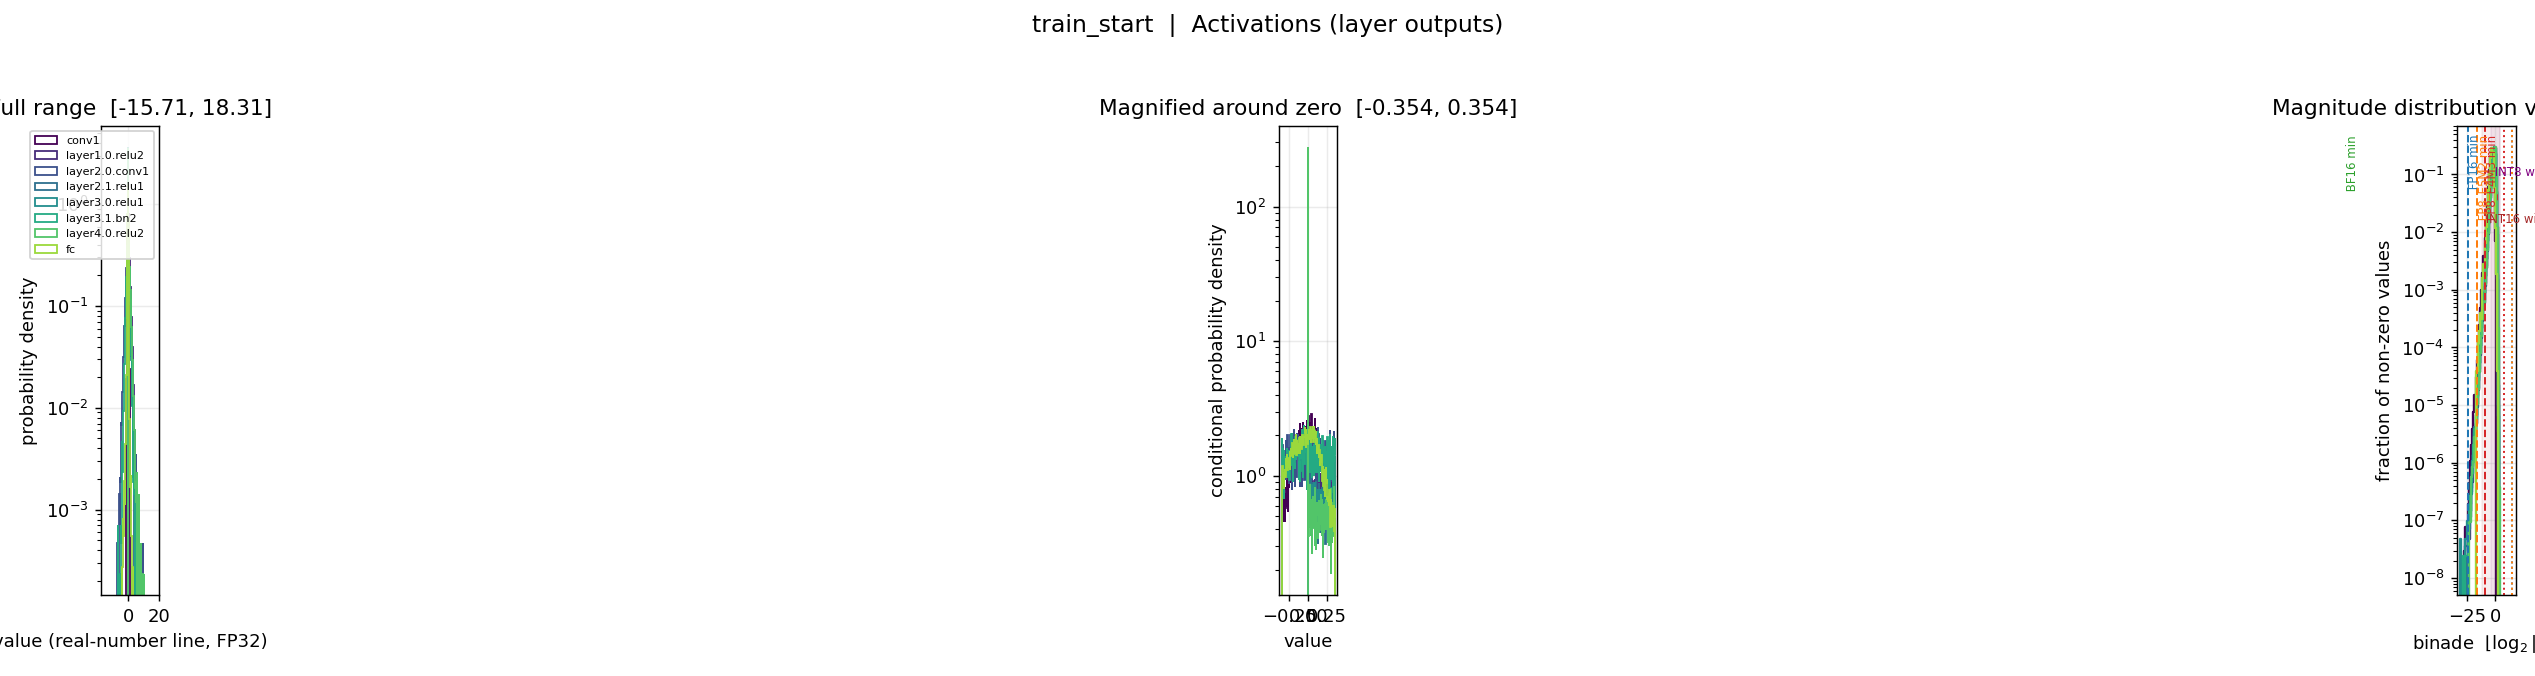


precision_analysis_results/figures/train_start/biases.png


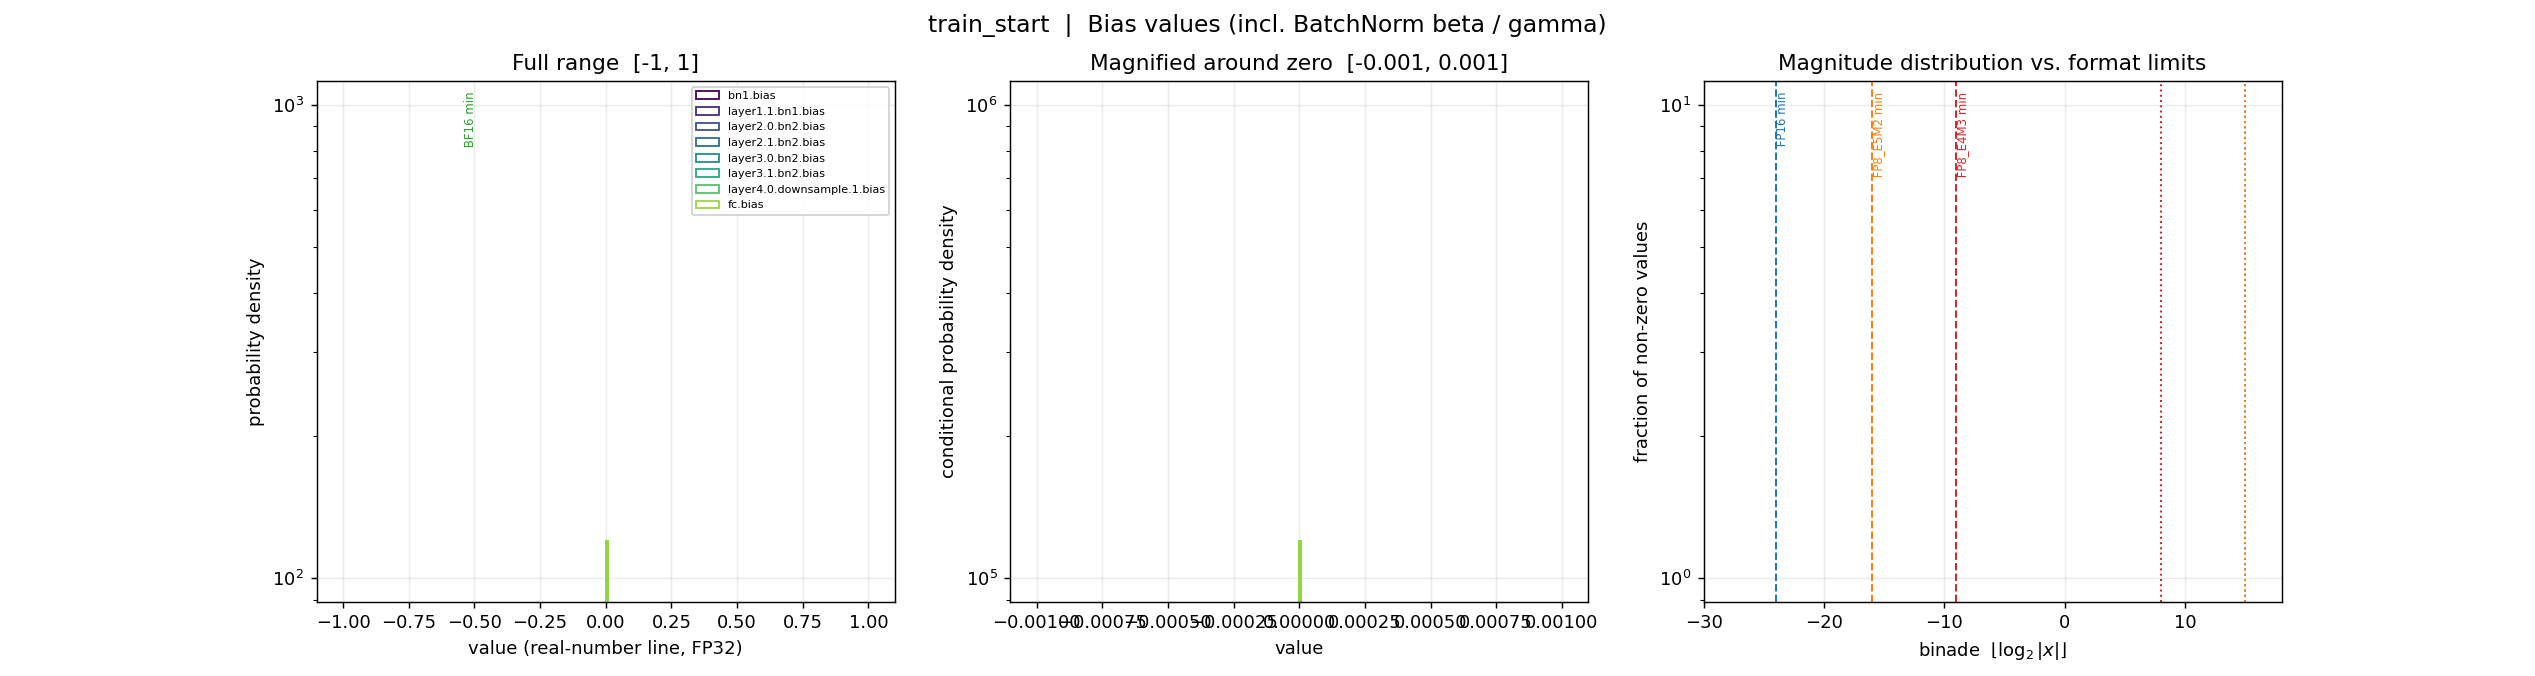


precision_analysis_results/figures/train_start/grad_activations.png


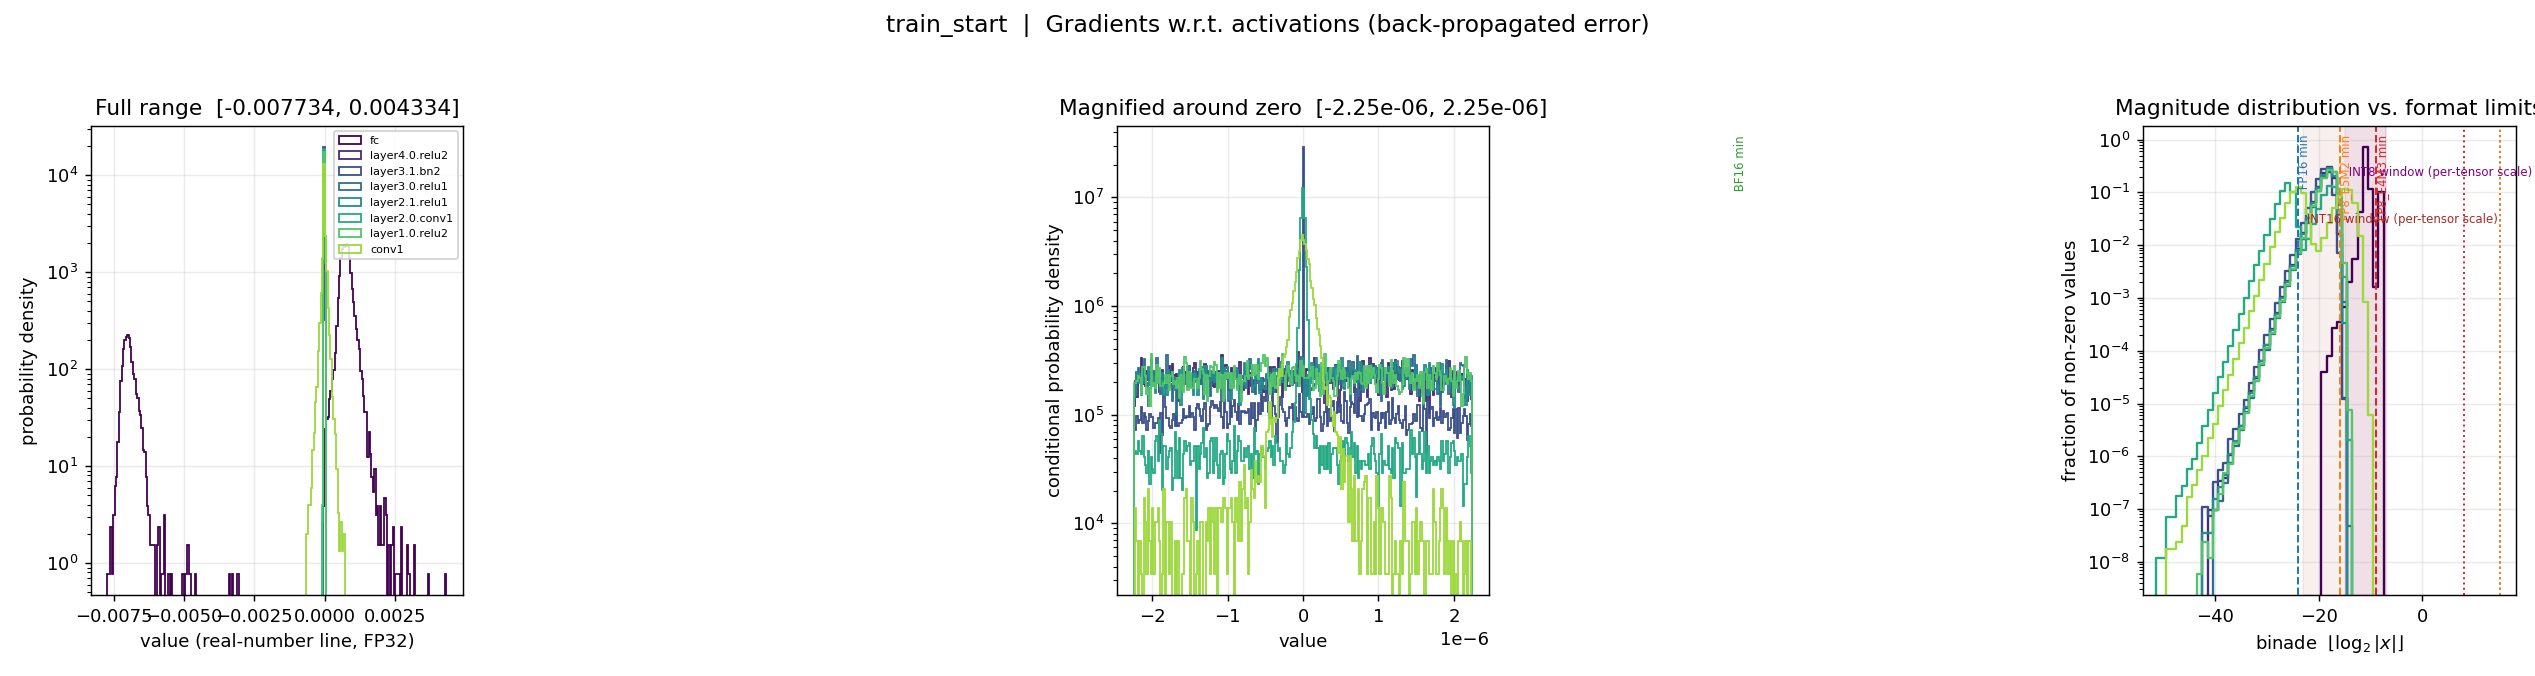


precision_analysis_results/figures/train_start/grad_weights.png


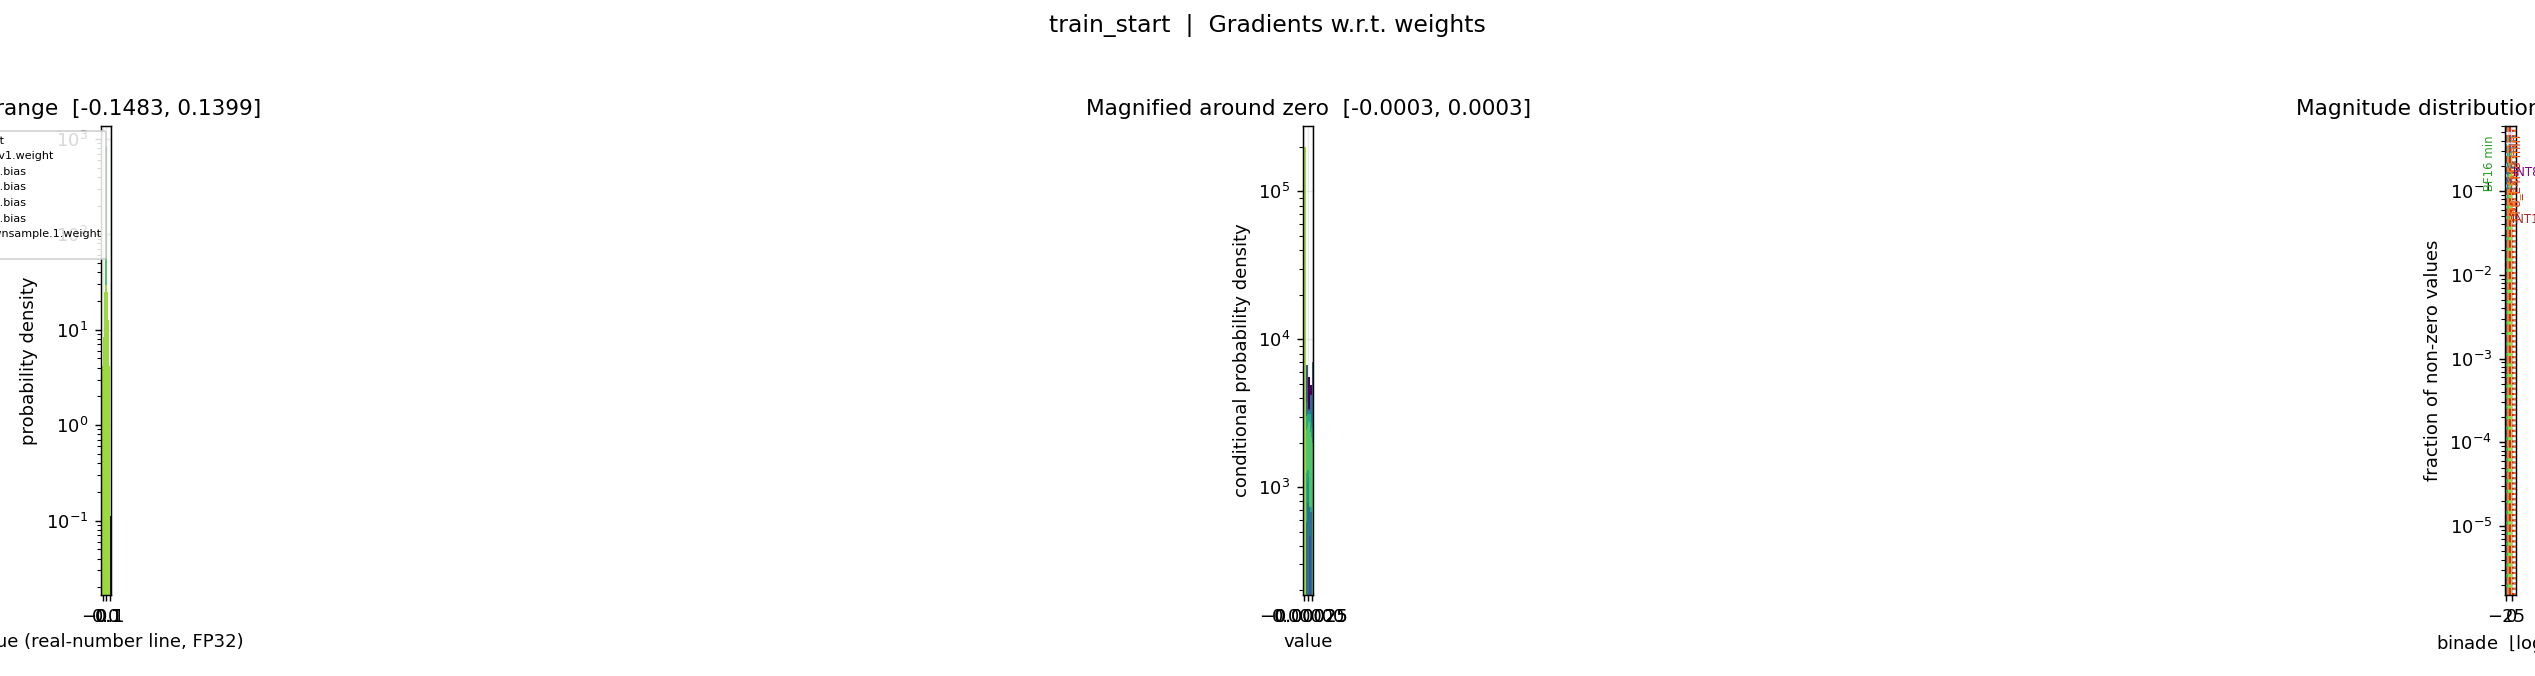


precision_analysis_results/figures/train_start/inputs.png


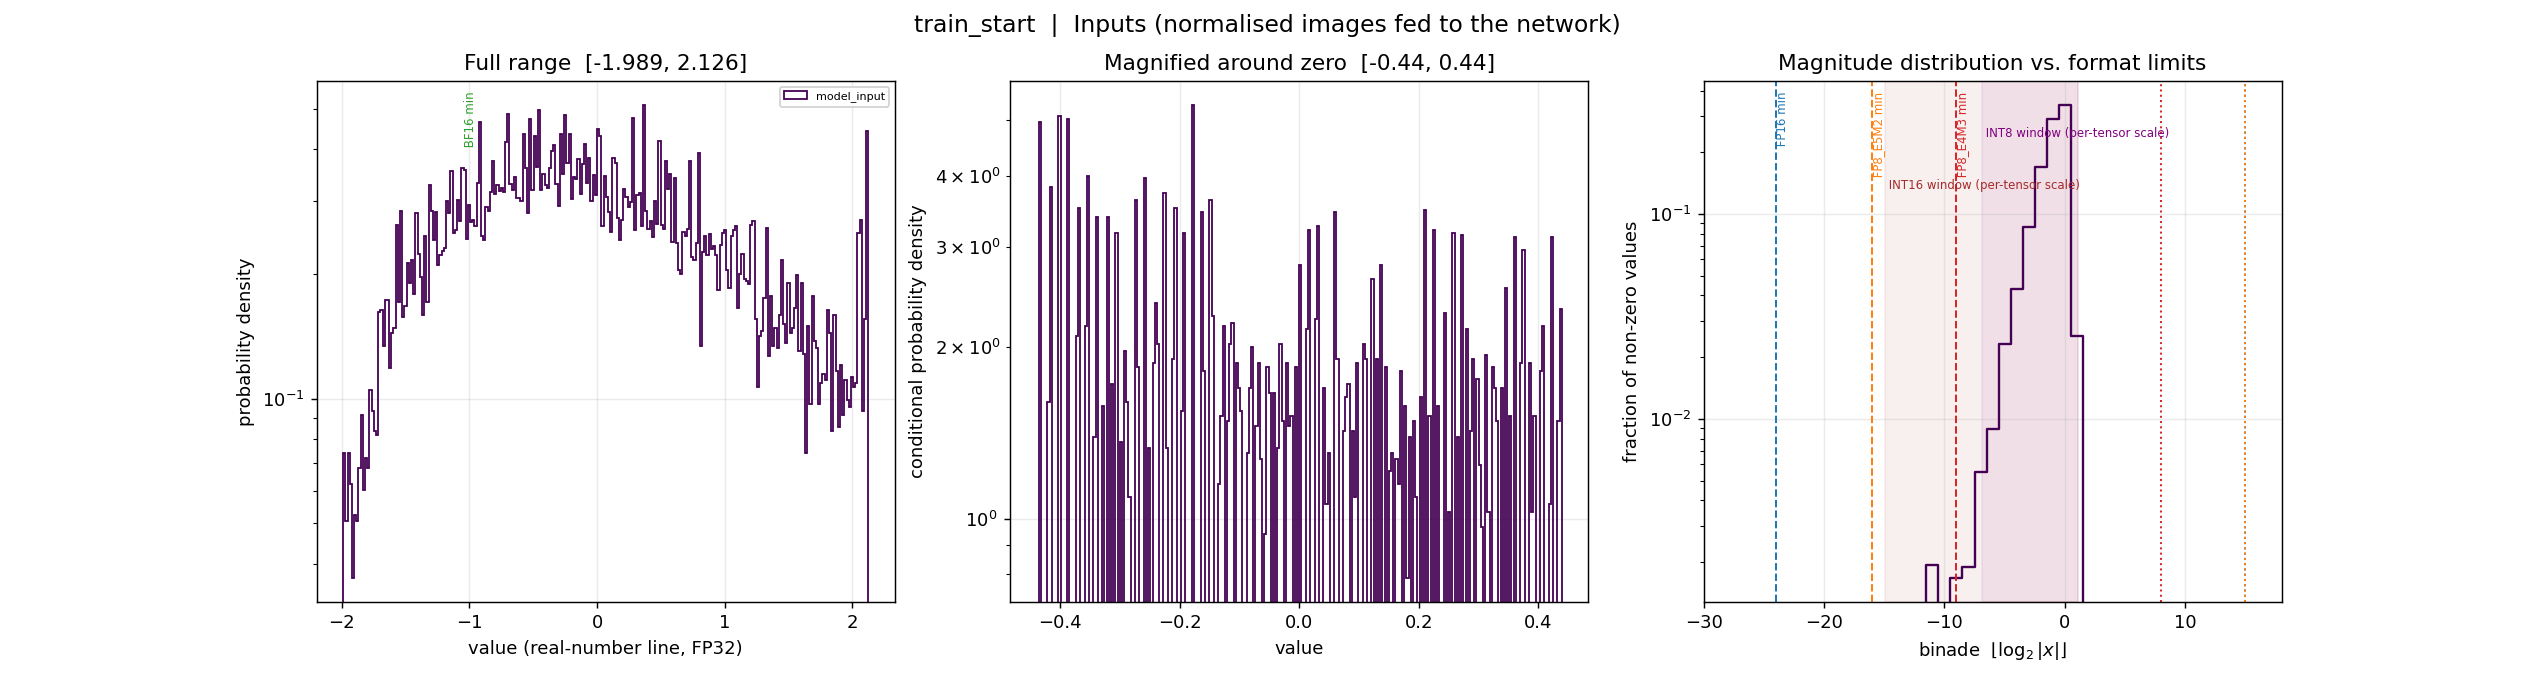


precision_analysis_results/figures/train_start/layer_inputs.png


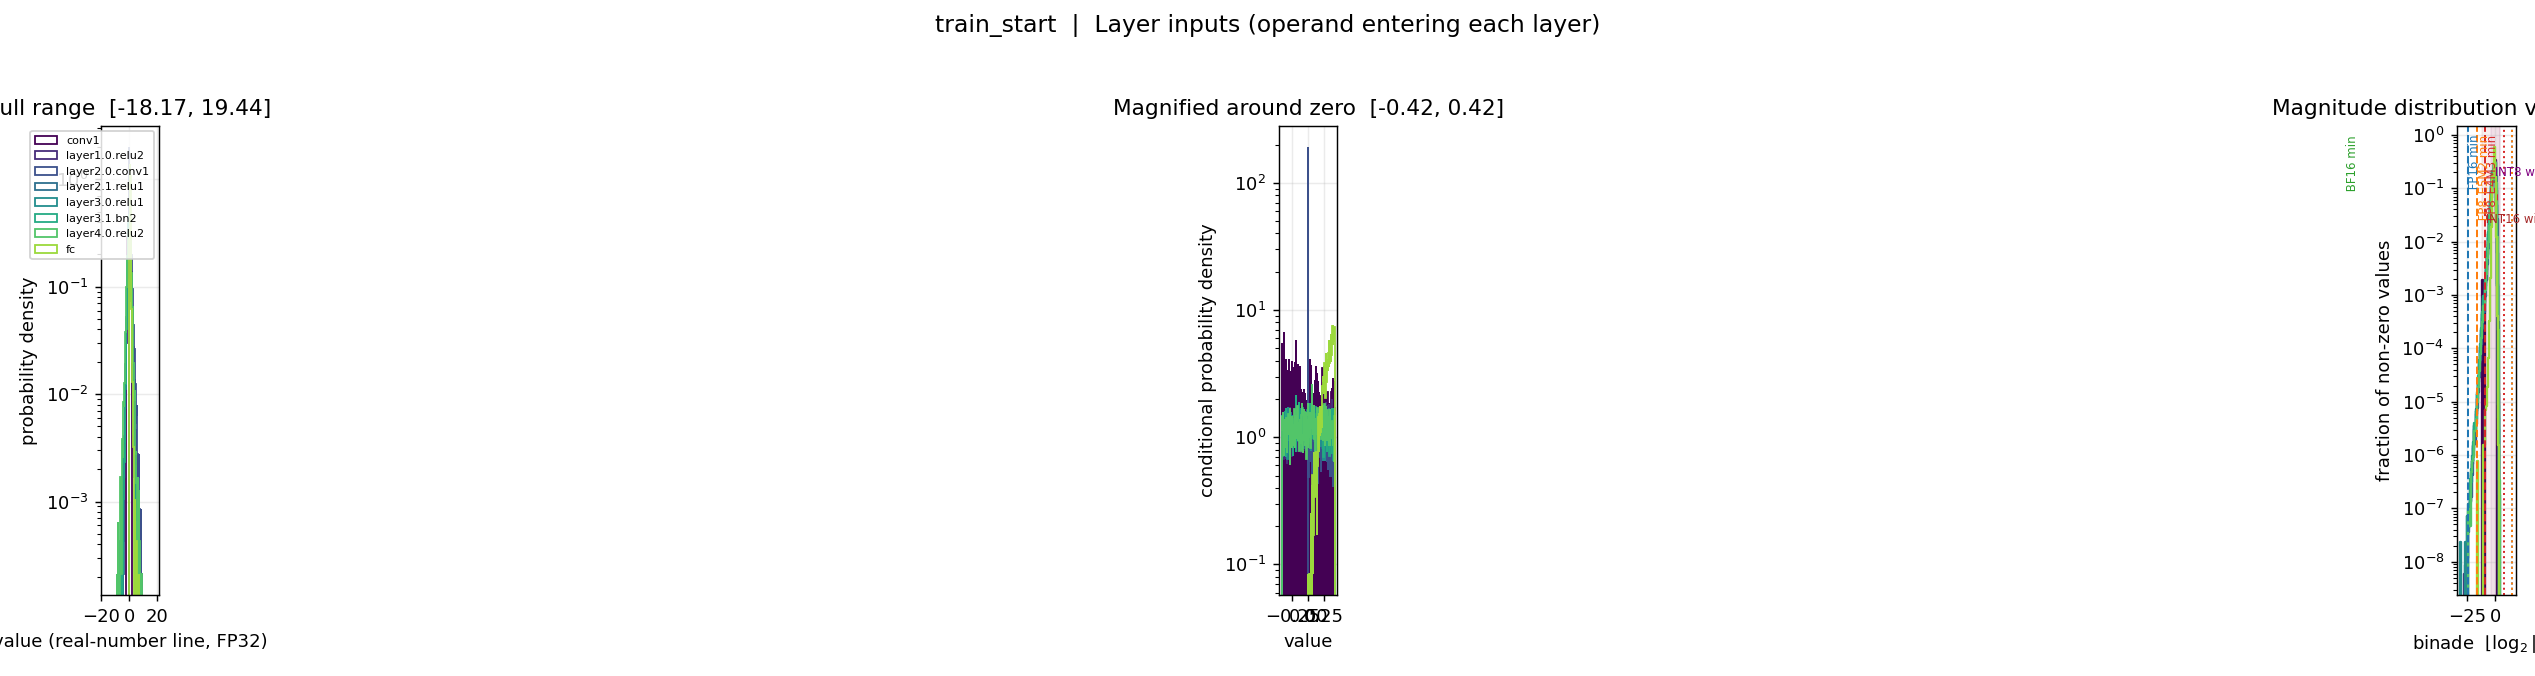


precision_analysis_results/figures/train_start/logits.png


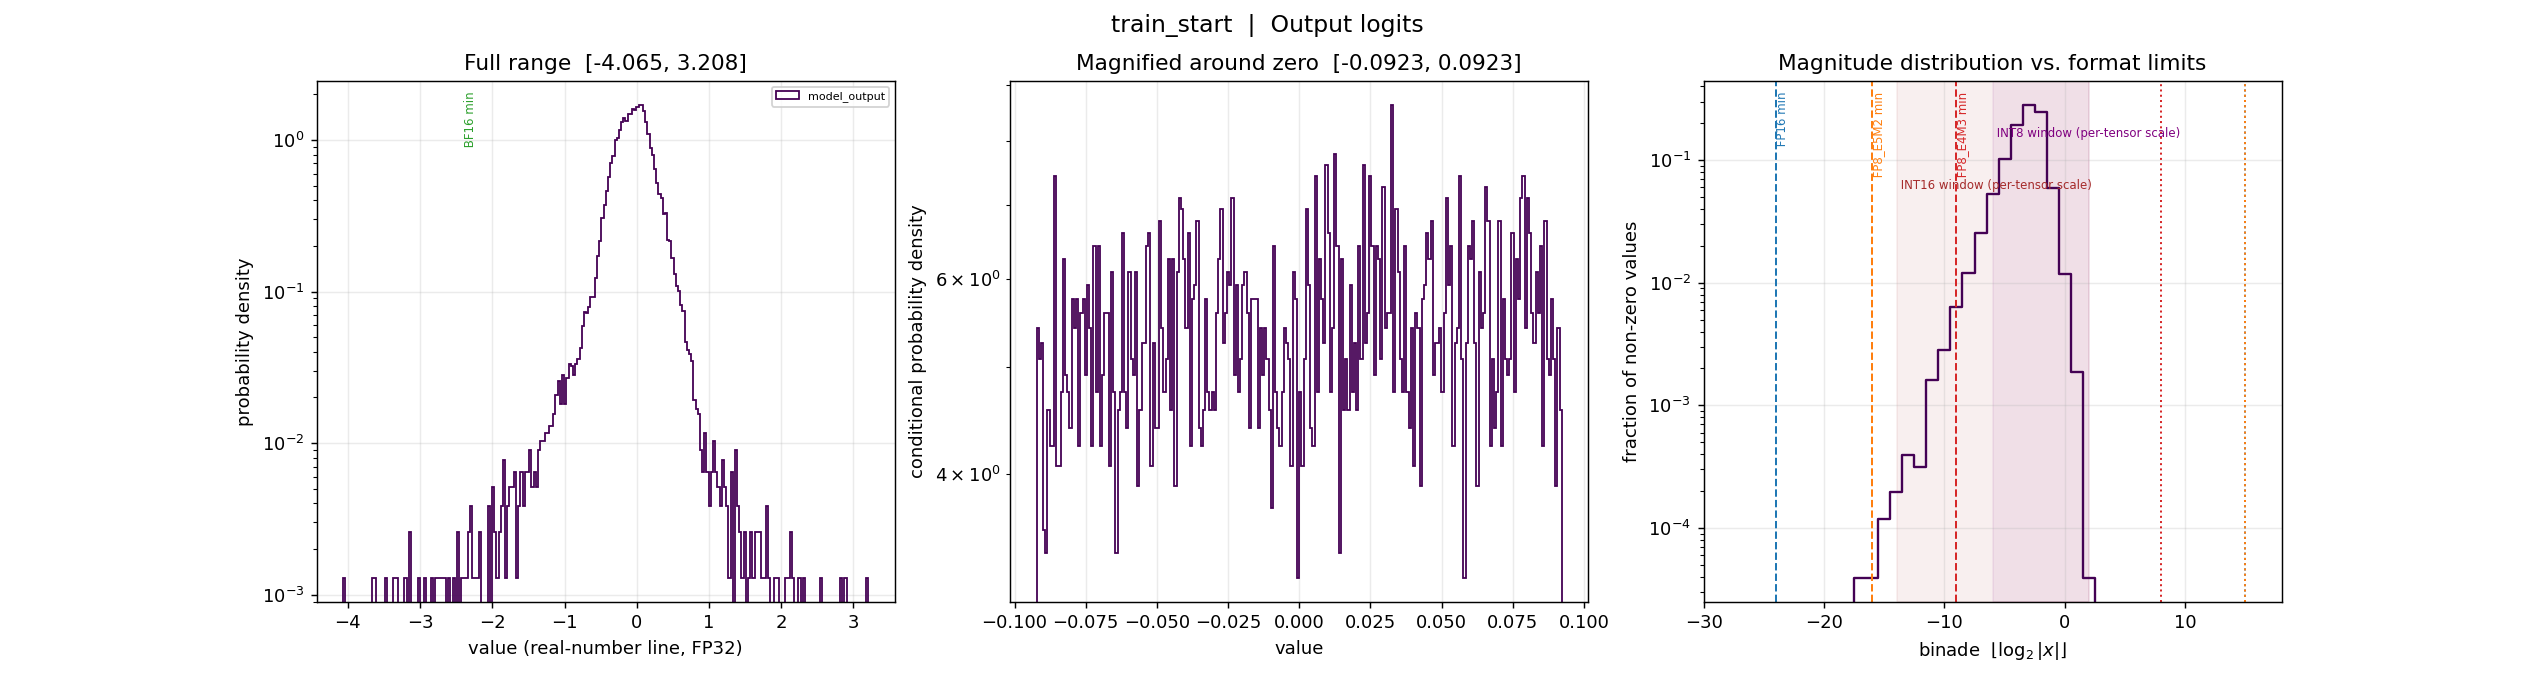


precision_analysis_results/figures/train_start/weight_updates.png


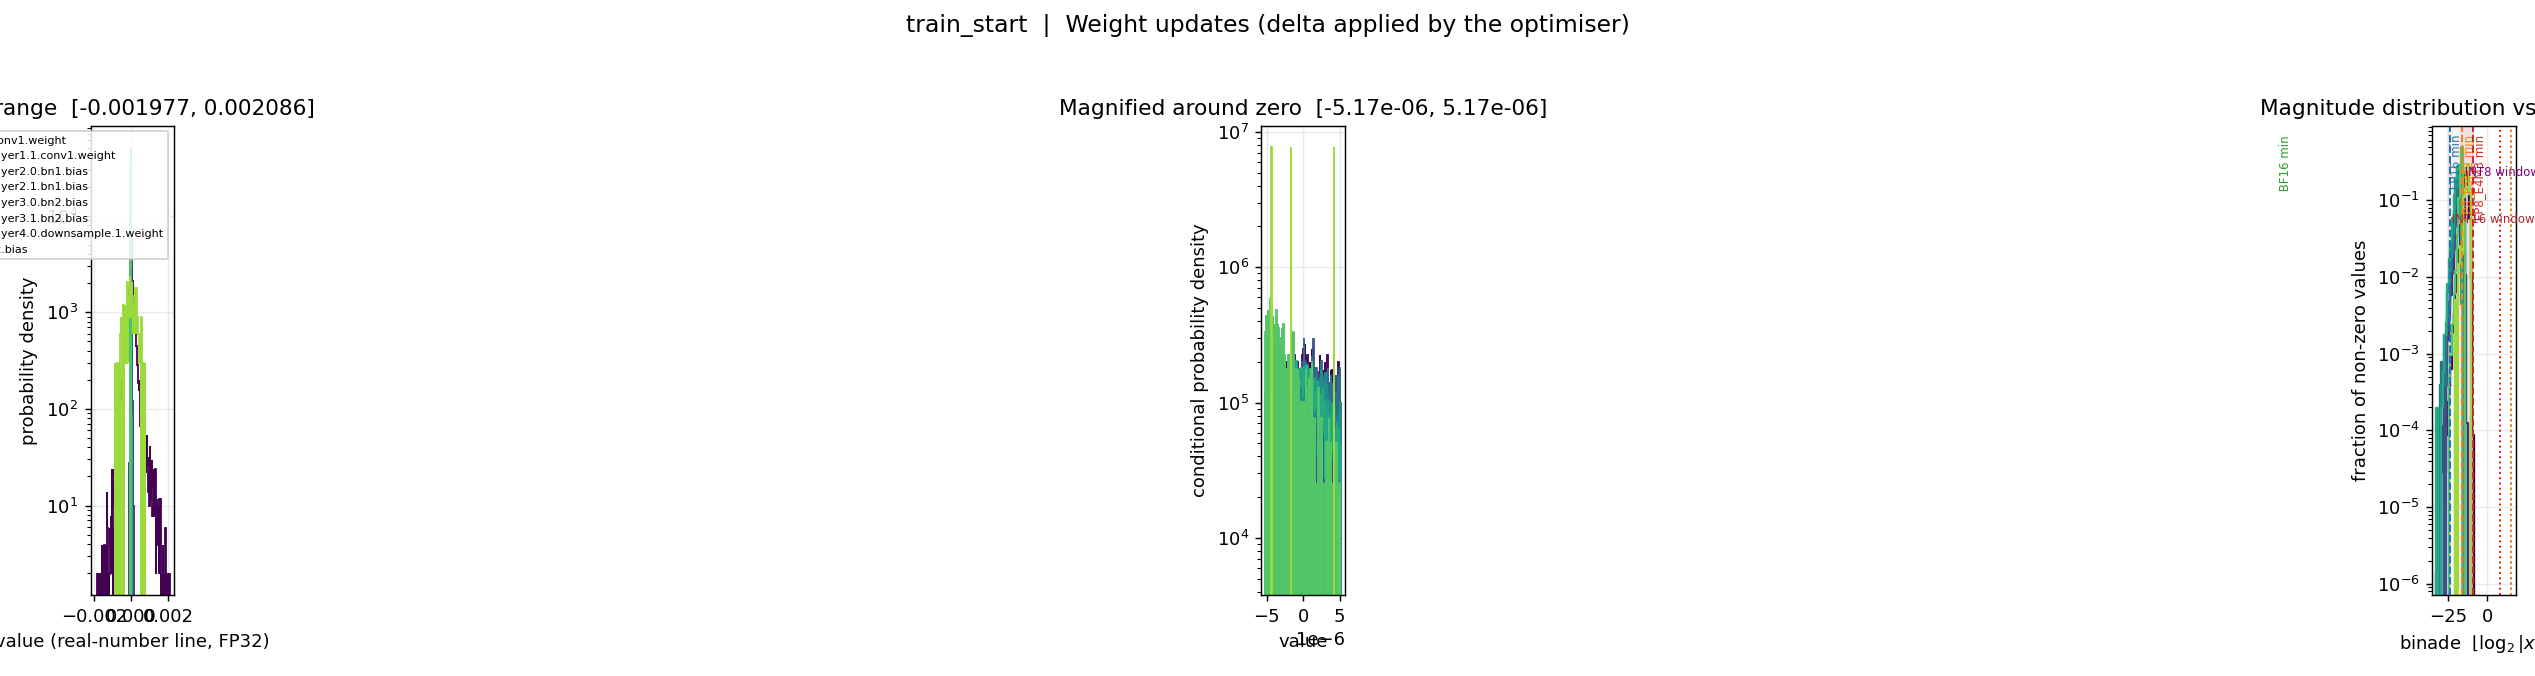


precision_analysis_results/figures/train_start/weights.png


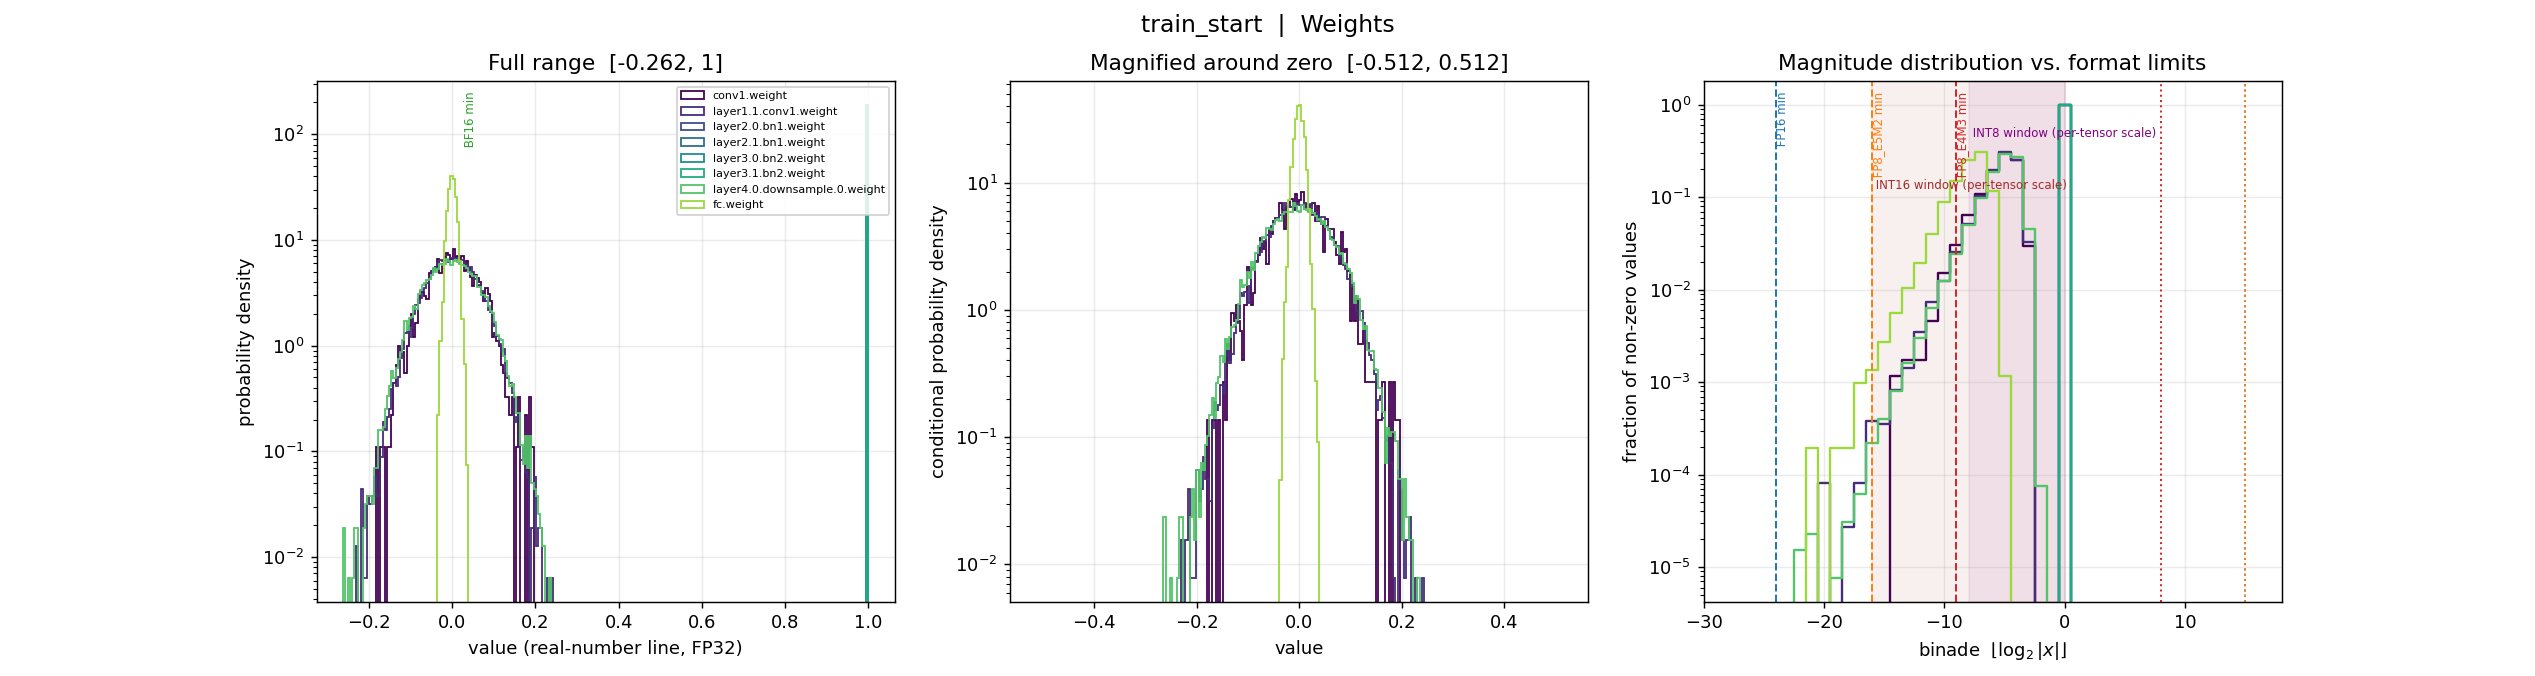

In [5]:
from IPython.display import Markdown, Image, display
import glob

display(Markdown(open("precision_analysis_results/REPORT.md").read()))

for f in sorted(glob.glob("precision_analysis_results/figures/*/*.png")):
    print("\n" + "=" * 100 + "\n" + f)
    display(Image(filename=f))

## Step 6 — save the outputs

Downloads a zip containing every figure, every CSV table and the report.

In [6]:
import shutil, os
shutil.make_archive("precision_analysis_results", "zip", "precision_analysis_results")
print("zip size: %.1f MB" % (os.path.getsize("precision_analysis_results.zip") / 1e6))

from google.colab import files
files.download("precision_analysis_results.zip")

# --- alternative: keep a copy in Google Drive ---------------------------------
# from google.colab import drive; drive.mount("/content/drive")
# shutil.copy("precision_analysis_results.zip", "/content/drive/MyDrive/")

zip size: 18.9 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')